# Comparative Analysis of Hierarchical LSTM, GRU, and RNN Models for Bitcoin and Ethereum Trade-Action Prediction Using Sentiment and Market Data

This notebook is the self-contained upgrade version of the crypto text + market pipeline.
It now supports both full end-to-end rebuilds and cached resume workflows for cheaper post-PyABSA experimentation.

It is organized so each stage is visible where it is used:

1. configure the workspace and dependencies
2. ingest and inspect the raw text sources
3. build balanced working sets
4. clean text and add BERT sentiment
5. rebuild or reuse the canonical post corpus with PyABSA price sentiment
6. rebuild or reuse the daily hierarchical modeling dataset
7. validate, repair, and scale the model inputs
8. train and compare hierarchical recurrent models with the same dataset feed

**Execution modes**
- `full_rebuild`: rerun PyABSA and all downstream artifacts
- `resume_after_pyabsa`: reuse cached post-PyABSA artifacts and rebuild the daily/modeling stages
- `training_only`: reuse cached post-PyABSA and daily artifacts, then rerun tuning and training only


## Cell 1: Workspace Setup Overview

**What this section does**
- defines every important input and output path for the upgrade workspace
- records the cutoff date and preprocessing caps
- keeps model artifact paths explicit so later cells do not hide where files are written

**Why this matters**
- the notebook needs one visible control panel for paths and run-time constants
- the hierarchical model and comparison outputs need to stay explicit so the final artifacts remain easy to trace


In [2]:
from pathlib import Path
import ast
import csv
import json
import math
import re
from collections import Counter

import numpy as np
import pandas as pd
import sys

CURRENT_DIR = Path.cwd().resolve()

if (CURRENT_DIR / 'data').exists():
    WORKSPACE_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / 'data').exists():
    WORKSPACE_ROOT = CURRENT_DIR.parent
else:
    WORKSPACE_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name in {'training', 'modified'} else CURRENT_DIR

DATA_DIR = WORKSPACE_ROOT / 'data'
OLD_INPUTS_DIR = DATA_DIR / 'old_inputs'
NEW_INPUTS_DIR = DATA_DIR / 'new_inputs'
PYTHON_BACKEND_DIR = WORKSPACE_ROOT.parent / 'python_backend'
PYABSA_CHECKPOINT = PYTHON_BACKEND_DIR / 'checkpoints' / 'ATEPC_ENGLISH_CHECKPOINT_downloaded' / 'fast_lcf_atepc_English_cdw_apcacc_85.03_apcf1_82.76_atef1_84.8'

SOCIAL_WORKING_PATH = DATA_DIR / 'social_media_working_set.csv'
NEWS_WORKING_PATH = DATA_DIR / 'news_working_set.csv'
REDDIT_WORKING_PATH = DATA_DIR / 'reddit_working_set.csv'
SOCIAL_FILTERED_PATH = DATA_DIR / 'social_media_filtered.csv'
NEWS_FILTERED_PATH = DATA_DIR / 'news_filtered.csv'
REDDIT_FILTERED_PATH = DATA_DIR / 'reddit_filtered.csv'
SOCIAL_SENTIMENT_CHECKPOINT_PATH = DATA_DIR / 'social_media_sentiment_checkpoint.csv'
NEWS_SENTIMENT_CHECKPOINT_PATH = DATA_DIR / 'news_sentiment_checkpoint.csv'
REDDIT_SENTIMENT_CHECKPOINT_PATH = DATA_DIR / 'reddit_sentiment_checkpoint.csv'
SOCIAL_OUTPUT_PATH = DATA_DIR / 'social_media_refined_text.csv'
NEWS_OUTPUT_PATH = DATA_DIR / 'news_refined_text.csv'
REDDIT_OUTPUT_PATH = DATA_DIR / 'reddit_refined_text.csv'
BTC_OUTPUT_PATH = DATA_DIR / 'BTC.csv'
ETH_OUTPUT_PATH = DATA_DIR / 'ETH.csv'
COMBINED_SUBJECTIVITY_PATH = DATA_DIR / 'combined_subjectivity.csv'
PYBSA_OUTPUT_PATH = DATA_DIR / 'pybsa.csv'
FINAL_COMBINED_PATH = DATA_DIR / 'final_combined_with_pybsa.csv'
FINAL_MERGED_PATH = DATA_DIR / 'final_merged_data.csv'
DAILY_HIERARCHICAL_SENTIMENT_PATH = DATA_DIR / 'daily_hierarchical_sentiment.jsonl'
DAILY_DATASET_REPORT_PATH = DATA_DIR / 'daily_modeling_report.json'
HIERARCHICAL_TRAINING_HISTORY_PATH = DATA_DIR / 'hierarchical_training_history.csv'
HIERARCHICAL_PREDICTIONS_PATH = DATA_DIR / 'hierarchical_test_predictions.csv'
HIERARCHICAL_MODEL_SUMMARY_PATH = DATA_DIR / 'hierarchical_model_summary.json'
HIERARCHICAL_GRU_TRAINING_HISTORY_PATH = DATA_DIR / 'hierarchical_gru_training_history.csv'
HIERARCHICAL_GRU_PREDICTIONS_PATH = DATA_DIR / 'hierarchical_gru_test_predictions.csv'
HIERARCHICAL_GRU_MODEL_SUMMARY_PATH = DATA_DIR / 'hierarchical_gru_model_summary.json'
HIERARCHICAL_RNN_TRAINING_HISTORY_PATH = DATA_DIR / 'hierarchical_rnn_training_history.csv'
HIERARCHICAL_RNN_PREDICTIONS_PATH = DATA_DIR / 'hierarchical_rnn_test_predictions.csv'
HIERARCHICAL_RNN_MODEL_SUMMARY_PATH = DATA_DIR / 'hierarchical_rnn_model_summary.json'
MODEL_COMPARISON_SUMMARY_PATH = DATA_DIR / 'model_comparison_summary.json'
MODEL_INPUT_QUALITY_REPORT_PATH = DATA_DIR / 'model_input_quality_report.json'
PREPROCESSED_PATH = DATA_DIR / 'preprocessed_data.csv'
QUALITY_REPORT_PATH = DATA_DIR / 'pipeline_quality_report.json'

if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))
if str(WORKSPACE_ROOT / 'training') not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT / 'training'))

CUTOFF_DATE = pd.Timestamp('2026-07-27')
PREPROCESSING_MODE = 'balanced_cap'
SOCIAL_PER_DAY_CAP_TOTAL = 1000
SOCIAL_PER_DAY_CAP_BTC = 700
SOCIAL_PER_DAY_CAP_ETH = 300
REDDIT_PER_DAY_CAP_TOTAL = 400
NEWS_PER_DAY_CAP_TOTAL = None
ENABLE_DEDUP = True
ENABLE_FAST_LANGUAGE_FILTER = True
ENABLE_SENTIMENT_CHUNKING = True
RANDOM_SEED = 42
MIN_WORDS = 4
MIN_CHARACTERS = 20
MIN_TOKEN_COUNT = 5
LANGUAGE_ASCII_ACCEPT_RATIO = 0.97
LANGUAGE_ASCII_REJECT_RATIO = 0.75
SOCIAL_SENTIMENT_CHUNK_SIZE = 5000
REDDIT_SENTIMENT_CHUNK_SIZE = 2000
NEWS_SENTIMENT_CHUNK_SIZE = 1000

print('WORKSPACE_ROOT =', WORKSPACE_ROOT)
print('DATA_DIR =', DATA_DIR)
print('OLD_INPUTS_DIR =', OLD_INPUTS_DIR)
print('NEW_INPUTS_DIR =', NEW_INPUTS_DIR)
print('PREPROCESSING_MODE =', PREPROCESSING_MODE)


WORKSPACE_ROOT = /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28
DATA_DIR = /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data
OLD_INPUTS_DIR = /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/old_inputs
NEW_INPUTS_DIR = /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/new_inputs
PREPROCESSING_MODE = balanced_cap


## Cell 3: Dependency Setup

**What this section does**
- installs the notebook-only dependencies needed for parquet, language filtering, BERT sentiment, PyABSA, and neural training
- downloads the small NLTK and TextBlob resources that later cells rely on

**Why this matters**
- the notebook stays self-contained and does not rely on external `/training` modules or a prebuilt environment


In [3]:
import platform
import subprocess
import sys

print('Installing notebook dependencies into:', sys.executable)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'numpy<2'], check=True)
base_packages = [
    'pyarrow',
    'langdetect',
    'textblob',
    'seaborn',
    'nltk',
    'scikit-learn',
    'transformers<=4.29.0',
    'torch',
    'protobuf<=3.20.3',
    'sentencepiece',
    'update-checker==0.18.0',
    #'pyabsa==2.4.2',
]
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *base_packages], check=True)

# system_name = platform.system().lower()
# machine = platform.machine().lower()
# tensorflow_packages = ['tensorflow']
# if system_name == 'darwin' and machine in {'arm64', 'aarch64'}:
#     tensorflow_packages = ['tensorflow-macos', 'tensorflow-metal']

# tf_result = subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *tensorflow_packages], check=False)
# if tf_result.returncode != 0:
#     print('TensorFlow install did not complete. The notebook trains the sequence models with PyTorch, so TensorFlow is optional.')

import nltk

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

try:
    from textblob import download_corpora
    download_corpora.download_all()
except Exception as exc:
    print('TextBlob corpora download skipped:', exc)


Installing notebook dependencies into: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/.venv/bin/python


[nltk_data] Downloading package brown to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/jayedumindu/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!


## Cell 5: Shared Review and Validation Helpers

**What this section does**
- defines small global helpers that are safe to share across many stages
- validates that the required raw inputs actually exist before any expensive processing starts

**Why this matters**
- these are the only truly notebook-wide helpers kept near the top
- everything more specific is moved down near the stage that uses it


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


def assert_paths_exist(paths):
    missing = [str(path) for path in paths if not Path(path).exists()]
    if missing:
        raise FileNotFoundError('Missing required paths: ' + ' | '.join(missing))


def assert_columns(df, expected_columns, name):
    missing = [column for column in expected_columns if column not in df.columns]
    if missing:
        raise ValueError(f'{name} missing columns: {missing}')


def normalize_subject_value(value):
    value = str(value).strip().lower()
    if value in {'#btc', '#bitcoin', 'btc', 'bitcoin'}:
        return 'bitcoin'
    if value in {'#eth', 'eth', 'ethereum'}:
        return 'ethereum'
    return value


def normalize_subject_from_text_subject(value):
    value = str(value).strip().lower()
    if 'bitcoin' in value or value == 'btc':
        return 'bitcoin'
    if 'ethereum' in value or value == 'eth':
        return 'ethereum'
    return value


def canonical_social_subject(value):
    normalized = normalize_subject_value(value)
    if normalized in {'bitcoin', 'ethereum'}:
        return normalized
    return 'other'

def summarize_dataset_distribution(name, df, date_column, subject_column=None, subject_normalizer=None):
    summary = {'dataset': name, 'rows': len(df)}
    date_series = pd.to_datetime(df[date_column], errors='coerce') if date_column in df.columns else pd.Series(dtype='datetime64[ns]')
    date_series = date_series.dropna()
    summary['date_min'] = date_series.min() if not date_series.empty else pd.NaT
    summary['date_max'] = date_series.max() if not date_series.empty else pd.NaT
    summary['days_covered'] = int(date_series.dt.normalize().nunique()) if not date_series.empty else 0
    summary['rows_per_day_avg'] = round(len(df) / max(summary['days_covered'], 1), 2)
    if subject_column and subject_column in df.columns:
        subject_series = df[subject_column].astype(str)
        if subject_normalizer is not None:
            subject_series = subject_series.apply(subject_normalizer)
        subject_counts = subject_series.value_counts()
        summary['bitcoin_rows'] = int(subject_counts.get('bitcoin', 0))
        summary['ethereum_rows'] = int(subject_counts.get('ethereum', 0))
        known_subject_rows = summary['bitcoin_rows'] + summary['ethereum_rows']
        summary['other_subject_rows'] = int(len(df) - known_subject_rows)
        summary['bitcoin_pct'] = round((summary['bitcoin_rows'] / len(df)) * 100, 2) if len(df) else 0.0
        summary['ethereum_pct'] = round((summary['ethereum_rows'] / len(df)) * 100, 2) if len(df) else 0.0
        summary['top_subjects'] = subject_counts.head(5).to_dict()
    return summary
def display_distribution_report(name, df, date_column, subject_column=None, subject_normalizer=None, plot_title=None):
    summary = summarize_dataset_distribution(name, df, date_column, subject_column, subject_normalizer)
    print()
    print(name)
    print('-' * len(name))
    for key, value in summary.items():
        if key != 'top_subjects':
            print(f'{key}: {value}')
    if 'top_subjects' in summary:
        print('top_subjects:', summary['top_subjects'])
    if subject_column and subject_column in df.columns:
        subject_series = df[subject_column].astype(str)
        if subject_normalizer is not None:
            subject_series = subject_series.apply(subject_normalizer)
        subject_counts = subject_series.value_counts().head(10)
        plt.figure(figsize=(8, 4))
        subject_counts.plot(kind='bar', color='steelblue')
        plt.title(plot_title or f'{name} subject distribution')
        plt.ylabel('Rows')
        plt.tight_layout()
        plt.show()
    if date_column in df.columns:
        date_series = pd.to_datetime(df[date_column], errors='coerce').dropna()
        if not date_series.empty:
            daily_counts = date_series.dt.normalize().value_counts().sort_index()
            plt.figure(figsize=(10, 4))
            daily_counts.plot(kind='line', color='darkorange')
            plt.title(f'{name} daily row counts')
            plt.ylabel('Rows')
            plt.tight_layout()
            plt.show()
    return summary
def display_cross_dataset_imbalance(dataset_summaries):
    summary_df = pd.DataFrame(dataset_summaries)
    if summary_df.empty:
        print('No dataset summaries to display.')
        return summary_df
    ordered_columns = [
        'dataset', 'rows', 'date_min', 'date_max', 'days_covered', 'rows_per_day_avg',
        'bitcoin_rows', 'ethereum_rows', 'bitcoin_pct', 'ethereum_pct', 'other_subject_rows'
    ]
    existing_columns = [column for column in ordered_columns if column in summary_df.columns]
    print(summary_df[existing_columns].sort_values('rows', ascending=False).to_string(index=False))
    if len(summary_df) > 1:
        smallest = summary_df['rows'].replace(0, np.nan).min()
        if pd.notna(smallest) and smallest > 0:
            imbalance_df = summary_df[['dataset', 'rows']].copy()
            imbalance_df['size_vs_smallest'] = (imbalance_df['rows'] / smallest).round(2)
            print()
            print('Dataset size multiples versus the smallest dataset:')
            print(imbalance_df.sort_values('rows', ascending=False).to_string(index=False))
    return summary_df
def summarize_text_quality(name, df, text_column, sample_size=10000, english_probe_size=1000, random_state=42):
    summary = {'dataset': name, 'rows': len(df)}
    if text_column not in df.columns:
        return summary
    text_series = df[text_column]
    summary['missing_text_rows'] = int(text_series.isna().sum())
    normalized_text = text_series.fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.strip()
    usable_text = normalized_text[normalized_text.ne('')]
    summary['empty_text_rows'] = int(len(normalized_text) - len(usable_text))
    summary['usable_text_rows'] = int(len(usable_text))
    if usable_text.empty:
        summary['profile_sample_rows'] = 0
        return summary
    sample_n = min(sample_size, len(usable_text))
    sample = usable_text.sample(sample_n, random_state=random_state) if len(usable_text) > sample_n else usable_text.copy()
    word_counts = sample.str.count(r'\S+')
    summary['profile_sample_rows'] = int(len(sample))
    summary['median_word_count_sample'] = round(float(word_counts.median()), 2) if len(word_counts) else 0.0
    summary['p90_word_count_sample'] = round(float(word_counts.quantile(0.9)), 2) if len(word_counts) else 0.0
    summary['short_text_pct_sample'] = round(float((word_counts < 5).mean() * 100), 2) if len(word_counts) else 0.0
    summary['very_short_text_pct_sample'] = round(float((word_counts < 3).mean() * 100), 2) if len(word_counts) else 0.0
    summary['duplicate_text_pct_sample'] = round(float((1 - (sample.nunique() / len(sample))) * 100), 2) if len(sample) else 0.0
    english_probe_n = min(english_probe_size, len(sample))
    english_probe = sample.sample(english_probe_n, random_state=random_state) if len(sample) > english_probe_n else sample
    english_like = english_probe.apply(is_probably_english)
    summary['english_like_pct_probe'] = round(float(english_like.mean() * 100), 2) if len(english_like) else 0.0
    return summary
def display_text_quality_report(name, df, text_column, sample_size=10000, english_probe_size=1000):
    summary = summarize_text_quality(name, df, text_column, sample_size=sample_size, english_probe_size=english_probe_size)
    print()
    print(name)
    print('-' * len(name))
    for key, value in summary.items():
        print(f'{key}: {value}')
    return summary
def display_quality_comparison(quality_summaries):
    summary_df = pd.DataFrame(quality_summaries)
    if summary_df.empty:
        print('No text-quality summaries to display.')
        return summary_df
    ordered_columns = [
        'dataset', 'rows', 'usable_text_rows', 'missing_text_rows', 'empty_text_rows',
        'profile_sample_rows', 'median_word_count_sample', 'p90_word_count_sample',
        'short_text_pct_sample', 'very_short_text_pct_sample', 'duplicate_text_pct_sample', 'english_like_pct_probe'
    ]
    existing_columns = [column for column in ordered_columns if column in summary_df.columns]
    print(summary_df[existing_columns].sort_values('rows', ascending=False).to_string(index=False))
    return summary_df

assert_paths_exist([
    OLD_INPUTS_DIR / 'social_media_data',
    OLD_INPUTS_DIR / 'news_data' / 'cryptonews.csv',
    OLD_INPUTS_DIR / 'reddit' / 'reddit_sentiment_august2021.csv',
    OLD_INPUTS_DIR / 'prices' / 'BTC.csv',
    OLD_INPUTS_DIR / 'prices' / 'ETH.csv',
    NEW_INPUTS_DIR / 'prices' / 'BTC_daily_prices_2024-10-25_to_2026-07-27.csv',
    NEW_INPUTS_DIR / 'prices' / 'ETH_daily_prices_2024-10-25_to_2026-07-27.csv',
    NEW_INPUTS_DIR / 'twitter' / 'bitcoin_tweets_latest.csv',
    NEW_INPUTS_DIR / 'reddit' / 'btc' / 'r_Bitcoin_posts.jsonl',
    NEW_INPUTS_DIR / 'reddit' / 'eth' / 'r_ethereum_posts.jsonl',
])
print('Input validation passed')


Input validation passed


## Cell 7: Social Ingestion Helpers

**What this section does**
- keeps only the helper logic needed to read the historical social parquet files and normalize the new Twitter CSV export

**Why this matters**
- the notebook no longer hides unrelated preprocessing logic in the same toolbox cell


In [45]:
import csv

def safe_read_parquet(parquet_path):
    try:
        return pd.read_parquet(parquet_path)
    except Exception as exc:
        message = str(exc)
        if 'arrow.py_extension_type' not in message and 'ArrowKeyError' not in type(exc).__name__:
            raise
        import pyarrow.parquet as pq
        print(f'Falling back to pyarrow.parquet for {parquet_path.name}: {exc}')
        table = pq.read_table(parquet_path)
        return table.to_pandas()
def normalize_date(value, clip_to_cutoff=True):
    ts = pd.to_datetime(value, errors='coerce', utc=True)
    if pd.isna(ts):
        return None
    ts = ts.tz_convert(None) if getattr(ts, 'tzinfo', None) is not None else ts
    if clip_to_cutoff and ts > CUTOFF_DATE:
        return None
    return ts.strftime('%Y-%m-%d')
def clean_text_pipeline(text):
    text = str(text)
    text = text.replace('&lt;', '<').replace('&gt;', '>').replace('&amp;', '&')
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text
def build_text_key_series(text_series):
    return text_series.fillna('').astype(str).map(clean_text_pipeline).str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()
def robust_twitter_stream(twitter_csv_path):
    records = []
    with open(twitter_csv_path, 'r', encoding='utf-8', errors='ignore', newline='') as handle:
        reader = csv.DictReader(handle, escapechar='\\')
        for row in reader:
            if not row:
                continue
            tweet_date = normalize_date(row.get('date'))
            text = row.get('text')
            if tweet_date and text:
                records.append({'datetime': tweet_date, 'text': text, 'label': '#btc'})
    return pd.DataFrame(records)


# Step 1: Refine the Social / Twitter Source

**Inputs**
- old parquet social exports
- the newer Bitcoin tweet export in `data/new_inputs/twitter`

**Outputs from this stage**
- an in-memory combined raw social table for review

**Key transformations**
- reshape the new CSV rows into the historical schema
- clip future rows at the notebook cutoff date
- keep the combined raw view separate from the later balanced working set


In [46]:
# Load the historical and new social sources into one raw combined frame.
historical_social_frames = []
for parquet_path in sorted((OLD_INPUTS_DIR / 'social_media_data').glob('*.parquet')):
    historical_social_frames.append(safe_read_parquet(parquet_path))

historical_social_df = pd.concat(historical_social_frames, ignore_index=True)
assert_columns(historical_social_df, ['text', 'label', 'datetime'], 'historical social media data')

new_tweets_df = robust_twitter_stream(NEW_INPUTS_DIR / 'twitter' / 'bitcoin_tweets_latest.csv')
historical_columns = historical_social_df.columns.tolist()
normalized_tweet_records = []
for row in new_tweets_df.to_dict(orient='records'):
    normalized_row = {column: pd.NA for column in historical_columns}
    normalized_row['text'] = row['text']
    normalized_row['label'] = '#btc' 
    normalized_row['datetime'] = row['datetime']
    for optional_column in ['tweet_hashtags', 'username_encoded', 'url_encoded']:
        if optional_column in normalized_row:
            normalized_row[optional_column] = pd.NA
    normalized_tweet_records.append(normalized_row)

normalized_new_tweets_df = pd.DataFrame(normalized_tweet_records, columns=historical_columns)
combined_social_df = pd.concat([historical_social_df, normalized_new_tweets_df], ignore_index=True)
combined_social_df['datetime'] = pd.to_datetime(combined_social_df['datetime'], errors='coerce')
combined_social_df = combined_social_df.dropna(subset=['datetime', 'text', 'label'])
combined_social_df = combined_social_df[combined_social_df['datetime'] <= CUTOFF_DATE]

print('Historical social rows:', len(historical_social_df))
print('New BTC tweet rows:', len(normalized_new_tweets_df))
print('Combined social rows:', len(combined_social_df))
print('Social date range:', combined_social_df['datetime'].min(), 'to', combined_social_df['datetime'].max())


Historical social rows: 48780
New BTC tweet rows: 4689244
Combined social rows: 4738024
Social date range: 2024-03-08 00:00:00 to 2026-03-02 00:00:00


## Cell 11: Review the Raw Social Distribution

**What this section checks**
- subject balance
- date coverage
- text quality signals before cleaning

**Why this matters**
- social data is usually the largest and noisiest source, so the notebook surfaces imbalance before any caps are applied



Historical social raw data
--------------------------
dataset: Historical social raw data
rows: 48780
date_min: 2024-03-08 00:00:00
date_max: 2024-10-30 00:00:00
days_covered: 151
rows_per_day_avg: 323.05
bitcoin_rows: 14646
ethereum_rows: 312
other_subject_rows: 33822
bitcoin_pct: 30.02
ethereum_pct: 0.64
top_subjects: {'bitcoin': 14646, '#crypto': 3718, '#defi': 1980, '#cryptocurrency': 1746, '#radix': 360}


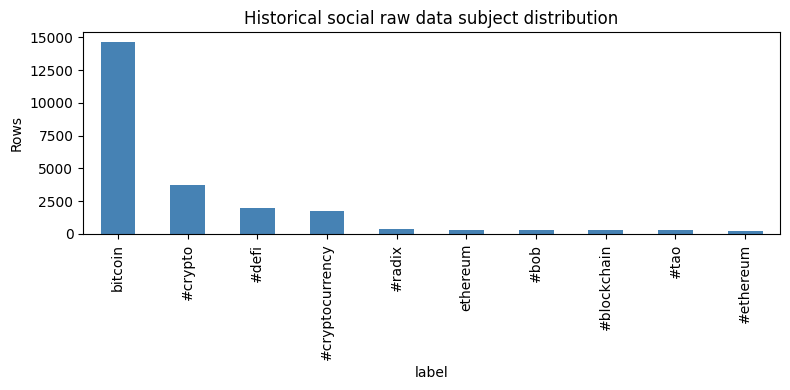

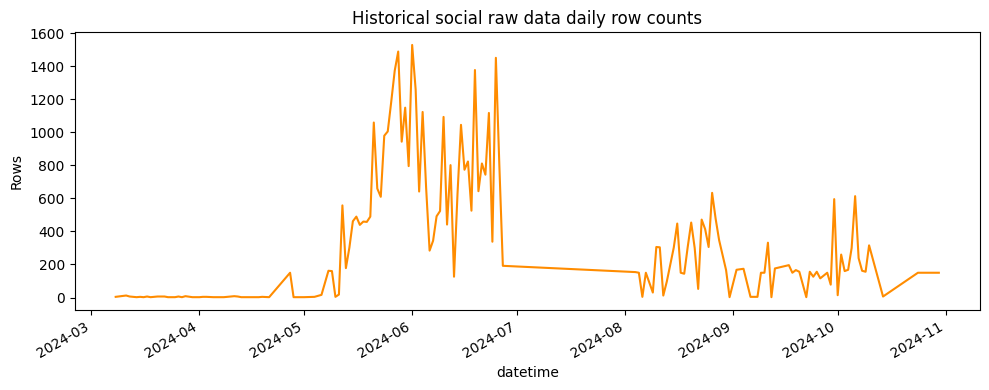


New BTC Twitter raw data
------------------------
dataset: New BTC Twitter raw data
rows: 4689244
date_min: 2025-03-06 00:00:00
date_max: 2026-03-02 00:00:00
days_covered: 201
rows_per_day_avg: 23329.57
bitcoin_rows: 4689244
ethereum_rows: 0
other_subject_rows: 0
bitcoin_pct: 100.0
ethereum_pct: 0.0
top_subjects: {'bitcoin': 4689244}


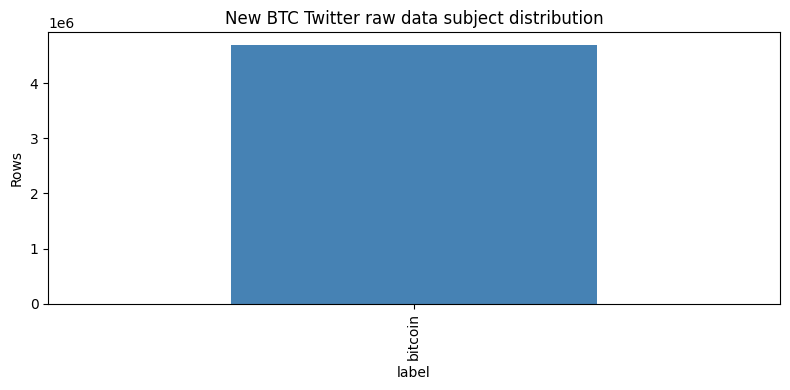

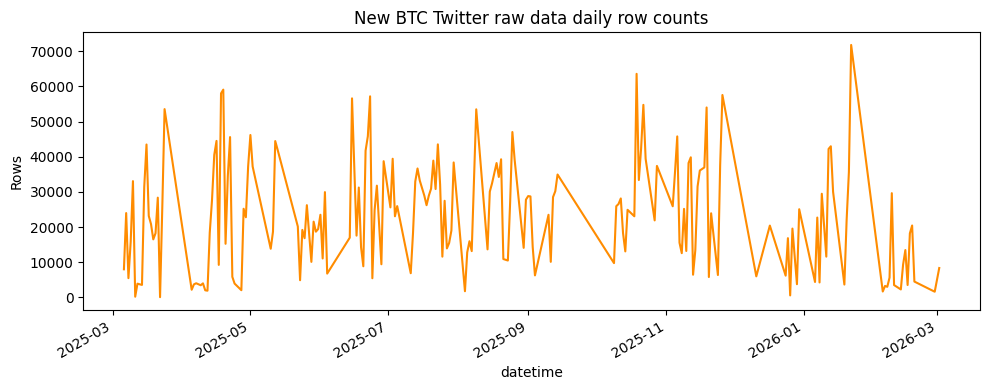


Combined social raw data
------------------------
dataset: Combined social raw data
rows: 4738024
date_min: 2024-03-08 00:00:00
date_max: 2026-03-02 00:00:00
days_covered: 352
rows_per_day_avg: 13460.3
bitcoin_rows: 4703890
ethereum_rows: 312
other_subject_rows: 33822
bitcoin_pct: 99.28
ethereum_pct: 0.01
top_subjects: {'bitcoin': 4703890, '#crypto': 3718, '#defi': 1980, '#cryptocurrency': 1746, '#radix': 360}


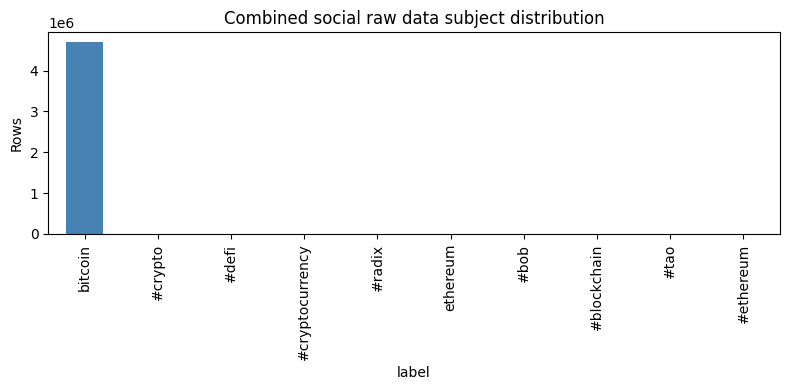

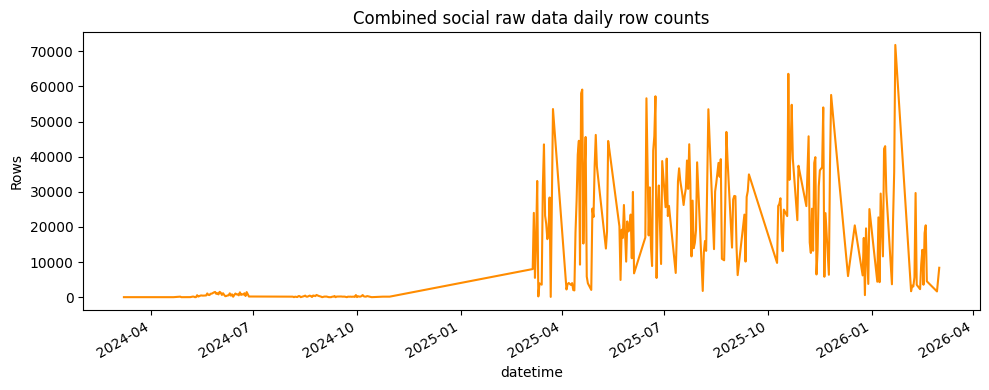

                   dataset    rows   date_min   date_max  days_covered  rows_per_day_avg  bitcoin_rows  ethereum_rows  bitcoin_pct  ethereum_pct  other_subject_rows
  Combined social raw data 4738024 2024-03-08 2026-03-02           352          13460.30       4703890            312        99.28          0.01               33822
  New BTC Twitter raw data 4689244 2025-03-06 2026-03-02           201          23329.57       4689244              0       100.00          0.00                   0
Historical social raw data   48780 2024-03-08 2024-10-30           151            323.05         14646            312        30.02          0.64               33822

Dataset size multiples versus the smallest dataset:
                   dataset    rows  size_vs_smallest
  Combined social raw data 4738024             97.13
  New BTC Twitter raw data 4689244             96.13
Historical social raw data   48780              1.00

Historical social raw text quality
----------------------------------
data

In [47]:
from langdetect import detect, DetectorFactory

# Make language detection deterministic
DetectorFactory.seed = 0

def is_probably_english(text):
    """
    Returns True if the text is detected as English.
    """
    if text is None:
        return False

    text = str(text).strip()

    if len(text) < 3:
        return False

    try:
        return detect(text) == "en"
    except Exception:
        return False

# ====================================================
raw_social_summaries = []
historical_social_analysis_df = historical_social_df[['datetime', 'label', 'text']].copy()
new_twitter_analysis_df = normalized_new_tweets_df[['datetime', 'label', 'text']].copy()
combined_social_analysis_df = combined_social_df[['datetime', 'label', 'text']].copy()

raw_social_summaries.append(display_distribution_report('Historical social raw data', historical_social_analysis_df, 'datetime', 'label', normalize_subject_value))
raw_social_summaries.append(display_distribution_report('New BTC Twitter raw data', new_twitter_analysis_df, 'datetime', 'label', normalize_subject_value))
raw_social_summaries.append(display_distribution_report('Combined social raw data', combined_social_analysis_df, 'datetime', 'label', normalize_subject_value))

raw_social_summary_df = display_cross_dataset_imbalance(raw_social_summaries)
raw_social_quality_summaries = [
    display_text_quality_report('Historical social raw text quality', historical_social_analysis_df, 'text', sample_size=5000, english_probe_size=500),
    display_text_quality_report('New BTC Twitter raw text quality', new_twitter_analysis_df, 'text', sample_size=10000, english_probe_size=1000),
    display_text_quality_report('Combined social raw text quality', combined_social_analysis_df, 'text', sample_size=10000, english_probe_size=1000),
]
raw_social_quality_df = display_quality_comparison(raw_social_quality_summaries)
if not raw_social_summary_df.empty:
    print('\nInitial social-media imbalance flags:')
    combined_row = raw_social_summary_df.loc[raw_social_summary_df['dataset'] == 'Combined social raw data'].iloc[0]
    historical_row = raw_social_summary_df.loc[raw_social_summary_df['dataset'] == 'Historical social raw data'].iloc[0]
    if combined_row.get('bitcoin_pct', 0) > 80:
        print('- Bitcoin dominates the combined raw social dataset.')
    if combined_row['rows'] > historical_row['rows'] * 20:
        print('- New BTC Twitter rows vastly exceed the historical social data and may dominate downstream outputs.')
    if combined_row.get('ethereum_rows', 0) < 1000:
        print('- Ethereum social coverage is extremely limited relative to Bitcoin.')
if not raw_social_quality_df.empty:
    combined_quality = raw_social_quality_df.loc[raw_social_quality_df['dataset'] == 'Combined social raw text quality'].iloc[0]
    if combined_quality.get('short_text_pct_sample', 0) > 25:
        print('- A large share of raw social text is very short, so substantial drop-off is likely in the cleaning step.')
    if combined_quality.get('duplicate_text_pct_sample', 0) > 10:
        print('- Duplicate or near-template tweets appear common in the sampled raw social data.')
    if combined_quality.get('english_like_pct_probe', 100) < 85:
        print('- The sampled social data includes a noticeable amount of non-English or low-signal text.')


# Step 2: Refine the News Source

**Inputs**
- `data/old_inputs/news_data/cryptonews.csv`

**Outputs from this stage**
- an in-memory filtered news frame ready for review and later working-set construction

**Key transformations**
- keep only Bitcoin and Ethereum rows
- drop columns that are not needed after ingestion
- normalize the date column early so later filtering is stable


In [48]:
# Load the historical news export and keep only the asset-specific rows used downstream.
news_raw_df = pd.read_csv(OLD_INPUTS_DIR / 'news_data' / 'cryptonews.csv')
assert_columns(news_raw_df, ['date', 'subject', 'text'], 'historical news data')
news_raw_df['date'] = pd.to_datetime(news_raw_df['date'], errors='coerce').dt.date
news_filtered_df = news_raw_df[news_raw_df['subject'].str.contains('bitcoin|ethereum', case=False, na=False)].copy()
news_filtered_df = news_filtered_df.drop(columns=[column for column in ['source', 'sentiment', 'title', 'url'] if column in news_filtered_df.columns], errors='ignore')
news_filtered_df = news_filtered_df.dropna(subset=['date', 'subject', 'text'])
print('News date range:', news_filtered_df['date'].min(), 'to', news_filtered_df['date'].max())
print(news_filtered_df['subject'].value_counts().head())


News date range: 2021-11-03 to 2023-12-19
subject
bitcoin     9968
ethereum    2273
Name: count, dtype: int64


## Cell 15: Review the Raw News Distribution

**What this section checks**
- whether Bitcoin and Ethereum coverage are both present
- whether the filtered news rows are suitable for later balancing and cleaning

**Why this matters**
- news is smaller than social, so mislabeling or missing coverage is easier to miss unless it is surfaced explicitly



Historical news raw data
------------------------
dataset: Historical news raw data
rows: 12241
date_min: 2021-11-03 00:00:00
date_max: 2023-12-19 00:00:00
days_covered: 758
rows_per_day_avg: 16.15
bitcoin_rows: 9968
ethereum_rows: 2273
other_subject_rows: 0
bitcoin_pct: 81.43
ethereum_pct: 18.57
top_subjects: {'bitcoin': 9968, 'ethereum': 2273}


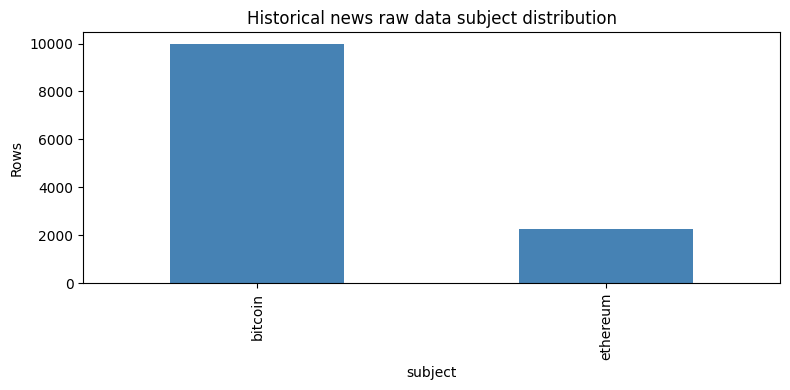

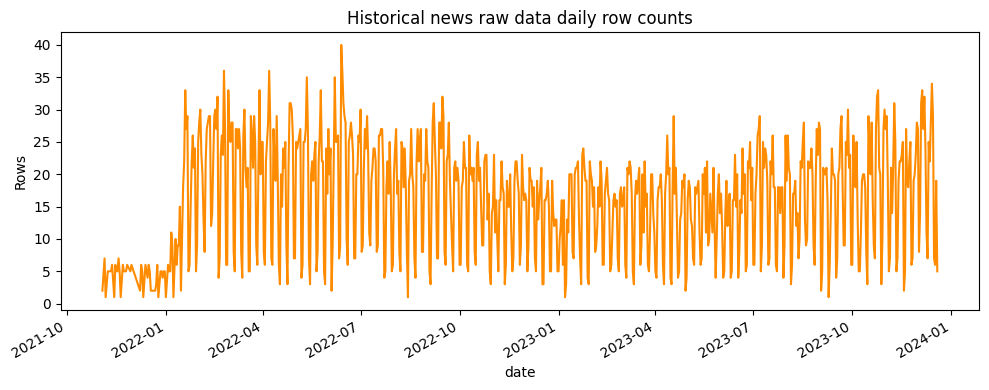


Historical news raw text quality
--------------------------------
dataset: Historical news raw text quality
rows: 12241
missing_text_rows: 0
empty_text_rows: 0
usable_text_rows: 12241
profile_sample_rows: 5000
median_word_count_sample: 21.0
p90_word_count_sample: 30.0
short_text_pct_sample: 0.0
very_short_text_pct_sample: 0.0
duplicate_text_pct_sample: 1.78
english_like_pct_probe: 100.0


In [49]:
news_analysis_df = news_filtered_df[['date', 'subject', 'text']].copy()
raw_news_summary = display_distribution_report('Historical news raw data', news_analysis_df, 'date', 'subject', normalize_subject_from_text_subject)
raw_news_quality_summary = display_text_quality_report('Historical news raw text quality', news_analysis_df, 'text', sample_size=5000, english_probe_size=500)


# Step 3: Refine the Reddit Source

**Inputs**
- the historical Reddit CSV
- the newer Bitcoin and Ethereum JSONL dumps

**Outputs from this stage**
- an in-memory combined Reddit table ready for review and balancing

**Key transformations**
- convert Unix timestamps into notebook-friendly dates
- merge `title` and `selftext` for the JSONL sources
- infer or assign the final subject before later filtering


In [50]:
# Normalize the historical and newer Reddit sources into one combined frame.
historical_reddit_df = pd.read_csv(OLD_INPUTS_DIR / 'reddit' / 'reddit_sentiment_august2021.csv')
assert_columns(historical_reddit_df, ['created_utc', 'body'], 'historical reddit data')
historical_reddit_df['created_utc'] = pd.to_datetime(historical_reddit_df['created_utc'], unit='s', errors='coerce').dt.strftime('%Y-%m-%d')
historical_reddit_df = historical_reddit_df.rename(columns={'body': 'text'})[['created_utc', 'text']]

bitcoin_subject_patterns = [
    r'\bbitcoin\b',
    r'\bbtc\b',
    r'\bbtc price\b',
    r'\bbitcoin price\b',
    r'\bsats\b',
]
ethereum_subject_patterns = [
    r'\bethereum\b',
    r'\beth\b',
    r'\beth price\b',
    r'\bethereum price\b',
    r'\beth gas\b',
    r'\bether\b',
]


## Cell 17: Reddit Ingestion Helpers

**What this section does**
- defines only the helpers needed to build Reddit text from JSONL exports and infer the asset subject from the historical CSV body text

**Why this matters**
- Reddit arrives in two different raw formats, so its normalization logic should be visible right before the Reddit stage


In [51]:
def build_reddit_text(title, selftext):
    title_text = str(title or '').strip()
    body_text = str(selftext or '').strip()
    unusable = {'', '[deleted]', '[removed]', 'nan', 'none'}
    title_ok = title_text.lower() not in unusable
    body_ok = body_text.lower() not in unusable
    if title_ok and body_ok:
        return f'{title_text} {body_text}'.strip()
    if body_ok:
        return body_text
    if title_ok:
        return title_text
    return None
def normalize_reddit_jsonl(path, subject):
    records = []
    with open(path, 'r', encoding='utf-8', errors='ignore') as handle:
        for raw_line in handle:
            line = raw_line.strip()
            if not line:
                continue
            try:
                payload = json.loads(line)
            except json.JSONDecodeError:
                continue
            text = build_reddit_text(payload.get('title'), payload.get('selftext'))
            created_utc = normalize_date(pd.to_datetime(payload.get('created_utc'), unit='s', utc=True, errors='coerce'))
            if text and created_utc:
                records.append({'created_utc': created_utc, 'text': text, 'subject': subject})
    return pd.DataFrame(records)

def _count_subject_pattern_matches(text, patterns):
    return sum(1 for pattern in patterns if re.search(pattern, text))


def identify_subject(text):
    text_lower = str(text).lower()
    bitcoin_matches = _count_subject_pattern_matches(text_lower, bitcoin_subject_patterns)
    ethereum_matches = _count_subject_pattern_matches(text_lower, ethereum_subject_patterns)
    if bitcoin_matches == 0 and ethereum_matches == 0:
        return None
    # Keep an explicit Bitcoin tie-break for posts that mention both assets equally.
    if bitcoin_matches >= ethereum_matches:
        return 'Bitcoin'
    return 'Ethereum'

historical_reddit_df['subject'] = historical_reddit_df['text'].apply(identify_subject)
historical_reddit_df = historical_reddit_df.dropna(subset=['subject'])

new_btc_reddit_df = normalize_reddit_jsonl(NEW_INPUTS_DIR / 'reddit' / 'btc' / 'r_Bitcoin_posts.jsonl', 'Bitcoin')
new_eth_reddit_df = normalize_reddit_jsonl(NEW_INPUTS_DIR / 'reddit' / 'eth' / 'r_ethereum_posts.jsonl', 'Ethereum')
reddit_source_df = pd.concat([historical_reddit_df, new_btc_reddit_df, new_eth_reddit_df], ignore_index=True)
reddit_source_df = reddit_source_df.dropna(subset=['created_utc', 'text', 'subject']).drop_duplicates()
reddit_source_df['created_utc'] = pd.to_datetime(reddit_source_df['created_utc'], errors='coerce')
reddit_source_df = reddit_source_df.dropna(subset=['created_utc'])
reddit_source_df = reddit_source_df[reddit_source_df['created_utc'] <= CUTOFF_DATE]
print('Historical reddit rows:', len(historical_reddit_df))
print('New BTC reddit rows:', len(new_btc_reddit_df))
print('New ETH reddit rows:', len(new_eth_reddit_df))
print('Combined reddit date range:', reddit_source_df['created_utc'].min(), 'to', reddit_source_df['created_utc'].max())


Historical reddit rows: 9824
New BTC reddit rows: 123369
New ETH reddit rows: 10866
Combined reddit date range: 2021-08-01 00:00:00 to 2026-07-26 00:00:00


## Cell 21: Review the Raw Reddit Distribution

**What this section checks**
- how much Reddit data survives subject inference
- whether one coin dominates the other before the balancing step

**Why this matters**
- Reddit can create very dense daily bursts, so the notebook makes the raw imbalance explicit before capping



Historical reddit raw data
--------------------------
dataset: Historical reddit raw data
rows: 9824
date_min: 2021-08-01 00:00:00
date_max: 2021-08-31 00:00:00
days_covered: 31
rows_per_day_avg: 316.9
bitcoin_rows: 6131
ethereum_rows: 3693
other_subject_rows: 0
bitcoin_pct: 62.41
ethereum_pct: 37.59
top_subjects: {'bitcoin': 6131, 'ethereum': 3693}


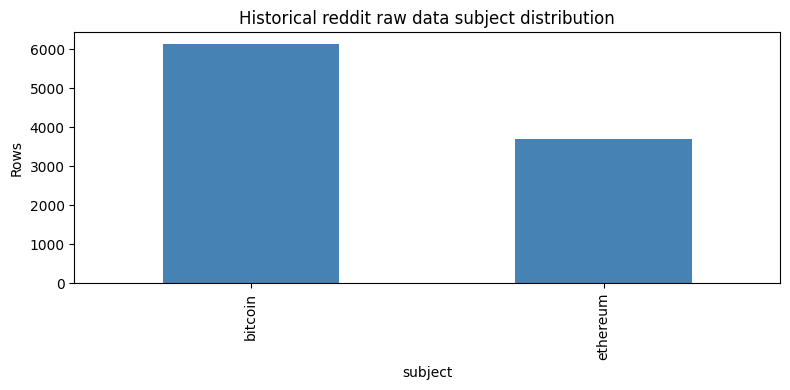

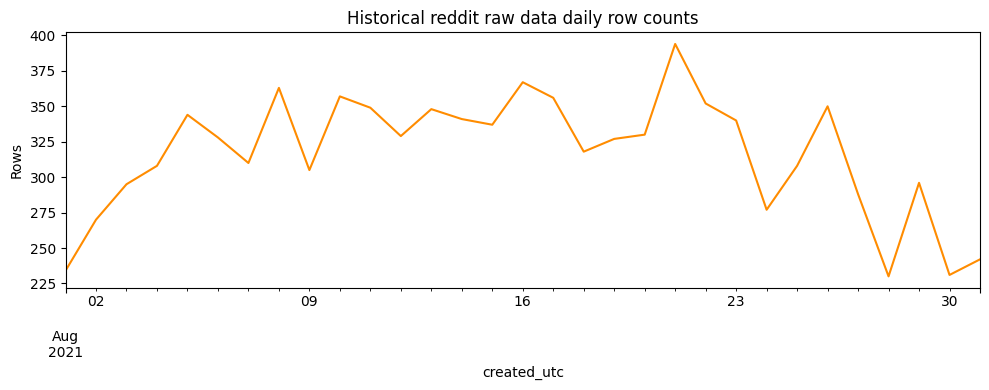


New BTC reddit raw data
-----------------------
dataset: New BTC reddit raw data
rows: 123369
date_min: 2024-10-30 00:00:00
date_max: 2026-07-26 00:00:00
days_covered: 635
rows_per_day_avg: 194.28
bitcoin_rows: 123369
ethereum_rows: 0
other_subject_rows: 0
bitcoin_pct: 100.0
ethereum_pct: 0.0
top_subjects: {'bitcoin': 123369}


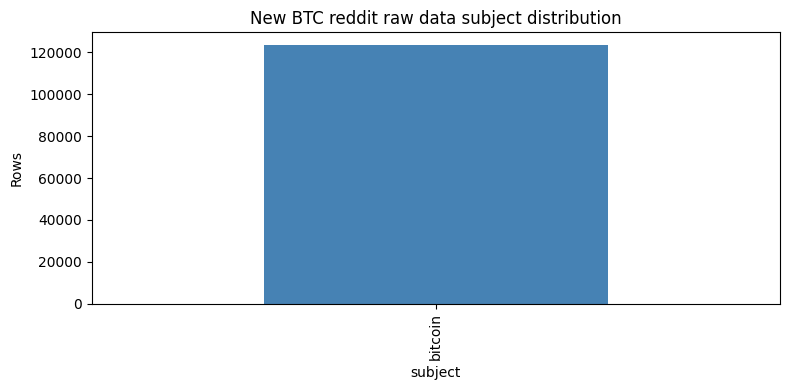

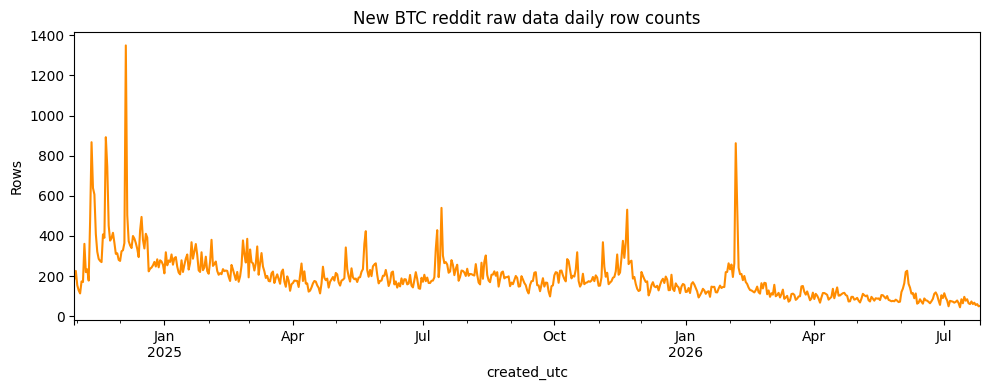


New ETH reddit raw data
-----------------------
dataset: New ETH reddit raw data
rows: 10866
date_min: 2024-10-30 00:00:00
date_max: 2026-07-26 00:00:00
days_covered: 635
rows_per_day_avg: 17.11
bitcoin_rows: 0
ethereum_rows: 10866
other_subject_rows: 0
bitcoin_pct: 0.0
ethereum_pct: 100.0
top_subjects: {'ethereum': 10866}


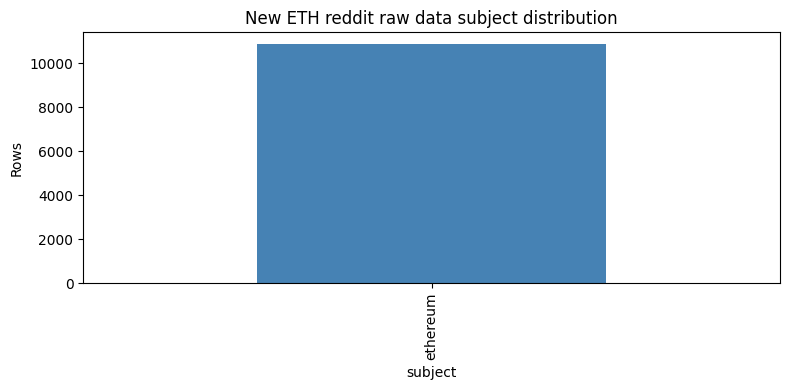

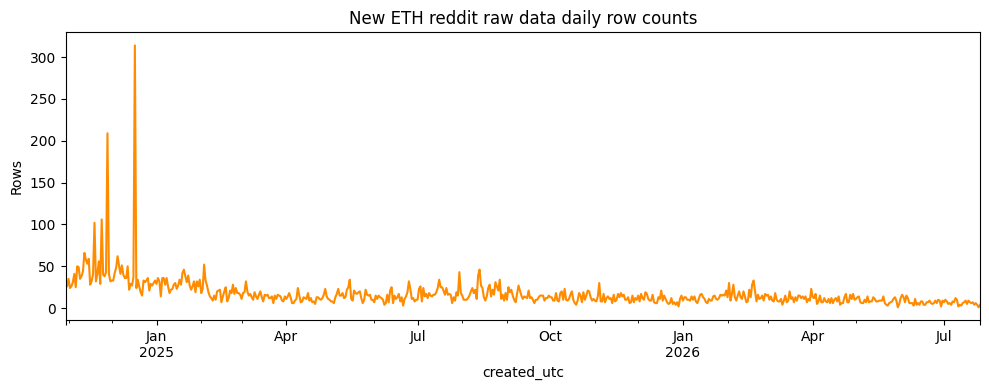


Combined reddit raw data
------------------------
dataset: Combined reddit raw data
rows: 138798
date_min: 2021-08-01 00:00:00
date_max: 2026-07-26 00:00:00
days_covered: 666
rows_per_day_avg: 208.41
bitcoin_rows: 125592
ethereum_rows: 13206
other_subject_rows: 0
bitcoin_pct: 90.49
ethereum_pct: 9.51
top_subjects: {'bitcoin': 125592, 'ethereum': 13206}


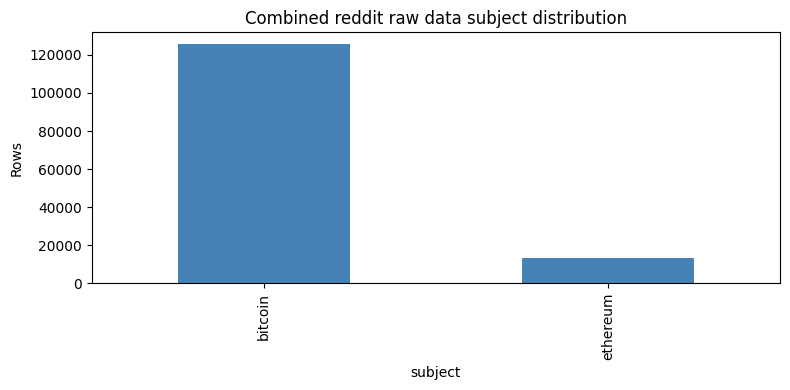

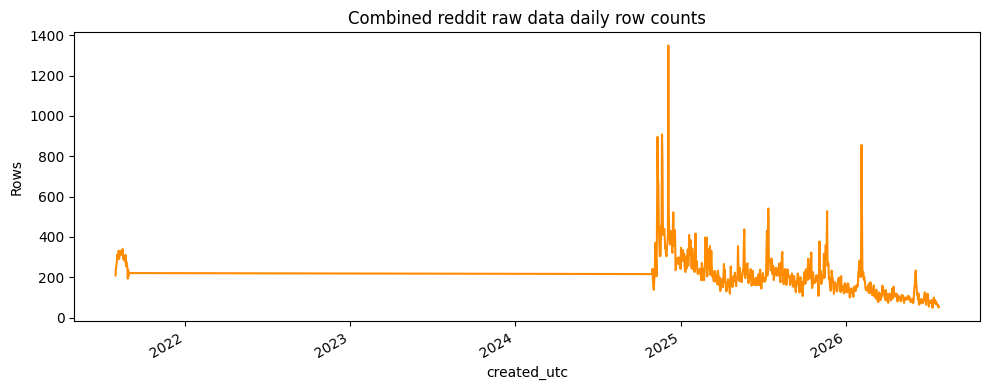

                   dataset   rows   date_min   date_max  days_covered  rows_per_day_avg  bitcoin_rows  ethereum_rows  bitcoin_pct  ethereum_pct  other_subject_rows
  Combined reddit raw data 138798 2021-08-01 2026-07-26           666            208.41        125592          13206        90.49          9.51                   0
   New BTC reddit raw data 123369 2024-10-30 2026-07-26           635            194.28        123369              0       100.00          0.00                   0
   New ETH reddit raw data  10866 2024-10-30 2026-07-26           635             17.11             0          10866         0.00        100.00                   0
Historical reddit raw data   9824 2021-08-01 2021-08-31            31            316.90          6131           3693        62.41         37.59                   0

Dataset size multiples versus the smallest dataset:
                   dataset   rows  size_vs_smallest
  Combined reddit raw data 138798             14.13
   New BTC reddit raw d

In [52]:
raw_reddit_summaries = []
raw_reddit_summaries.append(display_distribution_report('Historical reddit raw data', historical_reddit_df[['created_utc', 'subject', 'text']].copy(), 'created_utc', 'subject', normalize_subject_from_text_subject))
raw_reddit_summaries.append(display_distribution_report('New BTC reddit raw data', new_btc_reddit_df[['created_utc', 'subject', 'text']].copy(), 'created_utc', 'subject', normalize_subject_from_text_subject))
raw_reddit_summaries.append(display_distribution_report('New ETH reddit raw data', new_eth_reddit_df[['created_utc', 'subject', 'text']].copy(), 'created_utc', 'subject', normalize_subject_from_text_subject))
raw_reddit_summaries.append(display_distribution_report('Combined reddit raw data', reddit_source_df[['created_utc', 'subject', 'text']].copy(), 'created_utc', 'subject', normalize_subject_from_text_subject))
raw_reddit_summary_df = display_cross_dataset_imbalance(raw_reddit_summaries)
raw_reddit_quality_summaries = [
    display_text_quality_report('Historical reddit raw text quality', historical_reddit_df[['created_utc', 'subject', 'text']].copy(), 'text', sample_size=5000, english_probe_size=500),
    display_text_quality_report('New BTC reddit raw text quality', new_btc_reddit_df[['created_utc', 'subject', 'text']].copy(), 'text', sample_size=5000, english_probe_size=500),
    display_text_quality_report('New ETH reddit raw text quality', new_eth_reddit_df[['created_utc', 'subject', 'text']].copy(), 'text', sample_size=5000, english_probe_size=500),
    display_text_quality_report('Combined reddit raw text quality', reddit_source_df[['created_utc', 'subject', 'text']].copy(), 'text', sample_size=10000, english_probe_size=1000),
]
raw_reddit_quality_df = display_quality_comparison(raw_reddit_quality_summaries)


## Cell 23: Cross-Source Pre-Cleaning Review

**What this section does**
- compares the three raw sources side by side before cleaning and balancing

**Why this matters**
- the pipeline mixes very different source sizes, so a cross-source view is needed before building working sets


In [53]:
raw_dataset_summaries = [
    summarize_dataset_distribution('social_raw_combined', combined_social_analysis_df, 'datetime', 'label', normalize_subject_value),
    summarize_dataset_distribution('news_raw_filtered', news_analysis_df, 'date', 'subject', normalize_subject_from_text_subject),
    summarize_dataset_distribution('reddit_raw_combined', reddit_source_df[['created_utc', 'subject', 'text']].copy(), 'created_utc', 'subject', normalize_subject_from_text_subject),
]
raw_overview_df = display_cross_dataset_imbalance(raw_dataset_summaries)
raw_quality_overview_summaries = [
    summarize_text_quality('social_raw_combined', combined_social_analysis_df, 'text', sample_size=10000, english_probe_size=1000),
    summarize_text_quality('news_raw_filtered', news_analysis_df, 'text', sample_size=5000, english_probe_size=500),
    summarize_text_quality('reddit_raw_combined', reddit_source_df[['created_utc', 'subject', 'text']].copy(), 'text', sample_size=10000, english_probe_size=1000),
]
raw_quality_overview_df = display_quality_comparison(raw_quality_overview_summaries)
if not raw_overview_df.empty:
    largest_source = raw_overview_df.sort_values('rows', ascending=False).iloc[0]
    smallest_source = raw_overview_df.sort_values('rows', ascending=True).iloc[0]
    print(f"\nLargest raw source before cleaning: {largest_source['dataset']} ({largest_source['rows']:,} rows)")
    print(f"Smallest raw source before cleaning: {smallest_source['dataset']} ({smallest_source['rows']:,} rows)")
    if largest_source['rows'] > smallest_source['rows'] * 10:
        print('- Raw source imbalance is strong enough that downsampling, weighting, or per-day caps should be considered before training.')
    social_summary = raw_overview_df[raw_overview_df['dataset'] == 'social_raw_combined'].iloc[0]
    if social_summary.get('ethereum_rows', 0) < social_summary.get('bitcoin_rows', 0) * 0.1:
        print('- Social media coverage is heavily skewed toward Bitcoin; Ethereum Twitter coverage is minimal in this upgrade.')
    reddit_summary = raw_overview_df[raw_overview_df['dataset'] == 'reddit_raw_combined'].iloc[0]
    news_summary = raw_overview_df[raw_overview_df['dataset'] == 'news_raw_filtered'].iloc[0]
    print(f"- Raw social/news/reddit size ratio: {social_summary['rows']:,} / {news_summary['rows']:,} / {reddit_summary['rows']:,}")
if not raw_quality_overview_df.empty:
    quality_flags = raw_quality_overview_df.set_index('dataset')
    social_quality = quality_flags.loc['social_raw_combined']
    news_quality = quality_flags.loc['news_raw_filtered']
    reddit_quality = quality_flags.loc['reddit_raw_combined']
    print('\nCross-source raw quality flags:')
    if social_quality.get('short_text_pct_sample', 0) > max(news_quality.get('short_text_pct_sample', 0), reddit_quality.get('short_text_pct_sample', 0)):
        print('- Social data has the highest estimated short-text rate, so it is likely to shrink the most during filtering.')
    if social_quality.get('duplicate_text_pct_sample', 0) > 10:
        print('- Social data shows meaningful duplicate pressure in sampled raw text, which can bias sentiment counts.')
    if reddit_quality.get('english_like_pct_probe', 100) < 85:
        print('- Reddit raw text includes enough non-English or noisy rows that cleaning remains important before merging.')


            dataset    rows   date_min   date_max  days_covered  rows_per_day_avg  bitcoin_rows  ethereum_rows  bitcoin_pct  ethereum_pct  other_subject_rows
social_raw_combined 4738024 2024-03-08 2026-03-02           352          13460.30       4703890            312        99.28          0.01               33822
reddit_raw_combined  138798 2021-08-01 2026-07-26           666            208.41        125592          13206        90.49          9.51                   0
  news_raw_filtered   12241 2021-11-03 2023-12-19           758             16.15          9968           2273        81.43         18.57                   0

Dataset size multiples versus the smallest dataset:
            dataset    rows  size_vs_smallest
social_raw_combined 4738024            387.06
reddit_raw_combined  138798             11.34
  news_raw_filtered   12241              1.00
            dataset    rows  usable_text_rows  missing_text_rows  empty_text_rows  profile_sample_rows  median_word_count_sample  p

## Cell 25: Working-Set Helper Functions

**What this section does**
- defines the balancing, capping, safe CSV, and working-set builders used immediately in the next stage

**Why this matters**
- these helpers are about practical retention rules, not general notebook utilities
- placing them here keeps the balancing logic close to the cell that actually applies it


In [54]:
def cap_group_rows(df, group_columns, cap, random_state=42):
    if cap is None or df.empty:
        return df.copy()
    return (
        df.groupby(group_columns, group_keys=False, sort=False)
        .apply(lambda group: group if len(group) <= cap else group.sample(n=cap, random_state=random_state))
        .reset_index(drop=True)
    )
def cap_total_rows_by_day(df, date_column, total_cap, random_state=42, priority_subjects=None):
    if total_cap is None or df.empty:
        return df.copy()
    priority_subjects = priority_subjects or []
    retained_groups = []
    for _, day_group in df.groupby(date_column, sort=False):
        if len(day_group) <= total_cap:
            retained_groups.append(day_group)
            continue
        selected_parts = []
        remaining = total_cap
        for subject in priority_subjects:
            subject_group = day_group[day_group['subject'] == subject]
            if subject_group.empty or remaining <= 0:
                continue
            if len(subject_group) <= remaining:
                retained = subject_group
            else:
                retained = subject_group.sample(n=remaining, random_state=random_state)
            selected_parts.append(retained)
            remaining -= len(retained)
        selected_index = pd.Index([])
        if selected_parts:
            selected_index = pd.concat(selected_parts).index
        leftover = day_group.drop(index=selected_index)
        if remaining > 0 and not leftover.empty:
            leftover = leftover if len(leftover) <= remaining else leftover.sample(n=remaining, random_state=random_state)
            selected_parts.append(leftover)
        retained_groups.append(pd.concat(selected_parts).sort_index() if selected_parts else day_group.sample(n=total_cap, random_state=random_state))
    return pd.concat(retained_groups, ignore_index=True)
def print_daily_distribution_summary(df, date_column, label):
    if df.empty:
        print(f'{label}: no rows retained.')
        return
    date_series = pd.to_datetime(df[date_column], errors='coerce').dropna().dt.normalize()
    if date_series.empty:
        print(f'{label}: no valid dates retained.')
        return
    daily_counts = date_series.value_counts().sort_index()
    print(f'{label} daily rows -> min={int(daily_counts.min())}, median={float(daily_counts.median()):.2f}, max={int(daily_counts.max())}')
def save_intermediate_frame(df, path, label):
    df.to_csv(path, index=False)
    print(f'Saved {label}: {path}')
def safe_read_csv(path, **kwargs):
    try:
        return pd.read_csv(path, **kwargs)
    except pd.errors.ParserError as exc:
        print(f'Falling back to python CSV parser for {Path(path).name}: {exc}')
        fallback_kwargs = dict(kwargs)
        fallback_kwargs.setdefault('engine', 'python')
        return pd.read_csv(path, **fallback_kwargs)
def probable_news_subject_mismatch_mask(df, text_column='text', subject_column='subject'):
    text_series = df[text_column].fillna('').astype(str).str.lower()
    subject_series = df[subject_column].fillna('').astype(str).str.lower()
    mentions_bitcoin = text_series.str.contains(r'\bbitcoin\b|\bbtc\b', regex=True)
    mentions_ethereum = text_series.str.contains(r'\bethereum\b|\beth\b', regex=True)
    ethereum_mismatch = (subject_series == 'ethereum') & (~mentions_ethereum) & mentions_bitcoin
    bitcoin_mismatch = (subject_series == 'bitcoin') & (~mentions_bitcoin) & mentions_ethereum
    return ethereum_mismatch | bitcoin_mismatch
def remove_probable_news_subject_mismatches(df, text_column='text', subject_column='subject'):
    mismatch_mask = probable_news_subject_mismatch_mask(df, text_column=text_column, subject_column=subject_column)
    removed_count = int(mismatch_mask.sum())
    cleaned_df = df.loc[~mismatch_mask].copy()
    return cleaned_df, removed_count
def build_social_working_set(historical_df, new_df):
    historical = historical_df[['datetime', 'text', 'label']].copy()
    historical['source_batch'] = 'historical_social'
    new_rows = new_df[['datetime', 'text', 'label']].copy()
    new_rows['source_batch'] = 'new_btc_twitter'
    social_df = pd.concat([historical, new_rows], ignore_index=True)
    social_df['datetime'] = pd.to_datetime(social_df['datetime'], errors='coerce')
    social_df = social_df.dropna(subset=['datetime', 'text']).copy()
    social_df = social_df[social_df['datetime'] <= CUTOFF_DATE].copy()
    social_df['text'] = social_df['text'].astype(str)
    social_df['subject'] = social_df['label'].apply(canonical_social_subject)
    social_df['date_only'] = social_df['datetime'].dt.normalize()
    social_df['text_key'] = build_text_key_series(social_df['text'])

    rows_before_dedup = len(social_df)
    if ENABLE_DEDUP:
        social_df = social_df.drop_duplicates(subset=['date_only', 'subject', 'text_key'])
    dedup_removed = rows_before_dedup - len(social_df)

    known_df = social_df[social_df['subject'].isin(['bitcoin', 'ethereum'])].copy()
    other_df = social_df[social_df['subject'] == 'other'].copy()
    historical_known_df = known_df[known_df['source_batch'] == 'historical_social'].copy()
    new_known_df = known_df[known_df['source_batch'] != 'historical_social'].copy()

    new_btc_df = cap_group_rows(new_known_df[new_known_df['subject'] == 'bitcoin'].copy(), ['date_only'], SOCIAL_PER_DAY_CAP_BTC, random_state=RANDOM_SEED)
    new_eth_df = cap_group_rows(new_known_df[new_known_df['subject'] == 'ethereum'].copy(), ['date_only'], SOCIAL_PER_DAY_CAP_ETH, random_state=RANDOM_SEED)
    capped_new_df = pd.concat([new_btc_df, new_eth_df], ignore_index=True)
    capped_new_df = cap_total_rows_by_day(capped_new_df, 'date_only', SOCIAL_PER_DAY_CAP_TOTAL, random_state=RANDOM_SEED, priority_subjects=['ethereum', 'bitcoin'])

    working_df = pd.concat([historical_known_df, capped_new_df], ignore_index=True)
    working_df = working_df.sort_values(['datetime', 'subject', 'source_batch']).reset_index(drop=True)

    print()
    print('Social preprocessing control')
    print('----------------------------')
    print('raw_rows:', rows_before_dedup)
    print('dedup_removed:', dedup_removed)
    print('known_rows_before_cap:', len(known_df))
    print('other_rows_excluded:', len(other_df))
    print('historical_rows_retained:', len(historical_known_df))
    print('new_rows_before_cap:', len(new_known_df))
    print('new_rows_after_cap:', len(capped_new_df))
    print('working_rows:', len(working_df))
    print('subject counts before cap:', known_df['subject'].value_counts().to_dict())
    print('subject counts after cap:', working_df['subject'].value_counts().to_dict())
    print_daily_distribution_summary(working_df, 'datetime', 'Social working set')
    if (working_df['subject'] == 'ethereum').sum() == 0:
        print('Ethereum social rows are absent from the retained working set; no synthetic rows will be created.')

    working_df = working_df[['datetime', 'text', 'subject']]
    other_df = other_df[['datetime', 'text', 'label', 'subject']]
    return working_df.reset_index(drop=True), other_df.reset_index(drop=True)
def build_generic_working_set(df, date_column, subject_column, text_column, dataset_name, per_day_cap=None):
    working_df = df[[date_column, text_column, subject_column]].copy()
    working_df[date_column] = pd.to_datetime(working_df[date_column], errors='coerce')
    working_df[subject_column] = working_df[subject_column].astype(str).apply(normalize_subject_from_text_subject)
    working_df = working_df.dropna(subset=[date_column, text_column]).copy()
    working_df = working_df[working_df[date_column] <= CUTOFF_DATE].copy()
    working_df[text_column] = working_df[text_column].astype(str)
    working_df['date_only'] = working_df[date_column].dt.normalize()
    working_df['text_key'] = build_text_key_series(working_df[text_column])

    rows_before_dedup = len(working_df)
    if ENABLE_DEDUP:
        working_df = working_df.drop_duplicates(subset=['date_only', subject_column, 'text_key'])
    dedup_removed = rows_before_dedup - len(working_df)

    probable_subject_mismatches_removed = 0
    if dataset_name == 'news':
        rows_before_subject_cleanup = len(working_df)
        working_df, probable_subject_mismatches_removed = remove_probable_news_subject_mismatches(
            working_df,
            text_column=text_column,
            subject_column=subject_column,
        )
        if probable_subject_mismatches_removed:
            working_df['date_only'] = pd.to_datetime(working_df[date_column], errors='coerce').dt.normalize()
            working_df['text_key'] = build_text_key_series(working_df[text_column])
        print('probable_subject_mismatches_removed:', probable_subject_mismatches_removed)

    rows_before_cap = len(working_df)
    working_df = cap_total_rows_by_day(working_df, 'date_only', per_day_cap, random_state=RANDOM_SEED, priority_subjects=['ethereum', 'bitcoin'])

    print()
    print(f'{dataset_name.title()} preprocessing control')
    print('-' * (len(dataset_name) + 24))
    print('raw_rows:', rows_before_dedup)
    print('dedup_removed:', dedup_removed)
    if dataset_name == 'news':
        print('rows_after_subject_cleanup:', len(working_df))
    print('rows_before_cap:', rows_before_cap)
    print('rows_after_cap:', len(working_df))
    print('subject counts after cap:', working_df[subject_column].value_counts().to_dict())
    print_daily_distribution_summary(working_df, date_column, f'{dataset_name.title()} working set')

    working_df = working_df.drop(columns=['date_only', 'text_key'])
    return working_df.reset_index(drop=True)


## Cell 27: Build Balanced Working Sets

**Inputs**
- raw social, news, and Reddit frames from the previous stages

**Files produced**
- `social_media_working_set.csv`
- `news_working_set.csv`
- `reddit_working_set.csv`

**Key transformations**
- apply per-day caps so a few extreme days do not dominate later sentiment steps
- separate known subjects from `other` social rows
- save the retained working tables for resumable downstream processing


In [55]:
# Build and save the capped working sets that feed the text-cleaning stage.
preprocessing_config = {
    'PREPROCESSING_MODE': PREPROCESSING_MODE,
    'SOCIAL_PER_DAY_CAP_TOTAL': SOCIAL_PER_DAY_CAP_TOTAL,
    'SOCIAL_PER_DAY_CAP_BTC': SOCIAL_PER_DAY_CAP_BTC,
    'SOCIAL_PER_DAY_CAP_ETH': SOCIAL_PER_DAY_CAP_ETH,
    'REDDIT_PER_DAY_CAP_TOTAL': REDDIT_PER_DAY_CAP_TOTAL,
    'NEWS_PER_DAY_CAP_TOTAL': NEWS_PER_DAY_CAP_TOTAL,
    'ENABLE_DEDUP': ENABLE_DEDUP,
    'ENABLE_FAST_LANGUAGE_FILTER': ENABLE_FAST_LANGUAGE_FILTER,
    'ENABLE_SENTIMENT_CHUNKING': ENABLE_SENTIMENT_CHUNKING,
    'RANDOM_SEED': RANDOM_SEED,
}

print('Preprocessing control configuration')
print('-----------------------------------')
for key, value in preprocessing_config.items():
    print(f'{key}: {value}')

social_working_df, social_other_df = build_social_working_set(historical_social_df, normalized_new_tweets_df)
news_working_df = build_generic_working_set(news_filtered_df, 'date', 'subject', 'text', 'news', NEWS_PER_DAY_CAP_TOTAL)
reddit_working_df = build_generic_working_set(reddit_source_df, 'created_utc', 'subject', 'text', 'reddit', REDDIT_PER_DAY_CAP_TOTAL)

save_intermediate_frame(social_working_df, SOCIAL_WORKING_PATH, 'social working set')
save_intermediate_frame(news_working_df, NEWS_WORKING_PATH, 'news working set')
save_intermediate_frame(reddit_working_df, REDDIT_WORKING_PATH, 'reddit working set')

working_summary_df = pd.DataFrame([
    {'dataset': 'social_raw_combined', 'rows': len(combined_social_df)},
    {'dataset': 'social_working', 'rows': len(social_working_df)},
    {'dataset': 'news_raw_filtered', 'rows': len(news_filtered_df)},
    {'dataset': 'news_working', 'rows': len(news_working_df)},
    {'dataset': 'reddit_raw_combined', 'rows': len(reddit_source_df)},
    {'dataset': 'reddit_working', 'rows': len(reddit_working_df)},
])
print()
print('Working-set retention summary')
print('-----------------------------')
print(working_summary_df.to_string(index=False))
print('Excluded social other rows:', len(social_other_df))


Preprocessing control configuration
-----------------------------------
PREPROCESSING_MODE: balanced_cap
SOCIAL_PER_DAY_CAP_TOTAL: 1000
SOCIAL_PER_DAY_CAP_BTC: 700
SOCIAL_PER_DAY_CAP_ETH: 300
REDDIT_PER_DAY_CAP_TOTAL: 400
NEWS_PER_DAY_CAP_TOTAL: None
ENABLE_DEDUP: True
ENABLE_FAST_LANGUAGE_FILTER: True
ENABLE_SENTIMENT_CHUNKING: True
RANDOM_SEED: 42


/var/folders/ld/10g4njkx4bj_f7_yhf22dm1w0000gn/T/ipykernel_97994/2215660912.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: group if len(group) <= cap else group.sample(n=cap, random_state=random_state))



Social preprocessing control
----------------------------
raw_rows: 4738024
dedup_removed: 757602
known_rows_before_cap: 3964344
other_rows_excluded: 16078
historical_rows_retained: 7297
new_rows_before_cap: 3957047
new_rows_after_cap: 139453
working_rows: 146750
subject counts before cap: {'bitcoin': 3964191, 'ethereum': 153}
subject counts after cap: {'bitcoin': 146597, 'ethereum': 153}
Social working set daily rows -> min=1, median=700.00, max=700
probable_subject_mismatches_removed: 104

News preprocessing control
----------------------------
raw_rows: 12241
dedup_removed: 13
rows_after_subject_cleanup: 12124
rows_before_cap: 12124
rows_after_cap: 12124
subject counts after cap: {'bitcoin': 9893, 'ethereum': 2231}
News working set daily rows -> min=1, median=18.00, max=40

Reddit preprocessing control
------------------------------
raw_rows: 138798
dedup_removed: 350
rows_before_cap: 138448
rows_after_cap: 133862
subject counts after cap: {'bitcoin': 120673, 'ethereum': 13189}
Red

## Cell 29: Text Cleaning and BERT Sentiment Helpers

**What this section does**
- defines the language checks, token counting, sentiment model loading, and chunked sentiment-writing logic used in the next three source-specific refinement cells

**Why this matters**
- this stage is where the notebook changes from raw text handling to feature generation
- the expensive BERT logic is kept close to the cells that run it so the flow stays readable


In [20]:
from langdetect import DetectorFactory, detect
from textblob import TextBlob
from transformers import BertTokenizer, pipeline

DetectorFactory.seed = 0
tokenizer = None
sentiment_analyzer = None

COMMON_ENGLISH_WORDS = {
    'a', 'and', 'are', 'as', 'at', 'be', 'bitcoin', 'blockchain', 'buy', 'crypto',
    'ethereum', 'for', 'from', 'has', 'have', 'in', 'is', 'it', 'market', 'of',
    'on', 'or', 'price', 'sell', 'the', 'this', 'to', 'today', 'trading', 'with'
}
FAST_CRYPTO_KEYWORDS = {
    'bitcoin', 'btc', 'ethereum', 'eth', 'crypto', 'cryptocurrency', 'market', 'price',
    'trading', 'bull', 'bear', 'pump', 'dump', 'blockchain', 'token', 'coin', 'wallet'
}

def fast_language_decision(text):
    text = str(text).strip()
    if not text:
        return 'reject'
    tokens = re.findall(r"[A-Za-z']+", text.lower())
    if len(tokens) < MIN_WORDS:
        return 'reject'
    ascii_ratio = sum(character.isascii() for character in text) / max(len(text), 1)
    common_hits = sum(token in COMMON_ENGLISH_WORDS for token in tokens)
    crypto_hits = sum(token in FAST_CRYPTO_KEYWORDS for token in tokens)
    if ascii_ratio >= LANGUAGE_ASCII_ACCEPT_RATIO and (common_hits >= 1 or crypto_hits >= 1 or len(tokens) >= 8):
        return 'accept'
    if ascii_ratio < LANGUAGE_ASCII_REJECT_RATIO:
        return 'reject'
    return 'probe'
def is_probably_english(text):
    text = str(text).strip()
    if not text:
        return False
    tokens = re.findall(r"[A-Za-z']+", text.lower())
    if len(tokens) < 3:
        return False
    try:
        if detect(text) == 'en':
            return True
    except Exception:
        pass
    ascii_ratio = sum(token.isascii() for token in tokens) / len(tokens)
    common_hits = sum(token in COMMON_ENGLISH_WORDS for token in tokens)
    crypto_hits = sum(token in FAST_CRYPTO_KEYWORDS for token in tokens)
    return ascii_ratio >= 0.85 and (common_hits >= 1 or crypto_hits >= 1 or len(tokens) >= 6)
def get_tokenizer():
    global tokenizer
    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
    return tokenizer
def count_tokens(text):
    cleaned_text = re.sub(r'#\w+', '', str(text)).strip()
    return len(get_tokenizer().tokenize(cleaned_text))
def get_sentiment_analyzer():
    global sentiment_analyzer
    if sentiment_analyzer is None:
        sentiment_analyzer = pipeline(
            'sentiment-analysis',
            model='nlptown/bert-base-multilingual-uncased-sentiment',
            framework='pt',
        )
    return sentiment_analyzer
def batched_sentiment(texts, batch_size=16):
    analyzer = get_sentiment_analyzer()
    outputs = []
    for start in range(0, len(texts), batch_size):
        batch = [str(text)[:2000] for text in texts[start:start + batch_size]]
        try:
            results = analyzer(batch, truncation=True, max_length=512, batch_size=batch_size)
            outputs.extend(results)
        except Exception:
            for text in batch:
                try:
                    outputs.append(analyzer(text, truncation=True, max_length=512)[0])
                except Exception:
                    outputs.append({'label': '3 stars', 'score': 0.0})
    return outputs
def calculate_subjectivity(text):
    return TextBlob(str(text)).sentiment.subjectivity
def apply_two_pass_text_filters(df, text_column, date_column, dataset_name, subject_column='subject'):
    filtered_df = df.copy()
    start_rows = len(filtered_df)
    filtered_df[date_column] = pd.to_datetime(filtered_df[date_column], errors='coerce')
    filtered_df = filtered_df.dropna(subset=[date_column, text_column]).copy()
    filtered_df = filtered_df[filtered_df[date_column] <= CUTOFF_DATE].copy()
    filtered_df[text_column] = filtered_df[text_column].astype(str)
    filtered_df['clean_text'] = filtered_df[text_column].map(clean_text_pipeline)
    filtered_df['word_count'] = filtered_df['clean_text'].str.count(r'\S+')
    filtered_df['char_count'] = filtered_df['clean_text'].str.len()
    filtered_df = filtered_df[filtered_df['clean_text'].ne('')].copy()
    filtered_df = filtered_df[filtered_df['word_count'] >= MIN_WORDS].copy()
    filtered_df = filtered_df[filtered_df['char_count'] >= MIN_CHARACTERS].copy()

    filtered_df['text_key'] = build_text_key_series(filtered_df['clean_text'])
    dedup_subset = [date_column, 'text_key']
    if subject_column and subject_column in filtered_df.columns:
        dedup_subset.insert(1, subject_column)
    rows_before_dedup = len(filtered_df)
    if ENABLE_DEDUP:
        filtered_df = filtered_df.drop_duplicates(subset=dedup_subset)
    dedup_removed = rows_before_dedup - len(filtered_df)

    fast_accept_count = 0
    probe_count = 0
    language_rejected = 0
    if ENABLE_FAST_LANGUAGE_FILTER:
        filtered_df['language_path'] = filtered_df['clean_text'].apply(fast_language_decision)
        accepted_df = filtered_df[filtered_df['language_path'] == 'accept'].copy()
        probe_df = filtered_df[filtered_df['language_path'] == 'probe'].copy()
        rejected_fast_df = filtered_df[filtered_df['language_path'] == 'reject'].copy()
        fast_accept_count = len(accepted_df)
        probe_count = len(probe_df)
        language_rejected = len(rejected_fast_df)
        if not probe_df.empty:
            probe_mask = probe_df['clean_text'].apply(is_probably_english)
            language_rejected += int((~probe_mask).sum())
            probe_df = probe_df[probe_mask].copy()
        filtered_df = pd.concat([accepted_df, probe_df], ignore_index=True)
    else:
        probe_count = len(filtered_df)
        language_mask = filtered_df['clean_text'].apply(is_probably_english)
        language_rejected = int((~language_mask).sum())
        filtered_df = filtered_df[language_mask].copy()

    filtered_df['token_count'] = filtered_df['clean_text'].apply(count_tokens)
    rows_before_token_filter = len(filtered_df)
    filtered_df = filtered_df[filtered_df['token_count'] >= MIN_TOKEN_COUNT].copy()
    token_rejected = rows_before_token_filter - len(filtered_df)

    filtered_df[text_column] = filtered_df['clean_text']
    filtered_df = filtered_df.sort_values([date_column, subject_column] if subject_column in filtered_df.columns else [date_column]).reset_index(drop=True)
    filtered_df = filtered_df.drop(columns=['clean_text', 'word_count', 'char_count', 'text_key', 'language_path'], errors='ignore')

    print()
    print(f'{dataset_name.title()} filter summary')
    print('-' * (len(dataset_name) + 15))
    print('start_rows:', start_rows)
    print('rows_after_basic_filters:', rows_before_dedup)
    print('dedup_removed:', dedup_removed)
    print('fast_accept_count:', fast_accept_count)
    print('probe_count:', probe_count)
    print('language_rejected:', language_rejected)
    print('token_rejected:', token_rejected)
    print('final_rows:', len(filtered_df))
    if subject_column in filtered_df.columns:
        print(filtered_df[subject_column].value_counts(dropna=False))
    return filtered_df
def add_sentiment_columns_chunked(df, text_column='text', chunk_size=1000, checkpoint_path=None, dataset_name='dataset'):
    df = df.copy().reset_index(drop=True)
    checkpoint = Path(checkpoint_path) if checkpoint_path is not None else None
    existing_df = pd.DataFrame()

    if checkpoint is not None and checkpoint.exists():
        try:
            existing_df = safe_read_csv(checkpoint)
        except Exception:
            existing_df = pd.DataFrame()

    expected_columns = list(df.columns) + ['sentiment_label', 'sentiment_score']
    if not existing_df.empty:
        checkpoint_is_compatible = len(existing_df) <= len(df) and all(column in existing_df.columns for column in expected_columns)
        if not checkpoint_is_compatible:
            print(f'{dataset_name}: resetting incompatible sentiment checkpoint {checkpoint.name}')
            checkpoint.unlink(missing_ok=True)
            existing_df = pd.DataFrame()

    if checkpoint is not None and existing_df.empty and checkpoint.exists():
        checkpoint.unlink(missing_ok=True)

    completed_rows = len(existing_df)
    if completed_rows == len(df) and completed_rows > 0:
        print(f'{dataset_name}: reusing completed sentiment checkpoint ({completed_rows:,} rows)')
        existing_df['sentiment_score'] = pd.to_numeric(existing_df['sentiment_score'], errors='coerce').fillna(0.0)
        return existing_df.reset_index(drop=True)

    result_frames = [existing_df] if completed_rows else []
    for start in range(completed_rows, len(df), chunk_size):
        chunk_df = df.iloc[start:start + chunk_size].copy()
        sentiments = batched_sentiment(chunk_df[text_column].tolist(), batch_size=16)
        chunk_df['sentiment_label'] = [result.get('label', '3 stars') for result in sentiments]
        chunk_df['sentiment_score'] = [float(result.get('score', 0.0)) for result in sentiments]
        result_frames.append(chunk_df)
        if checkpoint is not None:
            write_header = not checkpoint.exists()
            chunk_df.to_csv(checkpoint, mode='a' if checkpoint.exists() else 'w', header=write_header, index=False)
            print(f'{dataset_name}: saved sentiment chunk {start:,}-{start + len(chunk_df) - 1:,} to {checkpoint.name}')

    final_df = pd.concat(result_frames, ignore_index=True) if result_frames else df.copy()
    if 'sentiment_score' in final_df.columns:
        final_df['sentiment_score'] = pd.to_numeric(final_df['sentiment_score'], errors='coerce').fillna(0.0)
    print(f'{dataset_name}: sentiment rows completed = {len(final_df):,}')
    return final_df.reset_index(drop=True)
def convert_sentiment_label(label):
    if isinstance(label, str) and 'star' in label:
        return int(label.split()[0])
    return 3


/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Cell 31: Refine the Social Working Set

**Inputs**
- `social_media_working_set.csv`

**Files produced**
- `social_media_filtered.csv`
- `social_media_refined_text.csv`

**Key transformations**
- clean the text
- filter low-quality or non-English rows
- add BERT star labels, scores, and token counts
- convert the date field into the final post-level schema used downstream


In [59]:
# Clean the social working set and add BERT sentiment in resumable chunks.
social_working_df = safe_read_csv(SOCIAL_WORKING_PATH)
social_working_df['datetime'] = pd.to_datetime(social_working_df['datetime'], errors='coerce')
social_clean_df = apply_two_pass_text_filters(
    social_working_df,
    text_column='text',
    date_column='datetime',
    dataset_name='social',
    subject_column='subject',
)
save_intermediate_frame(social_clean_df, SOCIAL_FILTERED_PATH, 'social filtered set')

social_refined_df = add_sentiment_columns_chunked(
    social_clean_df,
    text_column='text',
    chunk_size=SOCIAL_SENTIMENT_CHUNK_SIZE if ENABLE_SENTIMENT_CHUNKING else len(social_clean_df),
    checkpoint_path=SOCIAL_SENTIMENT_CHECKPOINT_PATH,
    dataset_name='social',
)
social_refined_df['datetime'] = pd.to_datetime(social_refined_df['datetime'], errors='coerce')
social_refined_df['subject'] = social_refined_df['subject'].astype(str).str.lower()
social_refined_df['date'] = social_refined_df['datetime'].dt.strftime('%Y-%m-%d')
social_refined_df = social_refined_df[['text', 'subject', 'date', 'token_count', 'sentiment_label', 'sentiment_score']].drop_duplicates()
assert_columns(social_refined_df, ['text', 'subject', 'date', 'token_count', 'sentiment_label', 'sentiment_score'], 'social_media_refined_text.csv')
social_refined_df.to_csv(SOCIAL_OUTPUT_PATH, index=False)
print('Saved:', SOCIAL_OUTPUT_PATH)
print(social_refined_df.head())


Falling back to python CSV parser for social_media_working_set.csv: Error tokenizing data. C error: Buffer overflow caught - possible malformed input file.



/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(



Social filter summary
---------------------
start_rows: 146921
rows_after_basic_filters: 144496
dedup_removed: 10
fast_accept_count: 126394
probe_count: 16490
language_rejected: 1618
token_rejected: 4738
final_rows: 138130
subject
bitcoin     137961
ethereum       143
None            26
Name: count, dtype: int64
Saved social filtered set: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/social_media_filtered.csv


/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Xformers is not installed correctly. If you want to use memorry_efficient_attention to accelerate training use the following command to install Xformers
pip install xformers.


social: saved sentiment chunk 0-4,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 5,000-9,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 10,000-14,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 15,000-19,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 20,000-24,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 25,000-29,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 30,000-34,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 35,000-39,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 40,000-44,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 45,000-49,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 50,000-54,999 to social_media_sentiment_checkpoint.csv
social: saved sentiment chunk 55,000-59,999 to social_media_sentiment_che

## Cell 33: Refine the News Working Set

**Inputs**
- `news_working_set.csv`

**Files produced**
- `news_filtered.csv`
- `news_refined_text.csv`

**Key transformations**
- apply the same cleaning and BERT sentiment pattern as the social stage
- keep the final post-level columns in the schema expected by the combined corpus step


In [60]:
# Clean the news working set and attach post-level sentiment features.
news_working_df = safe_read_csv(NEWS_WORKING_PATH)
news_working_df['date'] = pd.to_datetime(news_working_df['date'], errors='coerce')
news_clean_df = apply_two_pass_text_filters(
    news_working_df,
    text_column='text',
    date_column='date',
    dataset_name='news',
    subject_column='subject',
)
save_intermediate_frame(news_clean_df, NEWS_FILTERED_PATH, 'news filtered set')

news_refined_df = add_sentiment_columns_chunked(
    news_clean_df,
    text_column='text',
    chunk_size=NEWS_SENTIMENT_CHUNK_SIZE if ENABLE_SENTIMENT_CHUNKING else len(news_clean_df),
    checkpoint_path=NEWS_SENTIMENT_CHECKPOINT_PATH,
    dataset_name='news',
)
news_refined_df['date'] = pd.to_datetime(news_refined_df['date'], errors='coerce').dt.strftime('%Y-%m-%d')
news_refined_df['subject'] = news_refined_df['subject'].astype(str).str.lower()
news_refined_df = news_refined_df[['date', 'subject', 'text', 'sentiment_label', 'sentiment_score', 'token_count']].drop_duplicates()
assert_columns(news_refined_df, ['date', 'subject', 'text', 'sentiment_label', 'sentiment_score', 'token_count'], 'news_refined_text.csv')
news_refined_df.to_csv(NEWS_OUTPUT_PATH, index=False)
print('Saved:', NEWS_OUTPUT_PATH)
print(news_refined_df.head())



News filter summary
-------------------
start_rows: 12124
rows_after_basic_filters: 12124
dedup_removed: 0
fast_accept_count: 12084
probe_count: 40
language_rejected: 0
token_rejected: 0
final_rows: 12124
subject
bitcoin     9893
ethereum    2231
Name: count, dtype: int64
Saved news filtered set: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/news_filtered.csv
news: reusing completed sentiment checkpoint (12,124 rows)
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/news_refined_text.csv
         date   subject                                               text  \
0  2021-11-03  ethereum  The protocol will allow users to vote on the E...   
1  2021-11-05   bitcoin  'Several companies' are looking to Latin Ameri...   
2  2021-11-05   bitcoin  There is still potential for the price of bitc...   
3  2021-11-05   bitcoin  Bitcoin increasingly becomin

## Cell 35: Refine the Reddit Working Set

**Inputs**
- `reddit_working_set.csv`

**Files produced**
- `reddit_filtered.csv`
- `reddit_refined_text.csv`

**Key transformations**
- keep Reddit-specific date handling visible with `created_utc`
- apply the same quality filters and BERT enrichment as the other text sources


In [61]:
# Clean the Reddit working set and preserve its post-level date column until the canonical rebuild.
reddit_working_df = safe_read_csv(REDDIT_WORKING_PATH)
reddit_working_df['created_utc'] = pd.to_datetime(reddit_working_df['created_utc'], errors='coerce')
reddit_clean_df = apply_two_pass_text_filters(
    reddit_working_df,
    text_column='text',
    date_column='created_utc',
    dataset_name='reddit',
    subject_column='subject',
)
save_intermediate_frame(reddit_clean_df, REDDIT_FILTERED_PATH, 'reddit filtered set')

reddit_refined_df = add_sentiment_columns_chunked(
    reddit_clean_df,
    text_column='text',
    chunk_size=REDDIT_SENTIMENT_CHUNK_SIZE if ENABLE_SENTIMENT_CHUNKING else len(reddit_clean_df),
    checkpoint_path=REDDIT_SENTIMENT_CHECKPOINT_PATH,
    dataset_name='reddit',
)
reddit_refined_df['created_utc'] = pd.to_datetime(reddit_refined_df['created_utc'], errors='coerce').dt.strftime('%Y-%m-%d')
reddit_refined_df['subject'] = reddit_refined_df['subject'].astype(str).str.lower()
reddit_refined_df = reddit_refined_df[['created_utc', 'text', 'subject', 'token_count', 'sentiment_label', 'sentiment_score']].drop_duplicates()
assert_columns(reddit_refined_df, ['created_utc', 'text', 'subject', 'token_count', 'sentiment_label', 'sentiment_score'], 'reddit_refined_text.csv')
reddit_refined_df.to_csv(REDDIT_OUTPUT_PATH, index=False)
print('Saved:', REDDIT_OUTPUT_PATH)
print(reddit_refined_df.head())



Reddit filter summary
---------------------
start_rows: 133862
rows_after_basic_filters: 116135
dedup_removed: 0
fast_accept_count: 106268
probe_count: 8430
language_rejected: 2109
token_rejected: 582
final_rows: 113444
subject
bitcoin     101643
ethereum     11801
Name: count, dtype: int64
Saved reddit filtered set: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/reddit_filtered.csv
reddit: resetting incompatible sentiment checkpoint reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 0-1,999 to reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 2,000-3,999 to reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 4,000-5,999 to reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 6,000-7,999 to reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 8,000-9,999 to reddit_sentiment_checkpoint.csv
reddit: saved sentiment chunk 10,000-11,999 to reddit_sentiment_checkpoint.csv
r

# Step 4: Rebuild the BTC and ETH Price Files

**Inputs**
- historical BTC and ETH daily OHLC files
- new BTC and ETH daily OHLC files
- Binance quote-asset volume API

**Files produced**
- `BTC.csv`
- `ETH.csv`

**Key transformations**
- stitch old and new price history together
- add `trading_volume_usdt`
- calculate the technical indicators that will later feed the day-level models


In [62]:
from urllib.parse import urlencode
from urllib.request import urlopen

old_btc_prices = pd.read_csv(OLD_INPUTS_DIR / 'prices' / 'BTC.csv')
old_eth_prices = pd.read_csv(OLD_INPUTS_DIR / 'prices' / 'ETH.csv')
new_btc_prices = pd.read_csv(NEW_INPUTS_DIR / 'prices' / 'BTC_daily_prices_2024-10-25_to_2026-07-27.csv')
new_eth_prices = pd.read_csv(NEW_INPUTS_DIR / 'prices' / 'ETH_daily_prices_2024-10-25_to_2026-07-27.csv')


def fetch_binance_quote_asset_volume(symbol: str, start_date: str, end_date: str) -> pd.DataFrame:
    base_url = 'https://api.binance.com/api/v3/klines'
    start_ts = int(pd.Timestamp(start_date, tz='UTC').timestamp() * 1000)
    end_ts = int((pd.Timestamp(end_date, tz='UTC') + pd.Timedelta(days=1) - pd.Timedelta(milliseconds=1)).timestamp() * 1000)
    rows = []
    next_start = start_ts

    while next_start <= end_ts:
        params = {
            'symbol': symbol,
            'interval': '1d',
            'startTime': next_start,
            'endTime': end_ts,
            'limit': 1000,
        }
        with urlopen(f"{base_url}?{urlencode(params)}") as response:
            payload = json.loads(response.read().decode('utf-8'))
        if not payload:
            break

        for item in payload:
            rows.append(
                {
                    'date': pd.to_datetime(item[0], unit='ms', utc=True).strftime('%Y-%m-%d'),
                    'trading_volume_usdt': float(item[7]),
                }
            )
        next_start = int(payload[-1][0]) + 24 * 60 * 60 * 1000

    return pd.DataFrame(rows).drop_duplicates(subset=['date']).sort_values('date').reset_index(drop=True)


def attach_binance_quote_volume(price_df: pd.DataFrame, symbol: str) -> pd.DataFrame:
    price_df = price_df.copy()
    price_df['date'] = pd.to_datetime(price_df['date'], errors='coerce')
    start_date = price_df['date'].min().strftime('%Y-%m-%d')
    end_date = min(price_df['date'].max(), CUTOFF_DATE).strftime('%Y-%m-%d')
    volume_df = fetch_binance_quote_asset_volume(symbol, start_date, end_date)
    volume_df['date'] = pd.to_datetime(volume_df['date'], errors='coerce')
    price_df = price_df.merge(volume_df, on='date', how='left')
    return price_df


def add_technical_indicators(price_df: pd.DataFrame) -> pd.DataFrame:
    price_df = price_df.copy().sort_values('date').reset_index(drop=True)
    close = pd.to_numeric(price_df['close'], errors='coerce')
    high = pd.to_numeric(price_df['high'], errors='coerce')
    low = pd.to_numeric(price_df['low'], errors='coerce')

    price_df['sma_14'] = close.rolling(window=14, min_periods=1).mean()
    price_df['ema_14'] = close.ewm(span=14, adjust=False).mean()

    delta = close.diff()
    gains = delta.clip(lower=0)
    losses = (-delta).clip(lower=0)
    avg_gain = gains.ewm(alpha=1/14, adjust=False, min_periods=14).mean()
    avg_loss = losses.ewm(alpha=1/14, adjust=False, min_periods=14).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    price_df['rsi_14'] = (100 - (100 / (1 + rs))).fillna(50.0)

    prev_close = close.shift(1)
    true_range = pd.concat(
        [
            (high - low),
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    price_df['atr_14'] = true_range.ewm(alpha=1/14, adjust=False, min_periods=14).mean()
    return price_df


## Cell 39: Execute the Price Rebuild

**What this cell does**
- runs the BTC and ETH rebuild helpers immediately after they are defined
- prints basic coverage and missing-volume diagnostics

**Why this matters**
- the later trade-day dataset depends on these rebuilt price files, so the market context is made explicit before the canonical text rebuild


In [63]:
# Rebuild the BTC and ETH market files with Binance quote volume and technical indicators.
btc_prices = pd.concat([old_btc_prices, new_btc_prices], ignore_index=True)
eth_prices = pd.concat([old_eth_prices, new_eth_prices], ignore_index=True)

for price_df in [btc_prices, eth_prices]:
    price_df['date'] = pd.to_datetime(price_df['date'], errors='coerce')

btc_overlap_rows = int(btc_prices.dropna(subset=['date']).duplicated(subset=['ticker', 'date'], keep=False).sum())
eth_overlap_rows = int(eth_prices.dropna(subset=['date']).duplicated(subset=['ticker', 'date'], keep=False).sum())

btc_prices = btc_prices.dropna(subset=['date']).drop_duplicates(subset=['ticker', 'date'], keep='last').sort_values('date').reset_index(drop=True)
eth_prices = eth_prices.dropna(subset=['date']).drop_duplicates(subset=['ticker', 'date'], keep='last').sort_values('date').reset_index(drop=True)
btc_prices = btc_prices[btc_prices['date'] <= CUTOFF_DATE]
eth_prices = eth_prices[eth_prices['date'] <= CUTOFF_DATE]

btc_prices = attach_binance_quote_volume(btc_prices, 'BTCUSDT')
eth_prices = attach_binance_quote_volume(eth_prices, 'ETHUSDT')
btc_prices = add_technical_indicators(btc_prices)
eth_prices = add_technical_indicators(eth_prices)

btc_prices['date'] = btc_prices['date'].dt.strftime('%Y-%m-%d')
eth_prices['date'] = eth_prices['date'].dt.strftime('%Y-%m-%d')

btc_prices.to_csv(BTC_OUTPUT_PATH, index=False)
eth_prices.to_csv(ETH_OUTPUT_PATH, index=False)

print('BTC range:', btc_prices['date'].min(), 'to', btc_prices['date'].max(), '| duplicates:', btc_prices.duplicated(subset=['ticker', 'date']).sum(), '| overlap rows resolved:', btc_overlap_rows, '| volume missing:', int(btc_prices['trading_volume_usdt'].isna().sum()))
print('ETH range:', eth_prices['date'].min(), 'to', eth_prices['date'].max(), '| duplicates:', eth_prices.duplicated(subset=['ticker', 'date']).sum(), '| overlap rows resolved:', eth_overlap_rows, '| volume missing:', int(eth_prices['trading_volume_usdt'].isna().sum()))


BTC range: 2010-07-17 to 2026-07-27 | duplicates: 0 | overlap rows resolved: 0 | volume missing: 2588
ETH range: 2015-08-07 to 2026-07-27 | duplicates: 0 | overlap rows resolved: 0 | volume missing: 741


# Step 5: Combine the Refined Text Sources

**Inputs**
- the refined social, news, and Reddit files

**Files produced**
- `combined_subjectivity.csv`

**Key transformations**
- stack all three sources into one shared post schema
- add `source` so the origin of every row is preserved
- compute a subjectivity score that will later become a daily aggregate feature


In [64]:
# Combine the refined source files into one post-level corpus with subjectivity scores.
news_df = safe_read_csv(NEWS_OUTPUT_PATH)
twitter_df = safe_read_csv(SOCIAL_OUTPUT_PATH)
reddit_df = safe_read_csv(REDDIT_OUTPUT_PATH)

news_df['source'] = 'news'
news_df['created_utc'] = pd.NA
twitter_df['source'] = 'twitter'
twitter_df['created_utc'] = pd.NA
reddit_df['source'] = 'reddit'
reddit_df['date'] = pd.NA

combined_subjectivity_df = pd.concat([news_df, twitter_df, reddit_df], ignore_index=True, sort=False)
combined_subjectivity_df['subjectivity_score'] = combined_subjectivity_df['text'].apply(calculate_subjectivity)
combined_subjectivity_df = combined_subjectivity_df[['date', 'subject', 'text', 'sentiment_label', 'sentiment_score', 'token_count', 'source', 'created_utc', 'subjectivity_score']]
combined_subjectivity_df.to_csv(COMBINED_SUBJECTIVITY_PATH, index=False)
print('Saved:', COMBINED_SUBJECTIVITY_PATH)
print(combined_subjectivity_df.head())


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/combined_subjectivity.csv
         date   subject                                               text  \
0  2021-11-03  ethereum  The protocol will allow users to vote on the E...   
1  2021-11-05   bitcoin  'Several companies' are looking to Latin Ameri...   
2  2021-11-05   bitcoin  There is still potential for the price of bitc...   
3  2021-11-05   bitcoin  Bitcoin increasingly becoming a political inst...   
4  2021-11-05   bitcoin  Congress could finally approve or reject the m...   

  sentiment_label  sentiment_score  token_count source created_utc  \
0         4 stars         0.389622           13   news         NaN   
1         3 stars         0.261716           26   news         NaN   
2         3 stars         0.422669           30   news         NaN   
3         2 stars         0.254360           30   news         NaN   
4         5 stars         0.24796

# Step 6: PyABSA and Canonical Post-Corpus Helpers

**What this section does**
- defines the resumable PyABSA handling and the rules for rebuilding the canonical final corpus
- derives post-level sentiment confidence and explicit polarity fields immediately after the canonical rebuild

**Why this matters**
- the canonical rebuild is one of the highest-risk stages in the notebook
- the date repair, duplicate removal, August 2021 exclusion, polarity derivation, and resumability rules should stay visible right before execution


In [18]:
from __future__ import annotations

import copy
import os
from contextlib import contextmanager
from typing import Iterable

VALID_SENTIMENTS = ("Positive", "Negative", "Neutral")
TARGET_MAP = {"Buy": 0, "Neutral": 1, "Sell": 2}
MODEL_LABELS = ["Buy", "Neutral", "Sell"]

@contextmanager
def temporary_chdir(target_dir: str | Path):
    original_dir = Path.cwd()
    os.chdir(Path(target_dir))
    try:
        yield
    finally:
        os.chdir(original_dir)


def ensure_pyabsa_runtime_compatibility() -> None:
    os.environ.setdefault("PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION", "python")
    import importlib

    update_checker = importlib.import_module("update_checker")
    update_core = getattr(update_checker, "core", update_checker)

    original_check = update_core.UpdateChecker.check
    if getattr(original_check, "_codex_compat_wrapped", False):
        return

    def compat_check(self, *args, **kwargs):
        if args and not kwargs:
            if len(args) != 2:
                raise TypeError(f"Unexpected positional arguments for UpdateChecker.check: {args!r}")
            kwargs = {"package_name": args[0], "package_version": args[1]}
        return original_check(self, **kwargs)

    compat_check._codex_compat_wrapped = True
    update_core.UpdateChecker.check = compat_check

    try:
        from transformers import DebertaV2TokenizerFast

        if not hasattr(DebertaV2TokenizerFast, "bos_token"):
            DebertaV2TokenizerFast.bos_token = None
        if not hasattr(DebertaV2TokenizerFast, "eos_token"):
            DebertaV2TokenizerFast.eos_token = None
        if not hasattr(DebertaV2TokenizerFast, "split_special_tokens"):
            DebertaV2TokenizerFast.split_special_tokens = False
    except Exception:
        pass


def _attach_checkpoint_metadata(
    extractor,
    *,
    requested_checkpoint: str | None,
    actual_checkpoint: str | None,
    used_fallback: bool,
    note: str | None = None,
):
    metadata = {
        "requested_checkpoint": requested_checkpoint,
        "actual_checkpoint": actual_checkpoint,
        "used_fallback": bool(used_fallback),
        "note": note,
    }
    try:
        extractor._codex_checkpoint_metadata = metadata
    except Exception:
        pass
    return extractor


def load_pyabsa_extractor(checkpoint_hint: str | Path | None = None):
    ensure_pyabsa_runtime_compatibility()
    from pyabsa import ATEPCCheckpointManager

    checkpoint = Path(checkpoint_hint).resolve() if checkpoint_hint else None
    if checkpoint is None:
        extractor = ATEPCCheckpointManager.get_aspect_extractor(checkpoint="english")
        return _attach_checkpoint_metadata(
            extractor,
            requested_checkpoint=None,
            actual_checkpoint="english",
            used_fallback=False,
            note="No local checkpoint hint was provided for this run.",
        )

    common_root = Path(os.path.commonpath([str(Path.cwd().resolve()), str(checkpoint)]))
    try:
        with temporary_chdir(common_root):
            extractor = ATEPCCheckpointManager.get_aspect_extractor(checkpoint=str(checkpoint))
        return _attach_checkpoint_metadata(
            extractor,
            requested_checkpoint=str(checkpoint),
            actual_checkpoint=str(checkpoint),
            used_fallback=False,
        )
    except Exception as exc:
        message = str(exc)
        incompatible_checkpoint = (
            "pyabsa.functional" in message
            or "The checkpoint you are loading is not from any ATEPC model" in message
            or "Fail to load the model" in message
        )
        if not incompatible_checkpoint:
            raise
        print(
            "Local PyABSA checkpoint is incompatible with the installed runtime; "
            "falling back to the bundled 'english' checkpoint."
        )
        extractor = ATEPCCheckpointManager.get_aspect_extractor(checkpoint="english")
        return _attach_checkpoint_metadata(
            extractor,
            requested_checkpoint=str(checkpoint),
            actual_checkpoint="english",
            used_fallback=True,
            note="Local checkpoint was incompatible with the installed runtime, so this run used the bundled english checkpoint instead.",
        )
def _normalize_sentiment_values(value) -> list[str]:
    if value is None:
        return []
    if isinstance(value, str):
        stripped = value.strip()
        if not stripped:
            return []
        if stripped.startswith("[") and stripped.endswith("]"):
            try:
                parsed = ast.literal_eval(stripped)
            except Exception:
                parsed = [stripped]
        else:
            parsed = [stripped]
    elif isinstance(value, (list, tuple, set)):
        parsed = list(value)
    else:
        parsed = [value]

    cleaned = []
    for item in parsed:
        item_str = str(item).strip().title()
        if item_str in VALID_SENTIMENTS:
            cleaned.append(item_str)
    return cleaned
def serialize_sentiments(sentiments: Iterable[str]) -> str:
    cleaned = [sentiment for sentiment in sentiments if sentiment in VALID_SENTIMENTS]
    return str(cleaned or ["Neutral"])
def normalize_price_sentiment(value) -> str:
    return serialize_sentiments(_normalize_sentiment_values(value))
def extract_sentiments(value) -> list[str]:
    return _normalize_sentiment_values(value) or ["Neutral"]
def _collect_price_sentiments(node, sentiments: list[str]) -> None:
    if isinstance(node, dict):
        aspect = str(node.get("aspect", "")).lower()
        if "price" in aspect:
            sentiments.extend(_normalize_sentiment_values(node.get("sentiment")))
        for child in node.values():
            _collect_price_sentiments(child, sentiments)
        return
    if isinstance(node, (list, tuple)):
        for item in node:
            _collect_price_sentiments(item, sentiments)
def extract_price_sentiment(text: str, model) -> str:
    result = model.extract_aspect([str(text)])
    sentiments: list[str] = []
    _collect_price_sentiments(result, sentiments)
    return serialize_sentiments(sentiments)

def derive_sentiment_polarity(label) -> float:
    star_value = convert_sentiment_label(label)
    return float((star_value - 3) / 2)

def _add_canonical_sentiment_features(df: pd.DataFrame) -> pd.DataFrame:
    enriched_df = df.copy()
    if "sentiment_score" not in enriched_df.columns:
        enriched_df["sentiment_score"] = 0.0
    enriched_df["sentiment_score"] = pd.to_numeric(enriched_df["sentiment_score"], errors="coerce").fillna(0.0)
    enriched_df["sentiment_confidence"] = enriched_df["sentiment_score"]
    enriched_df["sentiment_polarity"] = enriched_df["sentiment_label"].apply(derive_sentiment_polarity)
    enriched_df["confidence_weighted_polarity"] = (
        enriched_df["sentiment_polarity"] * enriched_df["sentiment_confidence"]
    )
    return enriched_df
def _load_existing_chunk_output(output_path: str | Path, expected_rows: int) -> pd.DataFrame:
    output_path = Path(output_path)
    if not output_path.exists():
        return pd.DataFrame()
    existing_df = pd.read_csv(output_path)
    if "price_sentiment" not in existing_df.columns:
        return pd.DataFrame()
    unique_values = existing_df["price_sentiment"].astype(str).nunique(dropna=False)
    if unique_values <= 1:
        print(f"Ignoring stale partial output at {output_path} because price_sentiment has no variation.")
        return pd.DataFrame()
    if len(existing_df) > expected_rows:
        return existing_df.iloc[:expected_rows].copy()
    return existing_df.copy()
def _write_progress(progress_path: str | Path, payload: dict) -> None:
    Path(progress_path).write_text(json.dumps(payload, indent=2))
def _read_progress(progress_path: str | Path) -> dict:
    progress_path = Path(progress_path)
    if not progress_path.exists():
        return {}
    try:
        return json.loads(progress_path.read_text())
    except Exception:
        return {}
def _write_chunk_output(
    output_path: str | Path,
    chunk_df: pd.DataFrame,
    *,
    append: bool,
) -> None:
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    chunk_df = chunk_df.drop(columns=["row_id"], errors="ignore")
    if append:
        chunk_df.to_csv(output_path, mode="a", header=False, index=False)
    else:
        chunk_df.to_csv(output_path, mode="w", header=True, index=False)
def _sorted_copy(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    return df.sort_values(columns, kind="mergesort").reset_index(drop=True)
def _assert_monotonic_dates(date_series: pd.Series, label: str) -> None:
    dates = pd.to_datetime(date_series, errors="coerce")
    descending = dates.diff().dt.total_seconds().fillna(0) < 0
    if bool(descending.any()):
        first_bad_index = int(descending[descending].index[0])
        previous_index = max(0, first_bad_index - 1)
        raise ValueError(
            f"{label} is not chronologically ordered. "
            f"Date at row {previous_index} is {dates.iloc[previous_index]!s}, "
            f"but row {first_bad_index} is {dates.iloc[first_bad_index]!s}."
        )
def _is_excluded_august_2021(date_series: pd.Series) -> pd.Series:
    dates = pd.to_datetime(date_series, errors="coerce")
    return (dates.dt.year == 2021) & (dates.dt.month == 8)
def _build_canonical_final_combined_df(
    source_df: pd.DataFrame,
    inferred_df: pd.DataFrame,
    cutoff_date,
) -> tuple[pd.DataFrame, dict]:
    canonical_df = source_df.copy()
    inferred_row_ids = pd.Index(inferred_df["row_id"]) if "row_id" in inferred_df.columns else pd.Index([])
    canonical_df["price_sentiment"] = canonical_df["row_id"].map(
        inferred_df.set_index("row_id")["price_sentiment"].to_dict()
    )
    canonical_df["price_sentiment"] = canonical_df["price_sentiment"].apply(normalize_price_sentiment)
    canonical_df["price_sentiment_inferred"] = canonical_df["row_id"].isin(inferred_row_ids)
    canonical_df["date"] = canonical_df["date"].fillna(canonical_df["created_utc"])
    canonical_df["date"] = pd.to_datetime(canonical_df["date"], errors="coerce")
    missing_dates_before_drop = int(canonical_df["date"].isna().sum())
    canonical_df = canonical_df.dropna(subset=["date"]).copy()
    excluded_august_2021_rows = int(_is_excluded_august_2021(canonical_df["date"]).sum())
    canonical_df = canonical_df[~_is_excluded_august_2021(canonical_df["date"])].copy()
    canonical_df = canonical_df[canonical_df["date"] <= pd.Timestamp(cutoff_date)].copy()
    canonical_df["date"] = canonical_df["date"].dt.strftime("%Y-%m-%d")
    canonical_df = _add_canonical_sentiment_features(canonical_df)
    default_neutral_rows = int(
        ((~canonical_df["price_sentiment_inferred"]) & canonical_df["source"].eq("reddit")).sum()
    )
    duplicate_count_before_drop = int(canonical_df.duplicated(subset=["date", "subject", "source", "text"]).sum())
    canonical_df = _sorted_copy(canonical_df, ["date", "subject", "source"])
    canonical_df = canonical_df.drop_duplicates(subset=["date", "subject", "source", "text"], keep="first").reset_index(drop=True)
    canonical_df = canonical_df[
        [
            "date",
            "subject",
            "text",
            "sentiment_label",
            "sentiment_score",
            "sentiment_confidence",
            "sentiment_polarity",
            "confidence_weighted_polarity",
            "token_count",
            "source",
            "subjectivity_score",
            "price_sentiment",
            "price_sentiment_inferred",
        ]
    ]
    _assert_monotonic_dates(canonical_df["date"], "final_combined_with_pybsa.csv")
    return canonical_df, {
        "missing_dates_before_drop": missing_dates_before_drop,
        "excluded_august_2021_rows": excluded_august_2021_rows,
        "duplicates_removed": duplicate_count_before_drop,
        "default_neutral_rows": default_neutral_rows,
        "price_sentiment_inferred_true": int(canonical_df["price_sentiment_inferred"].sum()),
        "price_sentiment_inferred_false": int((~canonical_df["price_sentiment_inferred"]).sum()),
    }
def _attach_row_ids_by_content(source_df: pd.DataFrame, inferred_df: pd.DataFrame) -> pd.DataFrame:
    if inferred_df.empty:
        return inferred_df.copy()

    candidate_join_sets = [
        [
            "date",
            "subject",
            "text",
            "sentiment_label",
            "sentiment_score",
            "token_count",
            "source",
            "created_utc",
            "subjectivity_score",
        ],
        [
            "date",
            "text",
            "sentiment_label",
            "sentiment_score",
            "token_count",
            "source",
            "created_utc",
            "subjectivity_score",
        ],
        [
            "text",
            "sentiment_label",
            "sentiment_score",
            "token_count",
            "source",
            "created_utc",
            "subjectivity_score",
        ],
    ]

    for candidate_columns in candidate_join_sets:
        join_columns = [
            column
            for column in candidate_columns
            if column in source_df.columns and column in inferred_df.columns
        ]
        if not join_columns:
            continue

        source_keyed = source_df[["row_id", *join_columns]].copy()
        inferred_keyed = inferred_df.copy()
        source_keyed["_dup_rank"] = source_keyed.groupby(join_columns, dropna=False).cumcount()
        inferred_keyed["_dup_rank"] = inferred_keyed.groupby(join_columns, dropna=False).cumcount()
        merged = inferred_keyed.merge(source_keyed, on=[*join_columns, "_dup_rank"], how="left")
        missing_row_ids = int(merged["row_id"].isna().sum())
        if missing_row_ids == 0:
            if "subject" not in join_columns:
                print(
                    "Reused existing pybsa rows with a relaxed content match because subject labels changed upstream."
                )
            return merged.drop(columns=["_dup_rank"])

    raise ValueError(
        "Failed to map existing pybsa rows back to combined_subjectivity.csv even after relaxed matching. "
        "Delete the stale pybsa checkpoint/progress files or rerun the PyABSA stage from scratch."
    )
def summarize_canonical_post_dataset(final_combined_path: str | Path) -> dict:
    df = pd.read_csv(final_combined_path)
    if "sentiment_confidence" not in df.columns or "sentiment_polarity" not in df.columns:
        df = _add_canonical_sentiment_features(df)
    if "price_sentiment_inferred" not in df.columns:
        df["price_sentiment_inferred"] = pd.NA
    parsed_dates = pd.to_datetime(df["date"], errors="coerce")
    missing_dates = int(parsed_dates.isna().sum())
    duplicate_count = int(df.duplicated(subset=["date", "subject", "source", "text"]).sum())
    august_2021_rows = int(_is_excluded_august_2021(parsed_dates).sum())
    _assert_monotonic_dates(df["date"], "final_combined_with_pybsa.csv")
    return {
        "rows": int(len(df)),
        "date_range": {"min": str(parsed_dates.min().date()), "max": str(parsed_dates.max().date())},
        "missing_dates": missing_dates,
        "duplicates": duplicate_count,
        "excluded_august_2021_rows_present": august_2021_rows,
        "subject_counts": df["subject"].value_counts().to_dict(),
        "source_counts": df["source"].value_counts().to_dict(),
        "price_sentiment_top_counts": df["price_sentiment"].value_counts().head(10).to_dict(),
        "price_sentiment_inferred_counts": df["price_sentiment_inferred"].astype(str).value_counts(dropna=False).to_dict(),
        "sentiment_confidence_summary": {
            "mean": float(df["sentiment_confidence"].mean()),
            "std": float(df["sentiment_confidence"].std(ddof=0)),
        },
        "sentiment_polarity_summary": {
            "mean": float(df["sentiment_polarity"].mean()),
            "std": float(df["sentiment_polarity"].std(ddof=0)),
        },
    }
def _event_dates_for_combined_df(df: pd.DataFrame) -> pd.Series:
    if "created_utc" in df.columns:
        event_dates = df["created_utc"]
        if "date" in df.columns:
            event_dates = event_dates.fillna(df["date"])
    elif "date" in df.columns:
        event_dates = df["date"]
    else:
        return pd.Series(pd.NA, index=df.index, dtype="object")
    return pd.to_datetime(event_dates, errors="coerce").dt.strftime("%Y-%m-%d")
def _cap_unprocessed_reddit_rows(
    combined_df: pd.DataFrame,
    completed_rows: int,
    reddit_daily_cap: int | None,
) -> tuple[pd.DataFrame, dict]:
    if reddit_daily_cap is None:
        return combined_df, {"enabled": False}

    reddit_daily_cap = int(reddit_daily_cap)
    if reddit_daily_cap <= 0 or completed_rows >= len(combined_df) or "source" not in combined_df.columns:
        return combined_df, {"enabled": False}

    prefix_df = combined_df.iloc[:completed_rows].copy()
    tail_df = combined_df.iloc[completed_rows:].copy()
    tail_reddit_mask = tail_df["source"].eq("reddit")
    if not tail_reddit_mask.any():
        return combined_df, {"enabled": False}

    prefix_reddit_counts: Counter[str] = Counter()
    if completed_rows > 0:
        prefix_reddit_df = prefix_df[prefix_df["source"].eq("reddit")]
        if not prefix_reddit_df.empty:
            prefix_reddit_dates = _event_dates_for_combined_df(prefix_reddit_df).dropna()
            prefix_reddit_counts.update(prefix_reddit_dates.tolist())

    tail_reddit_df = tail_df[tail_reddit_mask].copy()
    tail_reddit_df["_event_date"] = _event_dates_for_combined_df(tail_reddit_df)

    retained_reddit_groups: list[pd.DataFrame] = []
    dropped_rows = 0
    kept_rows = 0
    day_drop_counts: dict[str, int] = {}

    for day_value, day_group in tail_reddit_df.groupby("_event_date", sort=False, dropna=False):
        if pd.isna(day_value):
            retained_reddit_groups.append(day_group)
            kept_rows += len(day_group)
            continue

        day_key = str(day_value)
        remaining_quota = max(0, reddit_daily_cap - int(prefix_reddit_counts.get(day_key, 0)))
        retained_group = day_group.iloc[:remaining_quota].copy()
        retained_reddit_groups.append(retained_group)

        kept_rows += len(retained_group)
        dropped_count = max(0, len(day_group) - len(retained_group))
        dropped_rows += dropped_count
        if dropped_count:
            day_drop_counts[day_key] = dropped_count

    retained_reddit_df = (
        pd.concat(retained_reddit_groups, ignore_index=False) if retained_reddit_groups else tail_reddit_df.iloc[0:0].copy()
    ).drop(columns=["_event_date"], errors="ignore")
    retained_tail_df = pd.concat([tail_df[~tail_reddit_mask], retained_reddit_df], ignore_index=False).sort_index()
    reduced_df = pd.concat([prefix_df, retained_tail_df], ignore_index=True)

    return reduced_df, {
        "enabled": True,
        "reddit_daily_cap": reddit_daily_cap,
        "completed_rows_preserved": int(completed_rows),
        "tail_rows_before": int(len(tail_df)),
        "tail_rows_after": int(len(retained_tail_df)),
        "reddit_tail_rows_before": int(len(tail_reddit_df)),
        "reddit_tail_rows_after": int(kept_rows),
        "reddit_tail_rows_dropped": int(dropped_rows),
        "days_touched": int(tail_reddit_df["_event_date"].nunique(dropna=True)),
        "top_days_by_drop": dict(sorted(day_drop_counts.items(), key=lambda item: item[1], reverse=True)[:10]),
    }
def build_price_sentiment_outputs(
    combined_subjectivity_path: str | Path,
    pybsa_output_path: str | Path,
    final_combined_path: str | Path,
    cutoff_date,
    checkpoint_hint: str | Path | None = None,
    chunk_size: int = 100,
    sample_rows: int | None = None,
    reddit_daily_cap: int | None = None,
    progress_path: str | Path | None = None,
    progress_every_n_chunks: int = 25,
) -> dict:
    source_df = pd.read_csv(combined_subjectivity_path).reset_index().rename(columns={"index": "row_id"})
    combined_df = source_df.copy()
    if sample_rows is not None:
        combined_df = combined_df.head(int(sample_rows)).copy()
        source_df = combined_df.copy()

    progress_path = progress_path or (Path(pybsa_output_path).with_suffix(".progress.json"))
    progress_payload = _read_progress(progress_path)
    existing_df = _load_existing_chunk_output(pybsa_output_path, len(combined_df))
    requested_checkpoint = str(Path(checkpoint_hint).resolve()) if checkpoint_hint else None
    checkpoint_metadata = {
        "requested_checkpoint": requested_checkpoint,
        "actual_checkpoint": None,
        "used_fallback": False,
        "note": "No extractor was loaded in this run; canonical output was rebuilt from existing pybsa rows.",
    }
    if (
        not existing_df.empty
        and bool(progress_payload.get("is_complete"))
        and int(progress_payload.get("total_rows", 0)) == len(existing_df)
    ):
        existing_with_row_ids = _attach_row_ids_by_content(source_df, existing_df)
        existing_with_row_ids["price_sentiment"] = existing_with_row_ids["price_sentiment"].apply(normalize_price_sentiment)
        final_combined_df, final_combined_meta = _build_canonical_final_combined_df(
            source_df,
            existing_with_row_ids,
            cutoff_date,
        )
        distribution = final_combined_df["price_sentiment"].value_counts()
        unique_count = int(distribution.shape[0])
        if unique_count <= 1:
            raise ValueError("price_sentiment collapsed to a single value; refusing to save invalid output.")
        final_combined_df.to_csv(final_combined_path, index=False)
        return {
            "unique_count": unique_count,
            "top_counts": distribution.head(10).to_dict(),
            "rows": int(len(final_combined_df)),
            "sample_rows": None if sample_rows is None else int(sample_rows),
            "chunk_size": int(chunk_size),
            "progress_every_n_chunks": int(progress_every_n_chunks),
            "progress_path": str(progress_path),
            "reddit_cap_summary": {"enabled": False, "reason": "reused_completed_pybsa_output"},
            "checkpoint_metadata": checkpoint_metadata,
            "final_combined_meta": final_combined_meta,
            "reused_completed_pybsa": True,
        }

    combined_df, reddit_cap_summary = _cap_unprocessed_reddit_rows(combined_df, len(existing_df), reddit_daily_cap)
    if not existing_df.empty and len(existing_df) > len(combined_df):
        existing_df = existing_df.iloc[: len(combined_df)].copy()
    completed_rows = 0
    if not existing_df.empty:
        if "row_id" not in existing_df.columns:
            existing_df["row_id"] = combined_df.iloc[: len(existing_df)]["row_id"].values
        existing_df["price_sentiment"] = existing_df["price_sentiment"].apply(normalize_price_sentiment)
        if len(existing_df) == len(combined_df):
            combined_df = existing_df.copy()
            completed_rows = len(combined_df)
        else:
            combined_df = combined_df.iloc[: len(combined_df)].copy()
            combined_df.loc[: len(existing_df) - 1, "price_sentiment"] = existing_df["price_sentiment"].values
            completed_rows = len(existing_df)

    progress_every_n_chunks = max(1, int(progress_every_n_chunks))
    model = None
    if completed_rows < len(combined_df):
        model = load_pyabsa_extractor(checkpoint_hint)
        checkpoint_metadata = getattr(model, "_codex_checkpoint_metadata", checkpoint_metadata)
        for start in range(completed_rows, len(combined_df), chunk_size):
            end = min(start + chunk_size, len(combined_df))
            sentiments = []
            for text in combined_df.iloc[start:end]["text"].tolist():
                sentiments.append(normalize_price_sentiment(extract_price_sentiment(text, model)))
            combined_df.loc[start:end - 1, "price_sentiment"] = sentiments
            _write_chunk_output(
                pybsa_output_path,
                combined_df.iloc[start:end].copy(),
                append=(start > 0),
            )
            _write_progress(
                progress_path,
                {
                    "completed_rows": int(end),
                    "total_rows": int(len(combined_df)),
                    "chunk_size": int(chunk_size),
                    "sample_rows": None if sample_rows is None else int(sample_rows),
                    "is_complete": bool(end == len(combined_df)),
                },
            )
            chunk_index = (start // chunk_size) + 1
            total_chunks = math.ceil(len(combined_df) / chunk_size)
            should_print_progress = (
                chunk_index == 1
                or chunk_index % progress_every_n_chunks == 0
                or end == len(combined_df)
            )
            if should_print_progress:
                print(
                    f"price_sentiment progress: {end:,}/{len(combined_df):,} rows "
                    f"(chunk {chunk_index:,}/{total_chunks:,})"
                )

    combined_df["price_sentiment"] = combined_df["price_sentiment"].apply(normalize_price_sentiment)
    pybsa_output_df = combined_df.drop(columns=["row_id"], errors="ignore")
    pybsa_output_df.to_csv(pybsa_output_path, index=False)

    final_combined_df, final_combined_meta = _build_canonical_final_combined_df(source_df, combined_df, cutoff_date)

    distribution = final_combined_df["price_sentiment"].value_counts()
    unique_count = int(distribution.shape[0])
    if unique_count <= 1:
        raise ValueError("price_sentiment collapsed to a single value; refusing to save invalid output.")

    final_combined_df.to_csv(final_combined_path, index=False)
    _write_progress(
        progress_path,
        {
            "completed_rows": int(len(combined_df)),
            "total_rows": int(len(combined_df)),
            "chunk_size": int(chunk_size),
            "sample_rows": None if sample_rows is None else int(sample_rows),
            "is_complete": True,
            "top_counts": distribution.head(10).to_dict(),
        },
    )
    return {
        "unique_count": unique_count,
        "top_counts": distribution.head(10).to_dict(),
        "rows": int(len(final_combined_df)),
        "sample_rows": None if sample_rows is None else int(sample_rows),
        "chunk_size": int(chunk_size),
        "progress_every_n_chunks": int(progress_every_n_chunks),
        "progress_path": str(progress_path),
        "reddit_cap_summary": reddit_cap_summary,
        "checkpoint_metadata": checkpoint_metadata,
        "final_combined_meta": final_combined_meta,
    }


## Cell 43: Rebuild the Canonical Final Corpus

**Inputs**
- `combined_subjectivity.csv`
- any existing resumable `pybsa.csv` progress

**Files produced**
- `pybsa.csv`
- `final_combined_with_pybsa.csv`
- `pybsa.progress.json`

**Execution modes**
- `full_rebuild`: reruns PyABSA and rebuilds the canonical post corpus from `combined_subjectivity.csv`
- `resume_after_pyabsa`: skips PyABSA and reuses the saved `final_combined_with_pybsa.csv`
- `training_only`: also skips PyABSA and assumes cached downstream modeling artifacts already exist

**Key transformations**
- infer price-focused sentiment with PyABSA
- repair missing dates using `date` and `created_utc`
- keep `sentiment_score` as the original model confidence while deriving explicit polarity fields
- record whether each row's `price_sentiment` was truly inferred or defaulted
- drop duplicate canonical rows
- remove `2021-08-*` rows before the day-level modeling stage because the historical Reddit August 2021 dump creates a source-mix outlier month without matching Twitter/news coverage

**Why this matters**
- PyABSA is the most expensive stage in the notebook
- routine reduced-complexity experiments should normally use cached post-PyABSA artifacts unless the canonical post-corpus logic has changed


In [12]:
# Configure notebook restart mode for expensive downstream stages.
NOTEBOOK_EXECUTION_MODE = "resume_after_pyabsa"  # "full_rebuild", "resume_after_pyabsa", "training_only"
VALID_NOTEBOOK_EXECUTION_MODES = {"full_rebuild", "resume_after_pyabsa", "training_only"}

if NOTEBOOK_EXECUTION_MODE not in VALID_NOTEBOOK_EXECUTION_MODES:
    raise ValueError(
        f"Unsupported NOTEBOOK_EXECUTION_MODE={NOTEBOOK_EXECUTION_MODE!r}. "
        f"Choose one of: {sorted(VALID_NOTEBOOK_EXECUTION_MODES)}"
    )

RUN_PYABSA_REBUILD = NOTEBOOK_EXECUTION_MODE == "full_rebuild"
REBUILD_DAILY_MODELING_ARTIFACTS = NOTEBOOK_EXECUTION_MODE in {"full_rebuild", "resume_after_pyabsa"}
REUSE_CACHED_MODELING_PREP = NOTEBOOK_EXECUTION_MODE == "training_only"

MODE_RESTART_SCOPE = {
    "full_rebuild": "rerun PyABSA, rebuild the canonical corpus, rebuild daily/model-prep artifacts, then retrain",
    "resume_after_pyabsa": "reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain",
    "training_only": "reuse cached post-PyABSA and daily artifacts, reconstruct in-memory model prep, then retrain",
}

print("NOTEBOOK_EXECUTION_MODE =", NOTEBOOK_EXECUTION_MODE)
print("RUN_PYABSA_REBUILD =", RUN_PYABSA_REBUILD)
print("REBUILD_DAILY_MODELING_ARTIFACTS =", REBUILD_DAILY_MODELING_ARTIFACTS)
print("REUSE_CACHED_MODELING_PREP =", REUSE_CACHED_MODELING_PREP)
print("Restart scope:", MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE])


NOTEBOOK_EXECUTION_MODE = resume_after_pyabsa
RUN_PYABSA_REBUILD = False
REBUILD_DAILY_MODELING_ARTIFACTS = True
REUSE_CACHED_MODELING_PREP = False
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain


In [9]:
# Build or reuse the PyABSA output and canonical post corpus according to the selected execution mode.
print(f"Execution mode: {NOTEBOOK_EXECUTION_MODE}")
print(f"Restart scope: {MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE]}")

if RUN_PYABSA_REBUILD:
    PRICE_SENTIMENT_CHUNK_SIZE = 1000
    PRICE_SENTIMENT_SAMPLE_ROWS = None  # Resume full run from existing data/pybsa.csv if present.
    PRICE_SENTIMENT_REDDIT_DAILY_CAP = 50  # Limits expensive reddit inference only. It does not cap the final modeling corpus.

    price_sentiment_summary = build_price_sentiment_outputs(
        COMBINED_SUBJECTIVITY_PATH,
        PYBSA_OUTPUT_PATH,
        FINAL_COMBINED_PATH,
        CUTOFF_DATE,
        checkpoint_hint=PYABSA_CHECKPOINT if PYABSA_CHECKPOINT.exists() else None,
        chunk_size=PRICE_SENTIMENT_CHUNK_SIZE,
        sample_rows=PRICE_SENTIMENT_SAMPLE_ROWS,
        reddit_daily_cap=PRICE_SENTIMENT_REDDIT_DAILY_CAP,
    )
    print('Saved:', PYBSA_OUTPUT_PATH)
    print('Saved:', FINAL_COMBINED_PATH)
    print('price_sentiment summary:', price_sentiment_summary)
    print('Resume progress file:', PYBSA_OUTPUT_PATH.with_suffix('.progress.json'))
else:
    print('Skipping PyABSA recomputation. Using cached post-PyABSA artifacts for downstream experimentation.')
    print('Expected cached canonical corpus:', FINAL_COMBINED_PATH)

canonical_summary = summarize_canonical_post_dataset(FINAL_COMBINED_PATH)
print('Canonical post-corpus summary:')
print(json.dumps(canonical_summary, indent=2))


Execution mode: resume_after_pyabsa
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain
Skipping PyABSA recomputation. Using cached post-PyABSA artifacts for downstream experimentation.
Expected cached canonical corpus: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/final_combined_with_pybsa.csv
Canonical post-corpus summary:
{
  "rows": 254914,
  "date_range": {
    "min": "2021-11-03",
    "max": "2026-07-26"
  },
  "missing_dates": 0,
  "duplicates": 0,
  "excluded_august_2021_rows_present": 0,
  "subject_counts": {
    "bitcoin": 243988,
    "ethereum": 10900,
    "none": 26
  },
  "source_counts": {
    "twitter": 138130,
    "reddit": 104660,
    "news": 12124
  },
  "price_sentiment_top_counts": {
    "['Neutral']": 250604,
    "['Negative']": 1582,
    "['Neutral', 'Neutral']": 1238,
    "['Positive']": 503,
    "['Negative', 'Negative']": 169,
    "['Negative', '

In [11]:
# Validate cached artifacts for the selected notebook execution mode.
def _assert_required_artifact(path: str | Path, *, stage_hint: str) -> str:
    artifact_path = Path(path)
    if not artifact_path.exists():
        raise FileNotFoundError(
            f"Missing required artifact: {artifact_path}. "
            f"Rerun the earliest required section: {stage_hint}."
        )
    return str(artifact_path)


def validate_cached_artifacts_for_execution_mode() -> dict:
    required_artifacts = []

    if NOTEBOOK_EXECUTION_MODE == "full_rebuild":
        required_artifacts.extend([
            (FINAL_COMBINED_PATH, "Cell 43 PyABSA rebuild section"),
            (BTC_OUTPUT_PATH, "the earlier market-data rebuild section"),
            (ETH_OUTPUT_PATH, "the earlier market-data rebuild section"),
        ])
    elif NOTEBOOK_EXECUTION_MODE == "resume_after_pyabsa":
        required_artifacts.extend([
            (FINAL_COMBINED_PATH, "Cell 43 PyABSA rebuild section"),
            (BTC_OUTPUT_PATH, "the earlier market-data rebuild section"),
            (ETH_OUTPUT_PATH, "the earlier market-data rebuild section"),
        ])
    elif NOTEBOOK_EXECUTION_MODE == "training_only":
        required_artifacts.extend([
            (FINAL_COMBINED_PATH, "Cell 43 PyABSA rebuild section"),
            (BTC_OUTPUT_PATH, "the earlier market-data rebuild section"),
            (ETH_OUTPUT_PATH, "the earlier market-data rebuild section"),
            (DAILY_HIERARCHICAL_SENTIMENT_PATH, "Cell 47 daily modeling dataset build"),
        ])

    validated_paths = {
        str(Path(path).name): _assert_required_artifact(path, stage_hint=stage_hint)
        for path, stage_hint in required_artifacts
    }
    return {
        "execution_mode": NOTEBOOK_EXECUTION_MODE,
        "validated_artifacts": validated_paths,
    }


artifact_validation_summary = validate_cached_artifacts_for_execution_mode()
print("Execution mode artifact validation complete:")
print(json.dumps(artifact_validation_summary, indent=2))


Execution mode artifact validation complete:
{
  "execution_mode": "resume_after_pyabsa",
  "validated_artifacts": {
    "final_combined_with_pybsa.csv": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/final_combined_with_pybsa.csv",
    "BTC.csv": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/BTC.csv",
    "ETH.csv": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/ETH.csv"
  }
}


## Cell 45: Daily Modeling Helpers

**What this section does**
- defines the helpers that convert the canonical post corpus and rebuilt price files into day-level modeling datasets
- carries forward post-level confidence and polarity fields and adds explicit market gap tracking
- includes the alignment checks used again in the validation step

**Why this matters**
- this is where the notebook shifts from post-level thinking to trade-day prediction
- the target shift, gap encoding, and split logic need to be visible before the build cell runs


In [16]:
def determine_trade_action(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["daily_return"] = ((df["close"] - df["open"]) / df["open"]) * 100
    df["trade_action"] = "Neutral"
    df.loc[df["daily_return"] >= 1, "trade_action"] = "Buy"
    df.loc[df["daily_return"] <= -1, "trade_action"] = "Sell"
    return df

def add_market_context_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().sort_values("date").reset_index(drop=True)
    if "trading_volume_usdt" not in df.columns:
        df["trading_volume_usdt"] = np.nan
    for indicator_column in ["sma_14", "ema_14", "rsi_14", "atr_14"]:
        if indicator_column not in df.columns:
            df[indicator_column] = np.nan
    df["prev_day_return"] = df["daily_return"].shift(1)
    df["rolling_return_mean_3d"] = df["daily_return"].rolling(window=3, min_periods=1).mean()
    df["rolling_volatility_7d"] = df["daily_return"].rolling(window=7, min_periods=2).std()
    df["intraday_range"] = df["high"] - df["low"]
    date_deltas = df["date"].diff().dt.days
    df["days_since_previous_record"] = date_deltas.fillna(1).clip(lower=1).astype(float)
    return df

def assign_split(date_value: pd.Timestamp) -> str:
    if date_value <= pd.Timestamp("2025-12-31"):
        return "train"
    if date_value <= pd.Timestamp("2026-04-30"):
        return "validation"
    return "test"

def _classify_trade_day_return(return_value: float | int | None) -> str | None:
    if pd.isna(return_value):
        return None
    if float(return_value) >= 1.0:
        return "Buy"
    if float(return_value) <= -1.0:
        return "Sell"
    return "Neutral"

def _prepare_daily_market_frame(price_path: str | Path, subject: str) -> pd.DataFrame:
    price_df = pd.read_csv(price_path)
    price_df["date"] = pd.to_datetime(price_df["date"], errors="coerce")
    price_df = price_df.dropna(subset=["date"]).copy()
    price_df = determine_trade_action(price_df)
    price_df = price_df.drop(columns=["ticker"], errors="ignore")
    price_df = add_market_context_features(price_df)
    price_df["subject"] = subject
    price_df["feature_date"] = price_df["date"]
    price_df["date"] = price_df["date"].shift(-1)
    price_df["trade_day_return"] = price_df["daily_return"].shift(-1)
    price_df["target_trade_day"] = price_df["trade_day_return"].apply(_classify_trade_day_return)
    price_df["target_trade_day_numeric"] = price_df["target_trade_day"].map(TARGET_MAP)
    price_df = price_df.dropna(subset=["date", "target_trade_day"]).copy()
    price_df["split"] = price_df["date"].apply(assign_split)
    return price_df

def _json_safe(value):
    if pd.isna(value):
        return None
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, pd.Timestamp):
        return value.strftime("%Y-%m-%d")
    return value

def build_daily_modeling_datasets(
    final_combined_path: str | Path,
    btc_path: str | Path,
    eth_path: str | Path,
    daily_hierarchical_path: str | Path,
    report_path: str | Path | None = None,
) -> dict:
    canonical_df = pd.read_csv(final_combined_path)
    canonical_df["date"] = pd.to_datetime(canonical_df["date"], errors="coerce")
    canonical_df = canonical_df.dropna(subset=["date"]).copy()
    if "sentiment_confidence" not in canonical_df.columns or "sentiment_polarity" not in canonical_df.columns:
        canonical_df = _add_canonical_sentiment_features(canonical_df)
    canonical_df["subject"] = canonical_df["subject"].astype(str).str.lower()
    canonical_df = _sorted_copy(canonical_df, ["date", "subject", "source"])
    canonical_df["row_order"] = np.arange(len(canonical_df))

    hierarchical_rows = []
    post_count_series = []

    price_frames = {
        "bitcoin": _prepare_daily_market_frame(btc_path, "bitcoin"),
        "ethereum": _prepare_daily_market_frame(eth_path, "ethereum"),
    }

    for subject, subject_posts in canonical_df.groupby("subject", sort=False):
        if subject not in price_frames:
            continue
        market_df = price_frames[subject]
        for event_date, day_group in subject_posts.groupby("date", sort=False):
            market_match = market_df[market_df["feature_date"] == event_date]
            if market_match.empty:
                continue
            market_row = market_match.iloc[0]
            posts = []
            ordered_day_group = day_group.sort_values(["source", "row_order"], kind="mergesort")
            for _, post_row in ordered_day_group.iterrows():
                posts.append(
                    {
                        "text": _json_safe(post_row["text"]),
                        "source": _json_safe(post_row["source"]),
                        "sentiment_label": _json_safe(post_row["sentiment_label"]),
                        "sentiment_score": _json_safe(post_row["sentiment_score"]),
                        "sentiment_confidence": _json_safe(post_row.get("sentiment_confidence", post_row["sentiment_score"])),
                        "sentiment_polarity": _json_safe(post_row.get("sentiment_polarity")),
                        "confidence_weighted_polarity": _json_safe(post_row.get("confidence_weighted_polarity")),
                        "subjectivity_score": _json_safe(post_row["subjectivity_score"]),
                        "token_count": _json_safe(post_row["token_count"]),
                        "price_sentiment": _json_safe(post_row["price_sentiment"]),
                        "price_sentiment_inferred": _json_safe(post_row.get("price_sentiment_inferred")),
                    }
                )

            hierarchical_record = {
                "date": market_row["date"],
                "feature_date": market_row["feature_date"],
                "subject": subject,
                "open": _json_safe(market_row["open"]),
                "high": _json_safe(market_row["high"]),
                "low": _json_safe(market_row["low"]),
                "close": _json_safe(market_row["close"]),
                "trading_volume_usdt": _json_safe(market_row.get("trading_volume_usdt")),
                "sma_14": _json_safe(market_row.get("sma_14")),
                "ema_14": _json_safe(market_row.get("ema_14")),
                "rsi_14": _json_safe(market_row.get("rsi_14")),
                "atr_14": _json_safe(market_row.get("atr_14")),
                "daily_return": _json_safe(market_row["daily_return"]),
                "prev_day_return": _json_safe(market_row["prev_day_return"]),
                "rolling_return_mean_3d": _json_safe(market_row["rolling_return_mean_3d"]),
                "rolling_volatility_7d": _json_safe(market_row["rolling_volatility_7d"]),
                "intraday_range": _json_safe(market_row["intraday_range"]),
                "days_since_previous_record": _json_safe(market_row["days_since_previous_record"]),
                "trade_day_return": _json_safe(market_row["trade_day_return"]),
                "target_trade_day": market_row["target_trade_day"],
                "target_trade_day_numeric": int(market_row["target_trade_day_numeric"]),
                "split": market_row["split"],
                "post_count": len(posts),
                "posts": posts,
            }
            hierarchical_rows.append(hierarchical_record)
            post_count_series.append(len(posts))

    if not hierarchical_rows:
        raise ValueError("No hierarchical modeling rows were created from final_combined_with_pybsa.csv.")

    hierarchical_rows = sorted(hierarchical_rows, key=lambda row: (row["date"], row["subject"]))
    hierarchical_dates = pd.Series([row["date"] for row in hierarchical_rows])
    _assert_monotonic_dates(hierarchical_dates, "daily_hierarchical_sentiment.jsonl")

    hierarchical_market_df = _build_market_frame_from_hierarchical_records(hierarchical_rows)
    expected_posts = int(
        canonical_df.merge(
            hierarchical_market_df[["feature_date", "subject"]].rename(columns={"feature_date": "date"}),
            on=["date", "subject"],
            how="inner",
        ).shape[0]
    )
    total_posts = int(sum(row["post_count"] for row in hierarchical_rows))
    if total_posts != expected_posts:
        raise ValueError(
            f"Hierarchical post count mismatch: expected {expected_posts} posts, found {total_posts} in grouped records."
        )

    feature_alignment_errors = int(
        (pd.to_datetime(hierarchical_market_df["feature_date"], errors="coerce") >= pd.to_datetime(hierarchical_market_df["date"], errors="coerce")).sum()
    )
    if feature_alignment_errors != 0:
        raise ValueError("daily_hierarchical_sentiment.jsonl contains rows where feature_date is not earlier than the trade date.")

    split_ranges = {}
    for split_name, split_df in hierarchical_market_df.groupby("split", sort=False):
        missing_classes = [target for target in TARGET_MAP if target not in split_df["target_trade_day"].unique()]
        if missing_classes:
            raise ValueError(f"daily_hierarchical_sentiment.jsonl split '{split_name}' is missing classes: {missing_classes}")
        split_ranges[split_name] = {
            "rows": int(len(split_df)),
            "date_min": split_df["date"].min().strftime("%Y-%m-%d"),
            "date_max": split_df["date"].max().strftime("%Y-%m-%d"),
            "targets": split_df["target_trade_day"].value_counts().to_dict(),
        }

    Path(daily_hierarchical_path).parent.mkdir(parents=True, exist_ok=True)
    with Path(daily_hierarchical_path).open("w", encoding="utf-8") as handle:
        for row in hierarchical_rows:
            serializable = dict(row)
            serializable["date"] = _json_safe(serializable["date"])
            serializable["feature_date"] = _json_safe(serializable["feature_date"])
            handle.write(json.dumps(serializable, ensure_ascii=False) + "\n")

    post_count_stats = pd.Series(post_count_series, dtype=float)
    report = {
        "hierarchical": {
            "rows": int(len(hierarchical_rows)),
            "total_posts": total_posts,
            "date_range": {
                "min": hierarchical_market_df["date"].min().strftime("%Y-%m-%d"),
                "max": hierarchical_market_df["date"].max().strftime("%Y-%m-%d"),
            },
            "subject_counts": hierarchical_market_df["subject"].value_counts().to_dict(),
            "split_ranges": split_ranges,
            "target_distribution": hierarchical_market_df["target_trade_day"].value_counts().to_dict(),
            "post_count_summary": {
                "min": int(post_count_stats.min()),
                "median": float(post_count_stats.median()),
                "mean": float(post_count_stats.mean()),
                "max": int(post_count_stats.max()),
            },
            "feature_alignment_errors": feature_alignment_errors,
        },
        "canonical_rows_used": expected_posts,
    }
    if report_path is not None:
        Path(report_path).write_text(json.dumps(report, indent=2))
    return report

def load_daily_hierarchical_records(path: str | Path) -> list[dict]:
    records = []
    with Path(path).open("r", encoding="utf-8") as handle:
        for line in handle:
            stripped = line.strip()
            if stripped:
                records.append(json.loads(stripped))
    return records

def _normalize_subject_column(series: pd.Series) -> pd.Series:
    return series.astype(str).str.lower().str.strip()

def _build_market_frame_from_hierarchical_records(records: list[dict]) -> pd.DataFrame:
    market_rows = []
    for record in records:
        market_rows.append(
            {
                "date": record.get("date"),
                "feature_date": record.get("feature_date"),
                "subject": record.get("subject"),
                "open": record.get("open"),
                "high": record.get("high"),
                "low": record.get("low"),
                "close": record.get("close"),
                "trading_volume_usdt": record.get("trading_volume_usdt"),
                "sma_14": record.get("sma_14"),
                "ema_14": record.get("ema_14"),
                "rsi_14": record.get("rsi_14"),
                "atr_14": record.get("atr_14"),
                "daily_return": record.get("daily_return"),
                "prev_day_return": record.get("prev_day_return"),
                "rolling_return_mean_3d": record.get("rolling_return_mean_3d"),
                "rolling_volatility_7d": record.get("rolling_volatility_7d"),
                "intraday_range": record.get("intraday_range"),
                "days_since_previous_record": record.get("days_since_previous_record"),
                "trade_day_return": record.get("trade_day_return"),
                "target_trade_day": record.get("target_trade_day"),
                "target_trade_day_numeric": record.get("target_trade_day_numeric"),
                "split": record.get("split"),
            }
        )
    market_df = pd.DataFrame(market_rows)
    if market_df.empty:
        raise ValueError("daily_hierarchical_sentiment.jsonl is empty.")
    market_df["date"] = pd.to_datetime(market_df["date"], errors="coerce")
    if "feature_date" in market_df.columns:
        market_df["feature_date"] = pd.to_datetime(market_df["feature_date"], errors="coerce")
    market_df = market_df.dropna(subset=["date"]).copy()
    market_df["subject"] = _normalize_subject_column(market_df["subject"])
    if "trading_volume_usdt" not in market_df.columns:
        market_df["trading_volume_usdt"] = np.nan
    for indicator_column in ["sma_14", "ema_14", "rsi_14", "atr_14"]:
        if indicator_column not in market_df.columns:
            market_df[indicator_column] = np.nan
    market_df = _sorted_copy(market_df, ["date", "subject"])
    _assert_monotonic_dates(market_df["date"], "daily_hierarchical_sentiment.jsonl")
    if int(market_df.duplicated(subset=["date", "subject"]).sum()) != 0:
        raise ValueError("daily_hierarchical_sentiment.jsonl contains duplicate date/subject rows.")
    return market_df

def validate_hierarchical_modeling_inputs(
    daily_hierarchical_path: str | Path,
) -> dict:
    hierarchical_records = load_daily_hierarchical_records(daily_hierarchical_path)
    market_df = _build_market_frame_from_hierarchical_records(hierarchical_records)
    if not hierarchical_records:
        raise ValueError("daily_hierarchical_sentiment.jsonl is empty.")

    feature_alignment_errors = int(
        (pd.to_datetime(market_df["feature_date"], errors="coerce") >= pd.to_datetime(market_df["date"], errors="coerce")).sum()
    )
    if feature_alignment_errors != 0:
        raise ValueError("Found rows where feature_date is not earlier than the trade date.")

    split_ranges = {}
    overlap_guard = {}
    for split_name, split_df in market_df.groupby("split", sort=False):
        missing_classes = [target for target in TARGET_MAP if target not in split_df["target_trade_day"].unique()]
        if missing_classes:
            raise ValueError(f"Split '{split_name}' is missing classes: {missing_classes}")
        split_dates = split_df["date"]
        split_ranges[split_name] = {
            "rows": int(len(split_df)),
            "date_min": split_dates.min().strftime("%Y-%m-%d"),
            "date_max": split_dates.max().strftime("%Y-%m-%d"),
            "targets": split_df["target_trade_day"].value_counts().to_dict(),
        }
        overlap_guard[split_name] = set(split_dates.dt.strftime("%Y-%m-%d").tolist())

    overlap_pairs = {}
    split_names = list(overlap_guard)
    for idx, left_name in enumerate(split_names):
        for right_name in split_names[idx + 1:]:
            overlap = sorted(overlap_guard[left_name].intersection(overlap_guard[right_name]))
            overlap_pairs[f"{left_name}__{right_name}"] = overlap[:3]
            if overlap:
                raise ValueError(f"Found overlapping dates between {left_name} and {right_name}: {overlap[:3]}")

    hierarchical_post_counts = pd.Series([int(record["post_count"]) for record in hierarchical_records], dtype=float)
    feature_missing_counts = {
        column: int(market_df[column].isna().sum())
        for column in [
            "open",
            "high",
            "low",
            "close",
            "trading_volume_usdt",
            "sma_14",
            "ema_14",
            "rsi_14",
            "atr_14",
            "daily_return",
            "prev_day_return",
            "rolling_return_mean_3d",
            "rolling_volatility_7d",
            "intraday_range",
            "days_since_previous_record",
            "trade_day_return",
            "target_trade_day_numeric",
        ]
    }
    return {
        "rows": int(len(market_df)),
        "date_range": {
            "min": market_df["date"].min().strftime("%Y-%m-%d"),
            "max": market_df["date"].max().strftime("%Y-%m-%d"),
        },
        "subject_counts": market_df["subject"].value_counts().to_dict(),
        "split_ranges": split_ranges,
        "target_distribution": market_df["target_trade_day"].value_counts().to_dict(),
        "hierarchical_post_summary": {
            "min": int(hierarchical_post_counts.min()),
            "median": float(hierarchical_post_counts.median()),
            "mean": float(hierarchical_post_counts.mean()),
            "max": int(hierarchical_post_counts.max()),
        },
        "feature_alignment_errors": feature_alignment_errors,
        "feature_missing_counts": feature_missing_counts,
        "split_date_overlap_checks": overlap_pairs,
    }


## Cell 47: Build the Hierarchical Daily Modeling Dataset

**Inputs**
- `final_combined_with_pybsa.csv`
- `BTC.csv`
- `ETH.csv`

**Files produced**
- `daily_hierarchical_sentiment.jsonl`
- `daily_modeling_report.json`

**Execution guidance**
- this is the correct restart point after canonical post-corpus changes
- `full_rebuild` and `resume_after_pyabsa` regenerate the daily modeling dataset here
- `training_only` skips this rebuild and reuses the cached daily hierarchical dataset

**Key transformations**
- align each `feature_date` with the next trade day being predicted
- keep the market context, market-gap feature, and grouped daily posts together in one hierarchical record per subject-day
- preserve post-level confidence, polarity, and `price_sentiment_inferred` audit fields for the hierarchical encoder
- validate class coverage, date ordering, and feature-date alignment before saving the modeling dataset


In [13]:
# Build or reuse the hierarchical day-level modeling dataset from the canonical corpus and rebuilt price files.
print(f"Execution mode: {NOTEBOOK_EXECUTION_MODE}")
print(f"Restart scope: {MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE]}")

if REBUILD_DAILY_MODELING_ARTIFACTS:
    daily_dataset_report = build_daily_modeling_datasets(
        final_combined_path=FINAL_COMBINED_PATH,
        btc_path=BTC_OUTPUT_PATH,
        eth_path=ETH_OUTPUT_PATH,
        daily_hierarchical_path=DAILY_HIERARCHICAL_SENTIMENT_PATH,
        report_path=DAILY_DATASET_REPORT_PATH,
    )
    print('Saved:', DAILY_HIERARCHICAL_SENTIMENT_PATH)
    print('Saved:', DAILY_DATASET_REPORT_PATH)
    print(json.dumps(daily_dataset_report, indent=2))
else:
    print('Skipping daily modeling dataset rebuild. Reusing cached daily hierarchical dataset for training-only experimentation.')
    print('Using cached artifact:', DAILY_HIERARCHICAL_SENTIMENT_PATH)
    _assert_required_artifact(DAILY_HIERARCHICAL_SENTIMENT_PATH, stage_hint='Cell 47 daily modeling dataset build')
    if DAILY_DATASET_REPORT_PATH.exists():
        daily_dataset_report = json.loads(DAILY_DATASET_REPORT_PATH.read_text())
        print('Loaded cached daily dataset report:')
        print(json.dumps(daily_dataset_report, indent=2))
    else:
        daily_dataset_report = {
            'status': 'cached_daily_dataset_without_report',
            'daily_hierarchical_path': str(DAILY_HIERARCHICAL_SENTIMENT_PATH),
        }
        print('No cached daily modeling report was found. Continuing with the cached dataset only.')


Execution mode: resume_after_pyabsa
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/daily_hierarchical_sentiment.jsonl
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/daily_modeling_report.json
{
  "hierarchical": {
    "rows": 2837,
    "total_posts": 254888,
    "date_range": {
      "min": "2021-11-04",
      "max": "2026-07-27"
    },
    "subject_counts": {
      "bitcoin": 1495,
      "ethereum": 1342
    },
    "split_ranges": {
      "train": {
        "rows": 2421,
        "date_min": "2021-11-04",
        "date_max": "2025-12-31",
        "targets": {
          "Neutral": 966,
          "Buy": 736,
          "Sell": 719
        }
      },
      "validation": {
        "rows": 240,
        "date_min": "2026-01-01",
        "date_max"

# Step 7: Modeling Setup

**What this section does**
- sets the shared seed, device, candidate search space, and runtime controls used by the hierarchical models
- defines the tuning contract used after the selected restart boundary has prepared the cached modeling artifacts
- documents the per-model hyperparameter-tuning plan before selecting the final configuration for each recurrent backbone

**Why this matters**
- the recurrent models still share the same repaired dataset, split boundaries, and evaluation protocol, but each backbone is now allowed to select the strongest configuration from the same search space
- a genuine jump in held-out accuracy has to come from controlled search over the training setup, not from ad-hoc one-off changes
- `training_only` is the normal restart mode for reduced-complexity experiments because it avoids rerunning PyABSA and the daily dataset build unnecessarily

**Hyperparameter tuning plan**
1. Evaluate the same shortlist of candidate configs separately for the LSTM, GRU, and RNN so each backbone receives the same tuning budget.
2. Rank each model's candidate configs by validation accuracy, with validation macro F1 as the first tie-breaker.
3. Search the highest-leverage knobs first: lookback, hidden size, recurrent depth, dropout, learning rate, sampler usage, and loss choice.
4. Apply the best config for each recurrent model back into the notebook state before the final comparative training runs.

**Important constraint**
- this search can improve the model-specific training configuration, but it cannot guarantee 60-70% test accuracy on a chronologically valid held-out crypto window because the main limiting factor is still signal quality rather than model complexity alone.


In [39]:
import copy
import random

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
try:
    from IPython.display import display
except Exception:
    def display(value):
        print(value)



def set_reproducible_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, 'cudnn'):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def choose_torch_device() -> str:
    if torch.cuda.is_available():
        return 'cuda'
    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        return 'mps'
    return 'cpu'


set_reproducible_seeds(RANDOM_SEED)
MODEL_DEVICE = choose_torch_device()

MODEL_TUNING_OBJECTIVE = 'validation_accuracy'
MODEL_TUNING_STRATEGY = 'per_model_best_config'
MODEL_TUNING_RECURRENT_TYPES = ['lstm', 'gru', 'rnn']
MODEL_TUNING_CONFIGS = {
    'phase0_baseline': {
        'lookback_days': 7,
        'batch_size': 16,
        'epochs': 36,
        'learning_rate': 7e-4,
        'early_stopping_patience': 8,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'focal',
        'selection_metric': 'macro_f1',
        'post_hidden_dim': 48,
        'sequence_hidden_dim': 128,
        'recurrent_layers': 2,
        'recurrent_dropout': 0.25,
        'classifier_dropout': 0.30,
        'weight_decay': 1e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.05,
        'scheduler_factor': 0.5,
        'scheduler_patience': 2,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': True,
    },
    'phase1_regularized_small': {
        'lookback_days': 7,
        'batch_size': 16,
        'epochs': 30,
        'learning_rate': 5e-4,
        'early_stopping_patience': 6,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'cross_entropy',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 32,
        'sequence_hidden_dim': 96,
        'recurrent_layers': 1,
        'recurrent_dropout': 0.0,
        'classifier_dropout': 0.35,
        'weight_decay': 2e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.05,
        'scheduler_factor': 0.5,
        'scheduler_patience': 2,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': False,
    },
    'phase2_longer_lookback': {
        'lookback_days': 10,
        'batch_size': 16,
        'epochs': 30,
        'learning_rate': 5e-4,
        'early_stopping_patience': 6,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'cross_entropy',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 32,
        'sequence_hidden_dim': 96,
        'recurrent_layers': 1,
        'recurrent_dropout': 0.0,
        'classifier_dropout': 0.35,
        'weight_decay': 2e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.05,
        'scheduler_factor': 0.5,
        'scheduler_patience': 2,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': False,
    },
    'phase3_imbalance_check': {
        'lookback_days': 7,
        'batch_size': 16,
        'epochs': 30,
        'learning_rate': 5e-4,
        'early_stopping_patience': 6,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'focal',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 32,
        'sequence_hidden_dim': 96,
        'recurrent_layers': 1,
        'recurrent_dropout': 0.0,
        'classifier_dropout': 0.35,
        'weight_decay': 2e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.05,
        'scheduler_factor': 0.5,
        'scheduler_patience': 2,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': True,
    },
    'phase4_accuracy_medium': {
        'lookback_days': 10,
        'batch_size': 32,
        'epochs': 40,
        'learning_rate': 3e-4,
        'early_stopping_patience': 8,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'cross_entropy',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 48,
        'sequence_hidden_dim': 128,
        'recurrent_layers': 2,
        'recurrent_dropout': 0.20,
        'classifier_dropout': 0.25,
        'weight_decay': 2e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.03,
        'scheduler_factor': 0.5,
        'scheduler_patience': 3,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': False,
    },
    'phase5_accuracy_long': {
        'lookback_days': 14,
        'batch_size': 32,
        'epochs': 40,
        'learning_rate': 3e-4,
        'early_stopping_patience': 8,
        'max_posts_per_day': 128,
        'text_representation': 'structured_post_features',
        'loss_name': 'cross_entropy',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 48,
        'sequence_hidden_dim': 128,
        'recurrent_layers': 2,
        'recurrent_dropout': 0.20,
        'classifier_dropout': 0.25,
        'weight_decay': 2e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.03,
        'scheduler_factor': 0.5,
        'scheduler_patience': 3,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': False,
    },
    'phase6_capacity_push': {
        'lookback_days': 10,
        'batch_size': 16,
        'epochs': 45,
        'learning_rate': 2e-4,
        'early_stopping_patience': 9,
        'max_posts_per_day': 192,
        'text_representation': 'structured_post_features',
        'loss_name': 'cross_entropy',
        'selection_metric': 'accuracy',
        'post_hidden_dim': 64,
        'sequence_hidden_dim': 160,
        'recurrent_layers': 2,
        'recurrent_dropout': 0.15,
        'classifier_dropout': 0.20,
        'weight_decay': 3e-4,
        'grad_clip_norm': 1.0,
        'label_smoothing': 0.02,
        'scheduler_factor': 0.5,
        'scheduler_patience': 3,
        'min_learning_rate': 1e-5,
        'use_balanced_sampler': False,
    },
}
MODEL_TUNING_CANDIDATE_NAMES = [
    'phase0_baseline',
    'phase1_regularized_small',
    'phase2_longer_lookback',
    'phase3_imbalance_check',
    'phase4_accuracy_medium',
    'phase5_accuracy_long',
    'phase6_capacity_push',
]
MODEL_TUNING_SELECTION = 'phase4_accuracy_medium'
selected_model_config = {}


def apply_selected_model_config(config_name: str) -> dict:
    global selected_model_config
    global MODEL_TUNING_SELECTION
    global MODEL_LOOKBACK_DAYS
    global MODEL_BATCH_SIZE
    global MODEL_EPOCHS
    global MODEL_LEARNING_RATE
    global MODEL_EARLY_STOPPING_PATIENCE
    global MODEL_MAX_POSTS_PER_DAY
    global MODEL_TEXT_REPRESENTATION
    global MODEL_LOSS_NAME
    global MODEL_SELECTION_METRIC
    global MODEL_POST_HIDDEN_DIM
    global MODEL_SEQUENCE_HIDDEN_DIM
    global MODEL_RECURRENT_LAYERS
    global MODEL_RECURRENT_DROPOUT
    global MODEL_CLASSIFIER_DROPOUT
    global MODEL_WEIGHT_DECAY
    global MODEL_GRAD_CLIP_NORM
    global MODEL_LABEL_SMOOTHING
    global MODEL_SCHEDULER_FACTOR
    global MODEL_SCHEDULER_PATIENCE
    global MODEL_MIN_LEARNING_RATE
    global MODEL_USE_BALANCED_SAMPLER

    if config_name not in MODEL_TUNING_CONFIGS:
        raise KeyError(f'Unknown tuning config: {config_name}')

    MODEL_TUNING_SELECTION = str(config_name)
    selected_model_config = copy.deepcopy(MODEL_TUNING_CONFIGS[MODEL_TUNING_SELECTION])

    MODEL_LOOKBACK_DAYS = selected_model_config['lookback_days']
    MODEL_BATCH_SIZE = selected_model_config['batch_size']
    MODEL_EPOCHS = selected_model_config['epochs']
    MODEL_LEARNING_RATE = selected_model_config['learning_rate']
    MODEL_EARLY_STOPPING_PATIENCE = selected_model_config['early_stopping_patience']
    MODEL_MAX_POSTS_PER_DAY = selected_model_config['max_posts_per_day']
    MODEL_TEXT_REPRESENTATION = selected_model_config['text_representation']
    MODEL_LOSS_NAME = selected_model_config['loss_name']
    MODEL_SELECTION_METRIC = selected_model_config.get('selection_metric', 'macro_f1')
    MODEL_POST_HIDDEN_DIM = selected_model_config['post_hidden_dim']
    MODEL_SEQUENCE_HIDDEN_DIM = selected_model_config['sequence_hidden_dim']
    MODEL_RECURRENT_LAYERS = selected_model_config['recurrent_layers']
    MODEL_RECURRENT_DROPOUT = selected_model_config['recurrent_dropout']
    MODEL_CLASSIFIER_DROPOUT = selected_model_config['classifier_dropout']
    MODEL_WEIGHT_DECAY = selected_model_config['weight_decay']
    MODEL_GRAD_CLIP_NORM = selected_model_config['grad_clip_norm']
    MODEL_LABEL_SMOOTHING = selected_model_config['label_smoothing']
    MODEL_SCHEDULER_FACTOR = selected_model_config['scheduler_factor']
    MODEL_SCHEDULER_PATIENCE = selected_model_config['scheduler_patience']
    MODEL_MIN_LEARNING_RATE = selected_model_config['min_learning_rate']
    MODEL_USE_BALANCED_SAMPLER = selected_model_config['use_balanced_sampler']
    return copy.deepcopy(selected_model_config)


apply_selected_model_config(MODEL_TUNING_SELECTION)

print('MODEL_DEVICE =', MODEL_DEVICE)
print('MODEL_TUNING_OBJECTIVE =', MODEL_TUNING_OBJECTIVE)
print('MODEL_TUNING_STRATEGY =', MODEL_TUNING_STRATEGY)
print('MODEL_TUNING_RECURRENT_TYPES =', MODEL_TUNING_RECURRENT_TYPES)
print('MODEL_TUNING_SELECTION =', MODEL_TUNING_SELECTION)
print('MODEL_TUNING_CANDIDATE_NAMES =', MODEL_TUNING_CANDIDATE_NAMES)
print('MODEL_TUNING_CONFIGS =', json.dumps(MODEL_TUNING_CONFIGS, indent=2))
print('MODEL_LOOKBACK_DAYS =', MODEL_LOOKBACK_DAYS)
print('MODEL_BATCH_SIZE =', MODEL_BATCH_SIZE)
print('MODEL_EPOCHS =', MODEL_EPOCHS)
print('MODEL_LEARNING_RATE =', MODEL_LEARNING_RATE)
print('MODEL_EARLY_STOPPING_PATIENCE =', MODEL_EARLY_STOPPING_PATIENCE)
print('MODEL_MAX_POSTS_PER_DAY =', MODEL_MAX_POSTS_PER_DAY)
print('MODEL_TEXT_REPRESENTATION =', MODEL_TEXT_REPRESENTATION)
print('MODEL_LOSS_NAME =', MODEL_LOSS_NAME)
print('MODEL_SELECTION_METRIC =', MODEL_SELECTION_METRIC)
print('MODEL_POST_HIDDEN_DIM =', MODEL_POST_HIDDEN_DIM)
print('MODEL_SEQUENCE_HIDDEN_DIM =', MODEL_SEQUENCE_HIDDEN_DIM)
print('MODEL_RECURRENT_LAYERS =', MODEL_RECURRENT_LAYERS)
print('MODEL_RECURRENT_DROPOUT =', MODEL_RECURRENT_DROPOUT)
print('MODEL_CLASSIFIER_DROPOUT =', MODEL_CLASSIFIER_DROPOUT)
print('MODEL_WEIGHT_DECAY =', MODEL_WEIGHT_DECAY)
print('MODEL_GRAD_CLIP_NORM =', MODEL_GRAD_CLIP_NORM)
print('MODEL_LABEL_SMOOTHING =', MODEL_LABEL_SMOOTHING)
print('MODEL_SCHEDULER_FACTOR =', MODEL_SCHEDULER_FACTOR)
print('MODEL_SCHEDULER_PATIENCE =', MODEL_SCHEDULER_PATIENCE)
print('MODEL_MIN_LEARNING_RATE =', MODEL_MIN_LEARNING_RATE)
print('MODEL_USE_BALANCED_SAMPLER =', MODEL_USE_BALANCED_SAMPLER)


MODEL_DEVICE = mps
MODEL_TUNING_OBJECTIVE = validation_accuracy
MODEL_TUNING_STRATEGY = per_model_best_config
MODEL_TUNING_RECURRENT_TYPES = ['lstm', 'gru', 'rnn']
MODEL_TUNING_SELECTION = phase4_accuracy_medium
MODEL_TUNING_CANDIDATE_NAMES = ['phase0_baseline', 'phase1_regularized_small', 'phase2_longer_lookback', 'phase3_imbalance_check', 'phase4_accuracy_medium', 'phase5_accuracy_long', 'phase6_capacity_push']
MODEL_TUNING_CONFIGS = {
  "phase0_baseline": {
    "lookback_days": 7,
    "batch_size": 16,
    "epochs": 36,
    "learning_rate": 0.0007,
    "early_stopping_patience": 8,
    "max_posts_per_day": 128,
    "text_representation": "structured_post_features",
    "loss_name": "focal",
    "selection_metric": "macro_f1",
    "post_hidden_dim": 48,
    "sequence_hidden_dim": 128,
    "recurrent_layers": 2,
    "recurrent_dropout": 0.25,
    "classifier_dropout": 0.3,
    "weight_decay": 0.0001,
    "grad_clip_norm": 1.0,
    "label_smoothing": 0.05,
    "scheduler_factor": 0.5,


## Cell 51: Validate the Daily Inputs Before Training

**What this section checks**
- date ordering
- split boundaries
- class presence
- hierarchical post-count coverage

**Execution guidance**
- this validation is rerun automatically after any daily-dataset rebuild
- in `training_only` mode, the notebook skips this step and reuses the cached daily dataset as-is

**Why this matters**
- training on misaligned day-level inputs would hide leakage and make later comparisons misleading


In [15]:
print(f"Execution mode: {NOTEBOOK_EXECUTION_MODE}")
print(f"Restart scope: {MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE]}")

if REBUILD_DAILY_MODELING_ARTIFACTS:
    modeling_input_summary = validate_hierarchical_modeling_inputs(
        DAILY_HIERARCHICAL_SENTIMENT_PATH,
    )
    print(json.dumps(modeling_input_summary, indent=2))
else:
    modeling_input_summary = {
        'status': 'skipped_in_training_only_mode',
        'daily_hierarchical_path': str(DAILY_HIERARCHICAL_SENTIMENT_PATH),
        'note': 'Training-only mode reuses the cached validated daily dataset and skips the explicit validation rerun.',
    }
    print(json.dumps(modeling_input_summary, indent=2))


Execution mode: resume_after_pyabsa
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain
{
  "rows": 2837,
  "date_range": {
    "min": "2021-11-04",
    "max": "2026-07-27"
  },
  "subject_counts": {
    "bitcoin": 1495,
    "ethereum": 1342
  },
  "split_ranges": {
    "train": {
      "rows": 2421,
      "date_min": "2021-11-04",
      "date_max": "2025-12-31",
      "targets": {
        "Neutral": 966,
        "Buy": 736,
        "Sell": 719
      }
    },
    "validation": {
      "rows": 240,
      "date_min": "2026-01-01",
      "date_max": "2026-04-30",
      "targets": {
        "Neutral": 84,
        "Sell": 82,
        "Buy": 74
      }
    },
    "test": {
      "rows": 176,
      "date_min": "2026-05-01",
      "date_max": "2026-07-27",
      "targets": {
        "Neutral": 73,
        "Sell": 57,
        "Buy": 46
      }
    }
  },
  "target_distribution": {
    "Neutral": 1123,
    "Sell": 858,
    "Buy": 856
  },
  "hierar

## Cell 53: Repair and Preprocessing Helpers

**What this section does**
- defines the daily aggregated sentiment features, clipping rules, scaling helpers, and post-encoding helpers used by the repair, preprocessing, and sequence stages
- removes redundant ratio groups from the main day-level feature set and adds explicit calendar-gap handling

**Why this matters**
- these helpers belong to the modeling-prep section, not to the earlier text-cleaning stages
- the notebook now exposes the feature-engineering logic immediately before it is used


In [21]:
MARKET_FEATURE_COLUMNS = [
    "open",
    "high",
    "low",
    "close",
    "trading_volume_usdt",
    "sma_14",
    "ema_14",
    "rsi_14",
    "atr_14",
    "daily_return",
    "prev_day_return",
    "rolling_return_mean_3d",
    "rolling_volatility_7d",
    "intraday_range",
]
POST_NUMERIC_COLUMNS = [
    "sentiment_confidence",
    "sentiment_polarity",
    "confidence_weighted_polarity",
    "subjectivity_score",
    "token_count",
]
CLIPPED_MARKET_COLUMNS = [
    "daily_return_clipped",
    "prev_day_return_clipped",
    "rolling_return_mean_3d_clipped",
    "rolling_volatility_7d_clipped",
    "intraday_range_log1p",
    "trading_volume_usdt_log1p",
    "sma_14_gap",
    "ema_14_gap",
    "rsi_14_scaled",
    "atr_14_log1p",
    "days_since_previous_record_log1p",
]
CALENDAR_FEATURE_COLUMNS = ["day_of_week", "month_sin", "month_cos"]
AGGREGATED_SENTIMENT_FEATURE_COLUMNS = [
    "post_count_log1p",
    "mean_sentiment_confidence",
    "std_sentiment_confidence",
    "mean_sentiment_polarity",
    "std_sentiment_polarity",
    "mean_confidence_weighted_polarity",
    "std_confidence_weighted_polarity",
    "mean_subjectivity_score",
    "std_subjectivity_score",
    "mean_token_count",
    "std_token_count",
    "price_positive_ratio",
    "price_negative_ratio",
    "bert_low_star_ratio",
    "bert_high_star_ratio",
]
MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS = (
    CLIPPED_MARKET_COLUMNS + CALENDAR_FEATURE_COLUMNS + AGGREGATED_SENTIMENT_FEATURE_COLUMNS
)

def _safe_numeric(value, fallback: float = 0.0) -> float:
    try:
        if pd.isna(value):
            return float(fallback)
    except TypeError:
        pass
    try:
        return float(value)
    except Exception:
        return float(fallback)
def _standard_deviation_or_zero(series: pd.Series) -> float:
    value = float(series.std(ddof=0)) if len(series) else 0.0
    if np.isnan(value):
        return 0.0
    return value
def _clip_series_from_train_stats(series: pd.Series, train_mask: pd.Series, z_value: float = 3.0) -> tuple[pd.Series, dict]:
    numeric = pd.to_numeric(series, errors="coerce").fillna(0.0)
    train_numeric = numeric.loc[train_mask]
    mean_value = float(train_numeric.mean())
    std_value = _standard_deviation_or_zero(train_numeric)
    if std_value == 0.0:
        lower_bound = upper_bound = mean_value
    else:
        lower_bound = mean_value - z_value * std_value
        upper_bound = mean_value + z_value * std_value
    clipped = numeric.clip(lower=lower_bound, upper=upper_bound)
    return clipped, {
        "lower": float(lower_bound),
        "upper": float(upper_bound),
        "train_mean": mean_value,
        "train_std": std_value,
    }
def _safe_ratio(numerator: float, denominator: float) -> float:
    if denominator == 0:
        return 0.0
    return float(numerator) / float(denominator)
def _sentiment_star_bucket(label) -> str:
    star_value = convert_sentiment_label(label)
    if star_value <= 2:
        return "low"
    if star_value == 3:
        return "mid"
    return "high"
def _derive_daily_sentiment_aggregate_features(records: list[dict]) -> pd.DataFrame:
    aggregate_rows = []
    for record in records:
        posts = record.get("posts", [])
        post_count = len(posts)
        price_counts = Counter(_extract_price_sentiment_primary(post.get("price_sentiment")) for post in posts)
        star_counts = Counter(_sentiment_star_bucket(post.get("sentiment_label")) for post in posts)

        sentiment_confidences = pd.Series(
            [_safe_numeric(post.get("sentiment_confidence", post.get("sentiment_score"))) for post in posts],
            dtype=float,
        )
        sentiment_polarities = pd.Series(
            [_safe_numeric(post.get("sentiment_polarity", derive_sentiment_polarity(post.get("sentiment_label")))) for post in posts],
            dtype=float,
        )
        confidence_weighted_polarities = pd.Series(
            [
                _safe_numeric(
                    post.get(
                        "confidence_weighted_polarity",
                        _safe_numeric(post.get("sentiment_confidence", post.get("sentiment_score")))
                        * _safe_numeric(post.get("sentiment_polarity", derive_sentiment_polarity(post.get("sentiment_label")))),
                    )
                )
                for post in posts
            ],
            dtype=float,
        )
        subjectivity_scores = pd.Series([_safe_numeric(post.get("subjectivity_score")) for post in posts], dtype=float)
        token_counts = pd.Series([_safe_numeric(post.get("token_count")) for post in posts], dtype=float)

        aggregate_rows.append(
            {
                "date": str(record["date"]),
                "subject": str(record["subject"]).lower().strip(),
                "post_count": int(post_count),
                "post_count_log1p": float(np.log1p(post_count)),
                "mean_sentiment_confidence": float(sentiment_confidences.mean()) if post_count else 0.0,
                "std_sentiment_confidence": float(sentiment_confidences.std(ddof=0)) if post_count else 0.0,
                "mean_sentiment_polarity": float(sentiment_polarities.mean()) if post_count else 0.0,
                "std_sentiment_polarity": float(sentiment_polarities.std(ddof=0)) if post_count else 0.0,
                "mean_confidence_weighted_polarity": float(confidence_weighted_polarities.mean()) if post_count else 0.0,
                "std_confidence_weighted_polarity": float(confidence_weighted_polarities.std(ddof=0)) if post_count else 0.0,
                "mean_subjectivity_score": float(subjectivity_scores.mean()) if post_count else 0.0,
                "std_subjectivity_score": float(subjectivity_scores.std(ddof=0)) if post_count else 0.0,
                "mean_token_count": float(token_counts.mean()) if post_count else 0.0,
                "std_token_count": float(token_counts.std(ddof=0)) if post_count else 0.0,
                "price_positive_ratio": _safe_ratio(price_counts.get("Positive", 0), post_count),
                "price_negative_ratio": _safe_ratio(price_counts.get("Negative", 0), post_count),
                "bert_low_star_ratio": _safe_ratio(star_counts.get("low", 0), post_count),
                "bert_high_star_ratio": _safe_ratio(star_counts.get("high", 0), post_count),
            }
        )
    return pd.DataFrame(aggregate_rows)
def build_hierarchical_model_repair_bundle(
    daily_hierarchical_path: str | Path,
    *,
    report_path: str | Path | None = None,
    max_posts_per_day_for_model: int = 128,
) -> dict:
    hierarchical_records = load_daily_hierarchical_records(daily_hierarchical_path)
    market_df = _build_market_frame_from_hierarchical_records(hierarchical_records)
    market_df["date_key"] = market_df["date"].dt.strftime("%Y-%m-%d")
    market_df["day_of_week"] = market_df["date"].dt.dayofweek.astype(int)
    market_df["month_number"] = market_df["date"].dt.month.astype(int)
    market_df["month_sin"] = np.sin((2.0 * np.pi * market_df["month_number"]) / 12.0)
    market_df["month_cos"] = np.cos((2.0 * np.pi * market_df["month_number"]) / 12.0)
    market_df["days_since_previous_record"] = pd.to_numeric(
        market_df.get("days_since_previous_record", 1.0),
        errors="coerce",
    ).fillna(1.0).clip(lower=1.0)
    train_mask = market_df["split"].eq("train")

    aggregate_df = _derive_daily_sentiment_aggregate_features(hierarchical_records)
    aggregate_df["date_key"] = aggregate_df["date"].astype(str)

    repaired_df = market_df.merge(
        aggregate_df.drop(columns=["date"]),
        on=["date_key", "subject"],
        how="left",
    )
    if int(repaired_df["post_count"].isna().sum()) != 0:
        raise ValueError("Some hierarchical rows are missing aggregated sentiment features after repair merge.")

    clip_summary = {}
    for source_column, target_column in [
        ("daily_return", "daily_return_clipped"),
        ("prev_day_return", "prev_day_return_clipped"),
        ("rolling_return_mean_3d", "rolling_return_mean_3d_clipped"),
        ("rolling_volatility_7d", "rolling_volatility_7d_clipped"),
    ]:
        repaired_df[target_column], clip_summary[target_column] = _clip_series_from_train_stats(
            repaired_df[source_column],
            train_mask,
        )
    repaired_df["intraday_range_log1p"] = np.log1p(
        pd.to_numeric(repaired_df["intraday_range"], errors="coerce").clip(lower=0).fillna(0.0)
    )
    repaired_df["trading_volume_usdt_log1p"] = np.log1p(
        pd.to_numeric(repaired_df["trading_volume_usdt"], errors="coerce").clip(lower=0).fillna(0.0)
    )
    close_numeric = pd.to_numeric(repaired_df["close"], errors="coerce").replace(0, np.nan)
    repaired_df["sma_14_gap"] = (
        (pd.to_numeric(repaired_df["close"], errors="coerce") - pd.to_numeric(repaired_df["sma_14"], errors="coerce"))
        / close_numeric
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    repaired_df["ema_14_gap"] = (
        (pd.to_numeric(repaired_df["close"], errors="coerce") - pd.to_numeric(repaired_df["ema_14"], errors="coerce"))
        / close_numeric
    ).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    repaired_df["rsi_14_scaled"] = (
        pd.to_numeric(repaired_df["rsi_14"], errors="coerce").fillna(50.0) / 100.0
    )
    repaired_df["atr_14_log1p"] = np.log1p(
        pd.to_numeric(repaired_df["atr_14"], errors="coerce").clip(lower=0).fillna(0.0)
    )
    repaired_df["days_since_previous_record_log1p"] = np.log1p(
        pd.to_numeric(repaired_df["days_since_previous_record"], errors="coerce").clip(lower=1.0).fillna(1.0)
    )

    numeric_fill_columns = list(dict.fromkeys(MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS + ["post_count"]))
    for column in numeric_fill_columns:
        repaired_df[column] = pd.to_numeric(repaired_df[column], errors="coerce").fillna(0.0)

    repaired_df = _sorted_copy(repaired_df, ["date", "subject"])

    report = {
        "rows": int(len(repaired_df)),
        "date_range": {
            "min": repaired_df["date"].min().strftime("%Y-%m-%d"),
            "max": repaired_df["date"].max().strftime("%Y-%m-%d"),
        },
        "clip_summary": clip_summary,
        "feature_missing_counts": {
            column: int(repaired_df[column].isna().sum())
            for column in MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS + ["post_count"]
        },
        "split_feature_ranges": {
            split_name: {
                column: {
                    "min": float(split_df[column].min()),
                    "max": float(split_df[column].max()),
                }
                for column in CLIPPED_MARKET_COLUMNS + ["post_count_log1p"]
            }
            for split_name, split_df in repaired_df.groupby("split", sort=False)
        },
        "post_count_summary": {
            "before_cap": {
                "min": int(repaired_df["post_count"].min()),
                "median": float(repaired_df["post_count"].median()),
                "mean": float(repaired_df["post_count"].mean()),
                "max": int(repaired_df["post_count"].max()),
            },
            "runtime_cap": int(max_posts_per_day_for_model),
            "after_cap": {
                "min": int(np.minimum(repaired_df["post_count"], max_posts_per_day_for_model).min()),
                "median": float(np.median(np.minimum(repaired_df["post_count"], max_posts_per_day_for_model))),
                "mean": float(np.minimum(repaired_df["post_count"], max_posts_per_day_for_model).mean()),
                "max": int(np.minimum(repaired_df["post_count"], max_posts_per_day_for_model).max()),
            },
        },
    }
    if report_path is not None:
        Path(report_path).write_text(json.dumps(report, indent=2))
    return {
        "market_df": repaired_df,
        "hierarchical_records": hierarchical_records,
        "report": report,
        "max_posts_per_day_for_model": int(max_posts_per_day_for_model),
    }
def _fit_feature_scaler(df: pd.DataFrame, feature_columns: list[str]) -> StandardScaler:
    train_mask = df["split"].eq("train")
    scaler = StandardScaler()
    scaler.fit(df.loc[train_mask, feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0))
    return scaler
def _prepare_market_dataframe_with_scaled_features(
    df: pd.DataFrame,
    scaler: StandardScaler,
    feature_columns: list[str],
) -> pd.DataFrame:
    enriched = df.copy()
    numeric = enriched[feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    scaled = scaler.transform(numeric)
    for index, column in enumerate(feature_columns):
        enriched[f"{column}_scaled"] = scaled[:, index]
    return enriched
def _extract_price_sentiment_primary(value) -> str:
    sentiments = extract_sentiments(value)
    counts = Counter(sentiments)
    return max(VALID_SENTIMENTS, key=lambda item: counts.get(item, 0))

def _build_post_numeric_row(post: dict) -> dict[str, float]:
    sentiment_confidence = _safe_numeric(post.get("sentiment_confidence", post.get("sentiment_score")))
    sentiment_polarity = _safe_numeric(
        post.get("sentiment_polarity", derive_sentiment_polarity(post.get("sentiment_label")))
    )
    confidence_weighted_polarity = _safe_numeric(
        post.get("confidence_weighted_polarity", sentiment_confidence * sentiment_polarity)
    )
    return {
        "sentiment_confidence": sentiment_confidence,
        "sentiment_polarity": sentiment_polarity,
        "confidence_weighted_polarity": confidence_weighted_polarity,
        "subjectivity_score": _safe_numeric(post.get("subjectivity_score")),
        "token_count": _safe_numeric(post.get("token_count")),
    }
def _build_category_mapping(values: Iterable, *, key=None) -> dict[str, int]:
    normalized_values = []
    for value in values:
        text_value = str(value).strip()
        if text_value:
            normalized_values.append(text_value)
    ordered = sorted(set(normalized_values), key=key or (lambda item: item))
    return {value: index for index, value in enumerate(ordered)}
def _fit_post_feature_state(records: list[dict]) -> dict:
    train_records = [record for record in records if record["split"] == "train"]
    train_posts = [post for record in train_records for post in record.get("posts", [])]
    if not train_posts:
        raise ValueError("No training posts are available for fitting the post feature encoder.")

    numeric_frame = pd.DataFrame([_build_post_numeric_row(post) for post in train_posts]).fillna(0.0)
    scaler = StandardScaler()
    scaler.fit(numeric_frame[POST_NUMERIC_COLUMNS])

    source_map = _build_category_mapping((post.get("source", "unknown") for post in train_posts))
    sentiment_label_map = _build_category_mapping(
        (post.get("sentiment_label", "unknown") for post in train_posts),
        key=lambda value: (convert_sentiment_label(value), value),
    )
    price_sentiment_map = _build_category_mapping(
        (_extract_price_sentiment_primary(post.get("price_sentiment")) for post in train_posts)
    )
    return {
        "numeric_scaler": scaler,
        "source_map": source_map,
        "sentiment_label_map": sentiment_label_map,
        "price_sentiment_map": price_sentiment_map,
    }
def _one_hot(index: int | None, size: int) -> np.ndarray:
    vector = np.zeros(size, dtype=np.float32)
    if index is not None and 0 <= index < size:
        vector[index] = 1.0
    return vector
def encode_post_feature_vector(post: dict, state: dict) -> np.ndarray:
    numeric_scaler = state["numeric_scaler"]
    numeric_frame = pd.DataFrame([_build_post_numeric_row(post)], columns=POST_NUMERIC_COLUMNS)
    scaled_numeric = numeric_scaler.transform(numeric_frame)[0].astype(np.float32)

    source_value = str(post.get("source", "")).strip()
    sentiment_label_value = str(post.get("sentiment_label", "")).strip()
    price_sentiment_value = _extract_price_sentiment_primary(post.get("price_sentiment"))

    source_vector = _one_hot(state["source_map"].get(source_value), len(state["source_map"]))
    sentiment_label_vector = _one_hot(
        state["sentiment_label_map"].get(sentiment_label_value),
        len(state["sentiment_label_map"]),
    )
    price_sentiment_vector = _one_hot(
        state["price_sentiment_map"].get(price_sentiment_value),
        len(state["price_sentiment_map"]),
    )
    return np.concatenate(
        [scaled_numeric, source_vector, sentiment_label_vector, price_sentiment_vector],
        axis=0,
    ).astype(np.float32)
def save_hierarchical_preprocessed_dataset(
    repair_bundle: dict,
    preprocessed_path: str | Path,
    quality_report_path: str | Path | None = None,
) -> dict:
    market_df = repair_bundle["market_df"].copy()
    market_df["date"] = pd.to_datetime(market_df["date"], errors="coerce")
    if "feature_date" in market_df.columns:
        market_df["feature_date"] = pd.to_datetime(market_df["feature_date"], errors="coerce")
    market_df = market_df.sort_values(["date", "subject"]).drop_duplicates().reset_index(drop=True)

    train_mask = market_df["split"].eq("train")
    scaler = StandardScaler()
    numeric_frame = market_df[MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS].apply(pd.to_numeric, errors="coerce").fillna(0.0)
    scaler.fit(numeric_frame.loc[train_mask, MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS])
    scaled_numeric = pd.DataFrame(
        scaler.transform(numeric_frame),
        columns=MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS,
        index=market_df.index,
    )
    scaled_numeric = scaled_numeric.rename(columns={column: f"{column}_scaled" for column in MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS})

    subject_dummies = pd.get_dummies(market_df["subject"], prefix="subject").astype(int).reindex(
        columns=["subject_bitcoin", "subject_ethereum"],
        fill_value=0,
    )

    preprocessed_df = pd.concat(
        [
            market_df[["date", "split"]].reset_index(drop=True),
            pd.DataFrame(
                {
                    "target": market_df["target_trade_day_numeric"].astype(int).reset_index(drop=True),
                }
            ),
            scaled_numeric.reset_index(drop=True),
            subject_dummies.reset_index(drop=True),
        ],
        axis=1,
    )
    preprocessed_df["date"] = pd.to_datetime(preprocessed_df["date"], errors="coerce").dt.strftime("%Y-%m-%d")
    preprocessed_df = preprocessed_df.sort_values(["date", "split", "target"]).drop_duplicates().reset_index(drop=True)

    if int(preprocessed_df.duplicated().sum()) != 0:
        raise ValueError("preprocessed_data.csv still contains duplicate rows after final deduplication.")

    Path(preprocessed_path).parent.mkdir(parents=True, exist_ok=True)
    preprocessed_df.to_csv(preprocessed_path, index=False)

    quality_report = {
        "preprocessed_rows": int(len(preprocessed_df)),
        "date_range": {
            "min": preprocessed_df["date"].min(),
            "max": preprocessed_df["date"].max(),
        },
        "split_counts": preprocessed_df["split"].value_counts().to_dict(),
        "target_distribution": preprocessed_df["target"].value_counts().sort_index().to_dict(),
        "subject_distribution": subject_dummies.sum().to_dict(),
        "scaled_feature_columns": [f"{column}_scaled" for column in MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS],
        "scaled_feature_count": int(len(MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS)),
    }
    if quality_report_path is not None:
        Path(quality_report_path).write_text(json.dumps(quality_report, indent=2))
    return quality_report


## Cell 55: Repair the Daily Modeling Frame

**Inputs**
- `daily_hierarchical_sentiment.jsonl`

**Files produced**
- `model_input_quality_report.json`

**Execution guidance**
- this is the correct restart point after day-level feature logic changes
- `full_rebuild` and `resume_after_pyabsa` rebuild the repair bundle from the refreshed daily dataset
- `training_only` reconstructs the in-memory repair bundle from the cached daily hierarchical dataset without touching upstream text or PyABSA stages

**Key transformations**
- clip extreme market features using train-only statistics
- add cyclical month features and an explicit `days_since_previous_record` gap feature
- add daily aggregated confidence/polarity features while excluding redundant control ratios from the main training feature list
- report the effect of the runtime post cap without deleting the saved full-post records


In [22]:
# Build the repaired daily modeling frame shared by all hierarchical recurrent models.
print(f"Execution mode: {NOTEBOOK_EXECUTION_MODE}")
print(f"Restart scope: {MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE]}")

if REUSE_CACHED_MODELING_PREP:
    print('Reconstructing the in-memory repair bundle from the cached daily hierarchical dataset.')
else:
    print('Rebuilding the repair bundle from the current daily hierarchical dataset.')

model_repair_bundle = build_hierarchical_model_repair_bundle(
    DAILY_HIERARCHICAL_SENTIMENT_PATH,
    report_path=MODEL_INPUT_QUALITY_REPORT_PATH,
    max_posts_per_day_for_model=MODEL_MAX_POSTS_PER_DAY,
)
print('Saved:', MODEL_INPUT_QUALITY_REPORT_PATH)
print(json.dumps(model_repair_bundle['report'], indent=2))


Execution mode: resume_after_pyabsa
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain
Rebuilding the repair bundle from the current daily hierarchical dataset.
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/model_input_quality_report.json
{
  "rows": 2837,
  "date_range": {
    "min": "2021-11-04",
    "max": "2026-07-27"
  },
  "clip_summary": {
    "daily_return_clipped": {
      "lower": -9.735127933413763,
      "upper": 9.748900507020798,
      "train_mean": 0.006886286803516858,
      "train_std": 3.24733807340576
    },
    "prev_day_return_clipped": {
      "lower": -9.687284171624942,
      "upper": 9.786719432407583,
      "train_mean": 0.04971763039132128,
      "train_std": 3.2456672673387543
    },
    "rolling_return_mean_3d_clipped": {
      "lower": -5.563347478379904,
      "upper": 5.647995304973226,
      "train_mean": 0.04232391329666103,
    

## Cell 57: Save the Final Preprocessed Dataset

**Inputs**
- the repaired daily modeling bundle

**Files produced**
- `preprocessed_data.csv`
- `pipeline_quality_report.json`

**Execution guidance**
- this section refreshes the cached preprocessed export after any daily-feature or repair-bundle change
- in `training_only` mode, it regenerates the audit export from the cached daily dataset so downstream modeling still sees the current repair configuration

**Key transformations**
- scale the final day-level feature columns using train-only statistics
- export the revised gap, confidence, and polarity-aware feature set for audit and reuse
- one-hot encode the subject
- preserve the final `date`, `split`, and `target` fields for downstream inspection and reuse


In [23]:
# Save the final scaled daily dataset that summarizes the modeling input space.
print(f"Execution mode: {NOTEBOOK_EXECUTION_MODE}")
print(f"Restart scope: {MODE_RESTART_SCOPE[NOTEBOOK_EXECUTION_MODE]}")

if REUSE_CACHED_MODELING_PREP:
    print('Refreshing the cached preprocessed dataset from the reconstructed in-memory repair bundle.')
else:
    print('Saving the refreshed preprocessed dataset from the current repair bundle.')

preprocessed_summary = save_hierarchical_preprocessed_dataset(
    model_repair_bundle,
    PREPROCESSED_PATH,
    QUALITY_REPORT_PATH,
)
print('Saved:', PREPROCESSED_PATH)
print('Saved:', QUALITY_REPORT_PATH)
print(json.dumps(preprocessed_summary, indent=2))


Execution mode: resume_after_pyabsa
Restart scope: reuse cached post-PyABSA artifacts, rebuild daily/model-prep artifacts, then retrain
Saving the refreshed preprocessed dataset from the current repair bundle.
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/preprocessed_data.csv
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/pipeline_quality_report.json
{
  "preprocessed_rows": 2837,
  "date_range": {
    "min": "2021-11-04",
    "max": "2026-07-27"
  },
  "split_counts": {
    "train": 2421,
    "validation": 240,
    "test": 176
  },
  "target_distribution": {
    "0": 856,
    "1": 1123,
    "2": 858
  },
  "subject_distribution": {
    "subject_bitcoin": 1495,
    "subject_ethereum": 1342
  },
  "scaled_feature_columns": [
    "daily_return_clipped_scaled",
    "prev_day_return_clipped_scaled",
    "rolling_return_mean_3d_clipped_scale

## Cell 59: Sequence and Dataloader Helpers

**What this section does**
- defines the hierarchical dataset class, correct empty-post masking, balanced train sampling, sequence-building logic, and dataloader construction used by both recurrent models
- encodes post-level confidence and polarity fields alongside source, label, and price-sentiment controls

**Why this matters**
- the stronger models still depend on the same hierarchical dataset feed, so the batching logic must preserve the true post counts instead of inventing fake post rows for empty days


In [36]:
def _extract_market_sequence(df: pd.DataFrame, end_index: int, lookback: int, feature_columns: list[str]) -> np.ndarray:
    scaled_columns = [f"{column}_scaled" for column in feature_columns]
    sequence = df.iloc[end_index - lookback + 1 : end_index + 1][scaled_columns].to_numpy(dtype=np.float32)
    if sequence.shape[0] != lookback:
        raise ValueError("Market sequence length mismatch while building lookback windows.")
    return sequence


class HierarchicalSequenceDataset(Dataset):
    def __init__(self, samples: list[dict]):
        self.samples = samples

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int) -> dict:
        sample = self.samples[index]
        return {
            "market_sequence": torch.tensor(sample["market_sequence"], dtype=torch.float32),
            "day_posts": [torch.tensor(day_posts, dtype=torch.float32) for day_posts in sample["day_posts"]],
            "day_post_counts": [int(value) for value in sample["day_post_counts"]],
            "label": torch.tensor(sample["label"], dtype=torch.long),
            "date": sample["date"],
            "subject": sample["subject"],
            "split": sample["split"],
            "post_count": int(sample["post_count"]),
        }


def _collate_hierarchical_batch(batch: list[dict]) -> dict:
    batch_size = len(batch)
    lookback = batch[0]["market_sequence"].shape[0]
    post_feature_dim = batch[0]["day_posts"][0].shape[1] if batch[0]["day_posts"] else 1
    max_posts = max(
        max(item["day_post_counts"]) if item["day_post_counts"] else 1
        for item in batch
    )
    max_posts = max(1, int(max_posts))

    post_tensor = torch.zeros((batch_size, lookback, max_posts, post_feature_dim), dtype=torch.float32)
    post_mask = torch.zeros((batch_size, lookback, max_posts), dtype=torch.bool)

    for batch_index, item in enumerate(batch):
        for day_index, day_posts in enumerate(item["day_posts"]):
            actual_count = int(item["day_post_counts"][day_index])
            if actual_count <= 0:
                continue
            post_tensor[batch_index, day_index, :actual_count, :] = day_posts[:actual_count]
            post_mask[batch_index, day_index, :actual_count] = True

    return {
        "market_sequence": torch.stack([item["market_sequence"] for item in batch], dim=0),
        "posts": post_tensor,
        "post_mask": post_mask,
        "label": torch.stack([item["label"] for item in batch], dim=0),
        "date": [item["date"] for item in batch],
        "subject": [item["subject"] for item in batch],
        "split": [item["split"] for item in batch],
        "post_count": [item["post_count"] for item in batch],
    }


def _deterministic_even_sample(sequence: list, limit: int) -> list:
    if limit is None or limit <= 0 or len(sequence) <= limit:
        return list(sequence)
    indexes = np.linspace(0, len(sequence) - 1, num=limit, dtype=int)
    return [sequence[index] for index in indexes.tolist()]


def sample_posts_for_model(posts: list[dict], max_posts: int | None) -> list[dict]:
    if max_posts is None or len(posts) <= max_posts:
        return list(posts)

    posts_by_source = {}
    for post in posts:
        source = str(post.get("source", "")).strip().lower()
        posts_by_source.setdefault(source, []).append(post)

    source_names = [source for source in ["news", "reddit", "twitter"] if source in posts_by_source]
    for source in posts_by_source:
        if source not in source_names:
            source_names.append(source)

    sampled_posts = []
    remaining = int(max_posts)
    remaining_sources = len(source_names)
    for source in source_names:
        source_posts = posts_by_source[source]
        quota = max(1, remaining // max(1, remaining_sources))
        selected = _deterministic_even_sample(source_posts, min(quota, len(source_posts), remaining))
        sampled_posts.extend(selected)
        remaining -= len(selected)
        remaining_sources -= 1
        if remaining <= 0:
            break

    if len(sampled_posts) < max_posts:
        chosen_ids = {id(post) for post in sampled_posts}
        leftovers = [post for post in posts if id(post) not in chosen_ids]
        sampled_posts.extend(_deterministic_even_sample(leftovers, max_posts - len(sampled_posts)))

    sampled_posts = sorted(sampled_posts, key=lambda post: (str(post.get("source", "")), str(post.get("text", ""))))
    return sampled_posts[:max_posts]


def build_hierarchical_sequence_datasets(
    daily_hierarchical_path: str | Path | None = None,
    lookback: int = 7,
    repair_bundle: dict | None = None,
    max_posts_per_day_for_model: int | None = None,
) -> dict:
    if repair_bundle is not None:
        hierarchical_records = repair_bundle["hierarchical_records"]
        market_df = repair_bundle["market_df"].copy()
        max_posts_per_day_for_model = (
            repair_bundle.get("max_posts_per_day_for_model")
            if max_posts_per_day_for_model is None
            else max_posts_per_day_for_model
        )
    else:
        if daily_hierarchical_path is None:
            raise ValueError("daily_hierarchical_path is required when repair_bundle is not supplied.")
        hierarchical_records = load_daily_hierarchical_records(daily_hierarchical_path)
        market_df = _build_market_frame_from_hierarchical_records(hierarchical_records)

    market_scaler = _fit_feature_scaler(market_df, MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS)
    market_df = _prepare_market_dataframe_with_scaled_features(
        market_df,
        market_scaler,
        MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS,
    )

    post_state = _fit_post_feature_state(hierarchical_records)
    post_feature_dim = (
        len(POST_NUMERIC_COLUMNS)
        + len(post_state["source_map"])
        + len(post_state["sentiment_label_map"])
        + len(post_state["price_sentiment_map"])
    )
    scaled_columns = [f"{column}_scaled" for column in MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS]

    market_lookup = {}
    for _, row in market_df.iterrows():
        market_lookup[(row["date"].strftime("%Y-%m-%d"), row["subject"])] = row

    records_by_subject = {}
    for record in hierarchical_records:
        subject = str(record["subject"]).lower().strip()
        key = (str(record["date"]), subject)
        market_row = market_lookup.get(key)
        if market_row is None:
            continue
        sampled_posts = sample_posts_for_model(record.get("posts", []), max_posts_per_day_for_model)
        encoded_posts = [encode_post_feature_vector(post, post_state) for post in sampled_posts]
        subject_record = {
            "date": key[0],
            "subject": subject,
            "split": record["split"],
            "label": int(record["target_trade_day_numeric"]),
            "market_vector": market_row[scaled_columns].to_numpy(dtype=np.float32),
            "day_posts": encoded_posts,
            "post_count": int(record["post_count"]),
            "post_count_after_cap": int(len(sampled_posts)),
        }
        records_by_subject.setdefault(subject, []).append(subject_record)

    samples_by_split = {"train": [], "validation": [], "test": []}
    empty_post_template = np.zeros((1, post_feature_dim), dtype=np.float32)
    for subject, subject_records in records_by_subject.items():
        subject_records = sorted(subject_records, key=lambda item: item["date"])
        for end_index in range(lookback - 1, len(subject_records)):
            history = subject_records[end_index - lookback + 1 : end_index + 1]
            if len(history) != lookback:
                continue
            final_record = history[-1]
            day_posts = []
            day_post_counts = []
            for day_record in history:
                actual_posts = day_record["day_posts"]
                day_post_counts.append(int(len(actual_posts)))
                if actual_posts:
                    day_posts.append(np.stack(actual_posts).astype(np.float32))
                else:
                    day_posts.append(empty_post_template.copy())
            sample = {
                "market_sequence": np.stack([day_record["market_vector"] for day_record in history]).astype(np.float32),
                "day_posts": day_posts,
                "day_post_counts": day_post_counts,
                "label": int(final_record["label"]),
                "date": final_record["date"],
                "subject": subject,
                "split": final_record["split"],
                "post_count": int(final_record["post_count"]),
                "post_count_after_cap": int(final_record["post_count_after_cap"]),
            }
            samples_by_split[final_record["split"]].append(sample)

    datasets = {split_name: HierarchicalSequenceDataset(samples) for split_name, samples in samples_by_split.items()}
    sample_summary = {
        split_name: {
            "rows": int(len(samples)),
            "class_counts": dict(sorted(Counter(sample["label"] for sample in samples).items())),
        }
        for split_name, samples in samples_by_split.items()
    }
    return {
        "datasets": datasets,
        "market_df": market_df,
        "hierarchical_records": hierarchical_records,
        "market_feature_columns": MODEL_HIERARCHICAL_DAY_FEATURE_COLUMNS,
        "post_feature_state": post_state,
        "post_feature_dim": int(post_feature_dim),
        "lookback": int(lookback),
        "sample_summary": sample_summary,
        "max_posts_per_day_for_model": None if max_posts_per_day_for_model is None else int(max_posts_per_day_for_model),
    }


def summarize_sequence_bundle(bundle: dict, label: str) -> dict:
    return {
        "label": label,
        "lookback": int(bundle["lookback"]),
        "market_feature_count": int(len(bundle["market_feature_columns"])),
        "sample_summary": bundle["sample_summary"],
        "post_feature_dim": int(bundle.get("post_feature_dim", 0)),
        "max_posts_per_day_for_model": bundle.get("max_posts_per_day_for_model"),
    }


def build_balanced_train_sampler(dataset: Dataset) -> WeightedRandomSampler:
    labels = np.array([int(sample["label"]) for sample in dataset.samples], dtype=int)
    class_counts = np.bincount(labels, minlength=len(MODEL_LABELS)).astype(np.float64)
    class_weights = np.zeros_like(class_counts, dtype=np.float64)
    nonzero_mask = class_counts > 0
    class_weights[nonzero_mask] = 1.0 / class_counts[nonzero_mask]
    sample_weights = class_weights[labels]
    return WeightedRandomSampler(
        weights=torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True,
    )


def build_dataloader_map(
    datasets: dict,
    batch_size: int,
    *,
    use_balanced_train_sampler: bool = True,
) -> dict[str, DataLoader]:
    loaders = {}
    for split_name, dataset in datasets.items():
        sampler = None
        shuffle = False
        if split_name == "train":
            if use_balanced_train_sampler:
                sampler = build_balanced_train_sampler(dataset)
            else:
                shuffle = True
        loaders[split_name] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            sampler=sampler,
            num_workers=0,
            collate_fn=_collate_hierarchical_batch,
        )
    return loaders


## Cell 61: Model and Training Helpers

**What this section does**
- defines stronger hierarchical LSTM, GRU, and vanilla RNN models with the same post encoder, bidirectional recurrent layers, temporal attention pooling, and classifier head
- defines the upgraded training, evaluation, plotting, and comparison helpers

**Why this matters**
- the notebook now compares multiple recurrent backbones under the same hierarchical feed instead of comparing two minimal single-layer models with a bare training loop


In [37]:
class TemporalAttentionPooling(nn.Module):
    def __init__(self, feature_dim: int):
        super().__init__()
        self.score = nn.Linear(feature_dim, 1)

    def forward(self, sequence_outputs: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        scores = self.score(sequence_outputs).squeeze(-1)
        weights = torch.softmax(scores, dim=1)
        pooled = torch.sum(sequence_outputs * weights.unsqueeze(-1), dim=1)
        return pooled, weights


class HierarchicalRecurrentClassifier(nn.Module):
    def __init__(
        self,
        market_input_dim: int,
        post_input_dim: int,
        *,
        recurrent_type: str,
        post_hidden_dim: int = 48,
        day_hidden_dim: int = 128,
        recurrent_layers: int = 2,
        recurrent_dropout: float = 0.25,
        classifier_dropout: float = 0.30,
    ):
        super().__init__()
        if recurrent_type not in {'lstm', 'gru', 'rnn'}:
            raise ValueError(f'Unsupported recurrent_type: {recurrent_type}')
        self.recurrent_type = recurrent_type
        self.post_mlp = nn.Sequential(
            nn.Linear(post_input_dim, post_hidden_dim),
            nn.LayerNorm(post_hidden_dim),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(post_hidden_dim, post_hidden_dim),
            nn.LayerNorm(post_hidden_dim),
            nn.GELU(),
        )
        self.post_attention = nn.Linear(post_hidden_dim, 1)
        self.day_projection = nn.Sequential(
            nn.Linear(market_input_dim + post_hidden_dim, day_hidden_dim),
            nn.LayerNorm(day_hidden_dim),
            nn.GELU(),
        )
        recurrent_dropout_value = recurrent_dropout if recurrent_layers > 1 else 0.0
        recurrent_cls = {'lstm': nn.LSTM, 'gru': nn.GRU, 'rnn': nn.RNN}[recurrent_type]
        self.sequence_encoder = recurrent_cls(
            input_size=day_hidden_dim,
            hidden_size=day_hidden_dim,
            num_layers=recurrent_layers,
            batch_first=True,
            dropout=recurrent_dropout_value,
            bidirectional=True,
        )
        self.temporal_attention = TemporalAttentionPooling(day_hidden_dim * 2)
        self.output_dropout = nn.Dropout(classifier_dropout)
        self.classifier = nn.Sequential(
            nn.LayerNorm(day_hidden_dim * 4),
            nn.Linear(day_hidden_dim * 4, day_hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(classifier_dropout),
            nn.Linear(day_hidden_dim * 2, len(MODEL_LABELS)),
        )

    def _pool_posts(self, posts: torch.Tensor, post_mask: torch.Tensor) -> torch.Tensor:
        batch_size, lookback, max_posts, post_input_dim = posts.shape
        encoded_posts = self.post_mlp(posts.reshape(batch_size * lookback * max_posts, post_input_dim))
        encoded_posts = encoded_posts.reshape(batch_size, lookback, max_posts, -1)
        attention_scores = self.post_attention(encoded_posts).squeeze(-1)
        attention_scores = attention_scores.masked_fill(~post_mask, -1e9)
        attention_weights = torch.softmax(attention_scores, dim=-1)
        attention_weights = torch.where(post_mask, attention_weights, torch.zeros_like(attention_weights))
        pooled_posts = torch.sum(encoded_posts * attention_weights.unsqueeze(-1), dim=2)
        return pooled_posts

    def _final_hidden(self, hidden_state) -> torch.Tensor:
        if self.recurrent_type == 'lstm':
            hidden_state = hidden_state[0]
        num_layers_times_directions, batch_size, hidden_dim = hidden_state.shape
        hidden_state = hidden_state.view(-1, 2, batch_size, hidden_dim)
        final_layer_hidden = hidden_state[-1].transpose(0, 1).reshape(batch_size, hidden_dim * 2)
        return final_layer_hidden

    def forward(self, market_sequence: torch.Tensor, posts: torch.Tensor, post_mask: torch.Tensor) -> torch.Tensor:
        pooled_posts = self._pool_posts(posts, post_mask)
        combined_days = torch.cat([market_sequence, pooled_posts], dim=-1)
        projected_days = self.day_projection(combined_days)
        sequence_outputs, hidden_state = self.sequence_encoder(projected_days)
        attention_pooled, _ = self.temporal_attention(sequence_outputs)
        final_hidden = self._final_hidden(hidden_state)
        features = torch.cat([attention_pooled, final_hidden], dim=-1)
        features = self.output_dropout(features)
        return self.classifier(features)


class HierarchicalMarketSentimentLSTM(HierarchicalRecurrentClassifier):
    def __init__(
        self,
        market_input_dim: int,
        post_input_dim: int,
        post_hidden_dim: int = 48,
        day_hidden_dim: int = 128,
        recurrent_layers: int = 2,
        recurrent_dropout: float = 0.25,
        classifier_dropout: float = 0.30,
    ):
        super().__init__(
            market_input_dim,
            post_input_dim,
            recurrent_type='lstm',
            post_hidden_dim=post_hidden_dim,
            day_hidden_dim=day_hidden_dim,
            recurrent_layers=recurrent_layers,
            recurrent_dropout=recurrent_dropout,
            classifier_dropout=classifier_dropout,
        )


class HierarchicalMarketSentimentGRU(HierarchicalRecurrentClassifier):
    def __init__(
        self,
        market_input_dim: int,
        post_input_dim: int,
        post_hidden_dim: int = 48,
        day_hidden_dim: int = 128,
        recurrent_layers: int = 2,
        recurrent_dropout: float = 0.25,
        classifier_dropout: float = 0.30,
    ):
        super().__init__(
            market_input_dim,
            post_input_dim,
            recurrent_type='gru',
            post_hidden_dim=post_hidden_dim,
            day_hidden_dim=day_hidden_dim,
            recurrent_layers=recurrent_layers,
            recurrent_dropout=recurrent_dropout,
            classifier_dropout=classifier_dropout,
        )


class HierarchicalMarketSentimentRNN(HierarchicalRecurrentClassifier):
    def __init__(
        self,
        market_input_dim: int,
        post_input_dim: int,
        post_hidden_dim: int = 48,
        day_hidden_dim: int = 128,
        recurrent_layers: int = 2,
        recurrent_dropout: float = 0.25,
        classifier_dropout: float = 0.30,
    ):
        super().__init__(
            market_input_dim,
            post_input_dim,
            recurrent_type='rnn',
            post_hidden_dim=post_hidden_dim,
            day_hidden_dim=day_hidden_dim,
            recurrent_layers=recurrent_layers,
            recurrent_dropout=recurrent_dropout,
            classifier_dropout=classifier_dropout,
        )


class FocalLoss(nn.Module):
    def __init__(self, weight: torch.Tensor | None = None, gamma: float = 2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        ce_loss = nn.functional.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        probabilities = torch.softmax(logits, dim=-1)
        target_probabilities = probabilities.gather(1, targets.unsqueeze(1)).squeeze(1)
        focal_factor = (1.0 - target_probabilities).pow(self.gamma)
        return (focal_factor * ce_loss).mean()


def build_class_weight_tensor(dataset: Dataset, device: str) -> torch.Tensor:
    labels = np.array([int(sample['label']) for sample in dataset.samples], dtype=int)
    classes = np.array(sorted(np.unique(labels)))
    weights = compute_class_weight(class_weight='balanced', classes=classes, y=labels)
    full_weights = np.ones(len(MODEL_LABELS), dtype=np.float32)
    for class_index, class_weight in zip(classes, weights):
        full_weights[int(class_index)] = float(class_weight)
    return torch.tensor(full_weights, dtype=torch.float32, device=device)


def _build_training_loss(loss_name: str, class_weights: torch.Tensor) -> nn.Module:
    if loss_name == 'focal':
        return FocalLoss(weight=class_weights)
    return nn.CrossEntropyLoss(weight=class_weights, label_smoothing=float(MODEL_LABEL_SMOOTHING))


def _forward_batch(model: nn.Module, batch: dict, device: str) -> tuple[torch.Tensor, torch.Tensor]:
    labels = batch['label'].to(device)
    logits = model(
        batch['market_sequence'].to(device),
        batch['posts'].to(device),
        batch['post_mask'].to(device),
    )
    return logits, labels


def _collect_probabilities(logits: torch.Tensor) -> np.ndarray:
    return torch.softmax(logits, dim=-1).detach().cpu().numpy()

def _bootstrap_metric_interval(
    labels_array: np.ndarray,
    predictions_array: np.ndarray,
    metric_fn,
    *,
    iterations: int = 1000,
    seed: int = RANDOM_SEED,
) -> dict:
    if len(labels_array) == 0:
        return {"lower": 0.0, "upper": 0.0, "iterations": int(iterations)}
    if len(labels_array) == 1:
        point_estimate = float(metric_fn(labels_array, predictions_array))
        return {"lower": point_estimate, "upper": point_estimate, "iterations": 1}

    rng = np.random.default_rng(seed)
    scores = []
    for _ in range(int(iterations)):
        indexes = rng.integers(0, len(labels_array), size=len(labels_array))
        scores.append(float(metric_fn(labels_array[indexes], predictions_array[indexes])))
    lower, upper = np.quantile(scores, [0.025, 0.975])
    return {
        "lower": float(lower),
        "upper": float(upper),
        "iterations": int(iterations),
    }

def _majority_baseline_summary(labels_array: np.ndarray) -> dict:
    counts = Counter(labels_array.tolist())
    majority_label_numeric, majority_count = counts.most_common(1)[0]
    baseline_predictions = np.full_like(labels_array, int(majority_label_numeric))
    return {
        "label_numeric": int(majority_label_numeric),
        "label": MODEL_LABELS[int(majority_label_numeric)],
        "share": float(majority_count / len(labels_array)),
        "accuracy": float(accuracy_score(labels_array, baseline_predictions)),
        "macro_f1": float(f1_score(labels_array, baseline_predictions, average='macro')),
    }


def train_pytorch_classifier(
    model: nn.Module,
    dataloaders: dict[str, DataLoader],
    *,
    device: str,
    epochs: int = 20,
    learning_rate: float = 1e-3,
    early_stopping_patience: int = 5,
    loss_name: str = 'weighted_cross_entropy',
    selection_metric: str = 'macro_f1',
    weight_decay: float | None = None,
    grad_clip_norm: float | None = None,
    scheduler_factor: float | None = None,
    scheduler_patience: int | None = None,
    min_learning_rate: float | None = None,
) -> tuple[nn.Module, pd.DataFrame]:
    model = model.to(device)
    class_weights = build_class_weight_tensor(dataloaders['train'].dataset, device)
    criterion = _build_training_loss(loss_name, class_weights)
    weight_decay = float(MODEL_WEIGHT_DECAY if weight_decay is None else weight_decay)
    grad_clip_norm = float(MODEL_GRAD_CLIP_NORM if grad_clip_norm is None else grad_clip_norm)
    scheduler_factor = float(MODEL_SCHEDULER_FACTOR if scheduler_factor is None else scheduler_factor)
    scheduler_patience = int(MODEL_SCHEDULER_PATIENCE if scheduler_patience is None else scheduler_patience)
    min_learning_rate = float(MODEL_MIN_LEARNING_RATE if min_learning_rate is None else min_learning_rate)
    selection_metric = str(selection_metric).strip().lower()
    if selection_metric not in {'accuracy', 'macro_f1'}:
        raise ValueError(f'Unsupported selection_metric: {selection_metric}')

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=scheduler_factor,
        patience=scheduler_patience,
        min_lr=min_learning_rate,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_selection_value = -1.0
    best_epoch = 0
    epochs_without_improvement = 0
    history_rows = []

    for epoch in range(1, int(epochs) + 1):
        model.train()
        train_losses = []
        for batch in dataloaders['train']:
            optimizer.zero_grad(set_to_none=True)
            logits, labels = _forward_batch(model, batch, device)
            loss = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip_norm)
            optimizer.step()
            train_losses.append(float(loss.detach().cpu().item()))

        validation_metrics = evaluate_pytorch_classifier(
            model,
            dataloaders['validation'],
            device=device,
        )
        selection_value = float(validation_metrics[selection_metric])
        scheduler.step(selection_value)
        train_loss = float(np.mean(train_losses)) if train_losses else float('nan')
        current_learning_rate = float(optimizer.param_groups[0]['lr'])
        history_rows.append(
            {
                'epoch': epoch,
                'train_loss': train_loss,
                'validation_loss': float(validation_metrics['loss']),
                'validation_accuracy': float(validation_metrics['accuracy']),
                'validation_macro_f1': float(validation_metrics['macro_f1']),
                'selection_metric_name': selection_metric,
                'selection_metric_value': selection_value,
                'learning_rate': current_learning_rate,
            }
        )
        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_loss={validation_metrics['loss']:.4f} | "
            f"val_acc={validation_metrics['accuracy']:.4f} | "
            f"val_macro_f1={validation_metrics['macro_f1']:.4f} | "
            f"select[{selection_metric}]={selection_value:.4f} | "
            f"lr={current_learning_rate:.6f}"
        )

        if selection_value > best_selection_value:
            best_selection_value = selection_value
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= int(early_stopping_patience):
                print(f'Early stopping triggered after epoch {epoch}.')
                break

    model.load_state_dict(best_state)
    history_df = pd.DataFrame(history_rows)
    history_df.attrs['best_epoch'] = int(best_epoch)
    history_df.attrs['best_selection_metric_name'] = str(selection_metric)
    history_df.attrs['best_selection_metric_value'] = float(best_selection_value)
    print(
        f"Best validation {selection_metric} came from epoch {best_epoch} "
        f"with score {best_selection_value:.4f}."
    )
    return model, history_df


def evaluate_pytorch_classifier(
    model: nn.Module,
    dataloader: DataLoader,
    *,
    device: str,
    neutral_collapse_threshold: float = 0.60,
) -> dict:
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses = []
    labels_list = []
    predictions_list = []
    probabilities_list = []
    metadata_rows = []

    with torch.no_grad():
        for batch in dataloader:
            logits, labels = _forward_batch(model, batch, device)
            loss = criterion(logits, labels)
            probabilities = _collect_probabilities(logits)
            predictions = np.argmax(probabilities, axis=1)

            losses.append(float(loss.detach().cpu().item()))
            labels_np = labels.detach().cpu().numpy()
            labels_list.extend(labels_np.tolist())
            predictions_list.extend(predictions.tolist())
            probabilities_list.append(probabilities)

            for row_index, date_value in enumerate(batch['date']):
                metadata_rows.append(
                    {
                        'date': date_value,
                        'subject': batch['subject'][row_index],
                        'split': batch['split'][row_index],
                        'post_count': int(batch['post_count'][row_index]),
                    }
                )

    if not labels_list:
        raise ValueError('No rows were available for evaluation.')

    probabilities_array = np.vstack(probabilities_list)
    labels_array = np.array(labels_list, dtype=int)
    predictions_array = np.array(predictions_list, dtype=int)
    confusion = confusion_matrix(labels_array, predictions_array, labels=[0, 1, 2])
    report = classification_report(
        labels_array,
        predictions_array,
        labels=[0, 1, 2],
        target_names=MODEL_LABELS,
        output_dict=True,
        zero_division=0,
    )

    prediction_df = pd.DataFrame(metadata_rows)
    prediction_df['true_label_numeric'] = labels_array
    prediction_df['predicted_label_numeric'] = predictions_array
    prediction_df['true_label'] = prediction_df['true_label_numeric'].map({idx: label for idx, label in enumerate(MODEL_LABELS)})
    prediction_df['predicted_label'] = prediction_df['predicted_label_numeric'].map(
        {idx: label for idx, label in enumerate(MODEL_LABELS)}
    )
    for class_index, class_label in enumerate(MODEL_LABELS):
        prediction_df[f'prob_{class_label.lower()}'] = probabilities_array[:, class_index]

    subject_metrics = {}
    for subject, subject_df in prediction_df.groupby('subject'):
        subject_labels = subject_df['true_label_numeric'].to_numpy(dtype=int)
        subject_predictions = subject_df['predicted_label_numeric'].to_numpy(dtype=int)
        subject_metrics[subject] = {
            'rows': int(len(subject_df)),
            'accuracy': float(accuracy_score(subject_labels, subject_predictions)),
            'macro_f1': float(f1_score(subject_labels, subject_predictions, average='macro')),
            'majority_baseline': _majority_baseline_summary(subject_labels),
        }

    predicted_distribution = prediction_df['predicted_label'].value_counts(normalize=True).to_dict()
    true_distribution = prediction_df['true_label'].value_counts(normalize=True).to_dict()
    dominant_prediction_label = max(predicted_distribution, key=predicted_distribution.get)
    dominant_prediction_share = float(predicted_distribution[dominant_prediction_label])
    collapse_warning = dominant_prediction_share >= float(neutral_collapse_threshold)
    majority_baseline = _majority_baseline_summary(labels_array)
    split_name = prediction_df['split'].mode().iloc[0] if not prediction_df.empty else 'unknown'

    return {
        'loss': float(np.mean(losses)),
        'sample_size': int(len(labels_array)),
        'accuracy': float(accuracy_score(labels_array, predictions_array)),
        'macro_f1': float(f1_score(labels_array, predictions_array, average='macro')),
        'weighted_f1': float(f1_score(labels_array, predictions_array, average='weighted')),
        'confidence_intervals': {
            'accuracy': _bootstrap_metric_interval(
                labels_array,
                predictions_array,
                lambda y_true, y_pred: accuracy_score(y_true, y_pred),
            ),
            'macro_f1': _bootstrap_metric_interval(
                labels_array,
                predictions_array,
                lambda y_true, y_pred: f1_score(y_true, y_pred, average='macro'),
            ),
        },
        'majority_baseline': majority_baseline,
        'evaluation_note': (
            f"Held-out {split_name} evaluation uses {len(labels_array)} rows. "
            "Confidence intervals are bootstrap estimates for the current chronological window."
        ),
        'classification_report': report,
        'confusion_matrix': confusion.tolist(),
        'predictions': prediction_df,
        'subject_metrics': subject_metrics,
        'true_distribution': true_distribution,
        'predicted_distribution': predicted_distribution,
        'dominant_prediction_label': dominant_prediction_label,
        'dominant_prediction_share': dominant_prediction_share,
        'collapse_warning': bool(collapse_warning),
    }


def run_model_experiment(
    *,
    model_name: str,
    model: nn.Module,
    dataloaders: dict[str, DataLoader],
    device: str,
    epochs: int,
    learning_rate: float,
    early_stopping_patience: int,
    loss_name: str = 'weighted_cross_entropy',
    selection_metric: str = 'macro_f1',
    weight_decay: float | None = None,
    grad_clip_norm: float | None = None,
    scheduler_factor: float | None = None,
    scheduler_patience: int | None = None,
    min_learning_rate: float | None = None,
    history_path: str | Path | None = None,
    test_predictions_path: str | Path | None = None,
) -> dict:
    trained_model, history_df = train_pytorch_classifier(
        model,
        dataloaders,
        device=device,
        epochs=epochs,
        learning_rate=learning_rate,
        early_stopping_patience=early_stopping_patience,
        loss_name=loss_name,
        selection_metric=selection_metric,
        weight_decay=weight_decay,
        grad_clip_norm=grad_clip_norm,
        scheduler_factor=scheduler_factor,
        scheduler_patience=scheduler_patience,
        min_learning_rate=min_learning_rate,
    )

    validation_metrics = evaluate_pytorch_classifier(
        trained_model,
        dataloaders['validation'],
        device=device,
    )
    test_metrics = evaluate_pytorch_classifier(
        trained_model,
        dataloaders['test'],
        device=device,
    )

    if history_path is not None:
        history_df.to_csv(history_path, index=False)
    if test_predictions_path is not None:
        test_metrics['predictions'].to_csv(test_predictions_path, index=False)

    return {
        'model_name': model_name,
        'model': trained_model,
        'history': history_df,
        'best_epoch': int(history_df.attrs.get('best_epoch', 0)),
        'best_selection_metric_name': history_df.attrs.get('best_selection_metric_name'),
        'best_selection_metric_value': history_df.attrs.get('best_selection_metric_value'),
        'validation_metrics': validation_metrics,
        'test_metrics': test_metrics,
    }


def plot_training_history(history_df: pd.DataFrame, title: str) -> None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df['epoch'], history_df['train_loss'], label='Train Loss')
    axes[0].plot(history_df['epoch'], history_df['validation_loss'], label='Validation Loss')
    axes[0].set_title(f'{title} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history_df['epoch'], history_df['validation_macro_f1'], color='tab:green', label='Validation Macro F1')
    axes[1].set_title(f'{title} Validation Macro F1')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Macro F1')
    axes[1].legend()
    plt.tight_layout()


def plot_confusion_matrix_heatmap(confusion_matrix_values: list[list[int]] | np.ndarray, title: str) -> None:
    matrix = np.array(confusion_matrix_values)
    plt.figure(figsize=(5, 4))
    if sns is not None:
        sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues', xticklabels=MODEL_LABELS, yticklabels=MODEL_LABELS)
    else:
        plt.imshow(matrix, cmap='Blues')
        for row_index in range(matrix.shape[0]):
            for column_index in range(matrix.shape[1]):
                plt.text(column_index, row_index, str(matrix[row_index, column_index]), ha='center', va='center')
        plt.xticks(range(len(MODEL_LABELS)), MODEL_LABELS)
        plt.yticks(range(len(MODEL_LABELS)), MODEL_LABELS)
        plt.colorbar()
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()


def build_experiment_summary_table(experiments: list[dict]) -> pd.DataFrame:
    rows = []
    for experiment in experiments:
        validation_metrics = experiment['validation_metrics']
        test_metrics = experiment['test_metrics']
        rows.append(
            {
                'model': experiment['model_name'],
                'validation_accuracy': float(validation_metrics['accuracy']),
                'validation_macro_f1': float(validation_metrics['macro_f1']),
                'validation_weighted_f1': float(validation_metrics['weighted_f1']),
                'test_accuracy': float(test_metrics['accuracy']),
                'test_accuracy_ci_lower': float(test_metrics['confidence_intervals']['accuracy']['lower']),
                'test_accuracy_ci_upper': float(test_metrics['confidence_intervals']['accuracy']['upper']),
                'test_macro_f1': float(test_metrics['macro_f1']),
                'test_macro_f1_ci_lower': float(test_metrics['confidence_intervals']['macro_f1']['lower']),
                'test_macro_f1_ci_upper': float(test_metrics['confidence_intervals']['macro_f1']['upper']),
                'test_weighted_f1': float(test_metrics['weighted_f1']),
                'test_majority_baseline_accuracy': float(test_metrics['majority_baseline']['accuracy']),
                'test_majority_baseline_macro_f1': float(test_metrics['majority_baseline']['macro_f1']),
                'best_epoch': int(experiment.get('best_epoch', 0)),
                'test_dominant_prediction_label': test_metrics.get('dominant_prediction_label'),
                'test_dominant_prediction_share': float(test_metrics.get('dominant_prediction_share', 0.0)),
                'collapse_warning': bool(test_metrics.get('collapse_warning', False)),
            }
        )
    return pd.DataFrame(rows).sort_values('test_macro_f1', ascending=False).reset_index(drop=True)


def save_model_comparison_summary(
    experiments: list[dict],
    output_path: str | Path,
) -> dict:
    summary_table = build_experiment_summary_table(experiments)
    summary_payload = {
        'models': summary_table.to_dict(orient='records'),
        'best_model_by_test_macro_f1': (
            summary_table.iloc[0]['model'] if not summary_table.empty else None
        ),
        'comparison_notes': {
            'evaluation_window_note': 'The held-out test window is short, so the saved confidence intervals should be reported alongside point estimates.',
            'per_asset_baseline_note': 'Per-asset majority-class baselines are included in the model-specific summaries.',
        },
    }
    Path(output_path).write_text(json.dumps(summary_payload, indent=2))
    return summary_payload


def show_prediction_examples(predictions_df: pd.DataFrame, limit: int = 5) -> dict[str, pd.DataFrame]:
    sorted_predictions = predictions_df.sort_values(['date', 'subject']).reset_index(drop=True)
    correct = sorted_predictions[sorted_predictions['true_label'] == sorted_predictions['predicted_label']].head(limit)
    incorrect = sorted_predictions[sorted_predictions['true_label'] != sorted_predictions['predicted_label']].head(limit)
    return {'correct': correct, 'incorrect': incorrect}


def instantiate_recurrent_model(
    recurrent_type: str,
    sequence_bundle: dict,
    config: dict,
) -> nn.Module:
    model_cls_map = {
        'lstm': HierarchicalMarketSentimentLSTM,
        'gru': HierarchicalMarketSentimentGRU,
        'rnn': HierarchicalMarketSentimentRNN,
    }
    if recurrent_type not in model_cls_map:
        raise ValueError(f'Unsupported recurrent_type: {recurrent_type}')
    model_cls = model_cls_map[recurrent_type]
    return model_cls(
        market_input_dim=len(sequence_bundle['market_feature_columns']),
        post_input_dim=sequence_bundle['post_feature_dim'],
        post_hidden_dim=int(config['post_hidden_dim']),
        day_hidden_dim=int(config['sequence_hidden_dim']),
        recurrent_layers=int(config['recurrent_layers']),
        recurrent_dropout=float(config['recurrent_dropout']),
        classifier_dropout=float(config['classifier_dropout']),
    )


def build_runtime_components_for_config(config: dict) -> tuple[dict, dict[str, DataLoader]]:
    sequence_bundle = build_hierarchical_sequence_datasets(
        repair_bundle=model_repair_bundle,
        lookback=int(config['lookback_days']),
        max_posts_per_day_for_model=int(config['max_posts_per_day']),
    )
    dataloaders = build_dataloader_map(
        sequence_bundle['datasets'],
        batch_size=int(config['batch_size']),
        use_balanced_train_sampler=bool(config['use_balanced_sampler']),
    )
    return sequence_bundle, dataloaders


def run_configured_recurrent_experiment(
    *,
    recurrent_type: str,
    config_name: str,
    evaluate_test: bool = True,
) -> dict:
    config = copy.deepcopy(MODEL_TUNING_CONFIGS[config_name])
    sequence_bundle, dataloaders = build_runtime_components_for_config(config)
    model = instantiate_recurrent_model(recurrent_type, sequence_bundle, config)
    result = run_model_experiment(
        model_name=f'hierarchical_market_sentiment_{recurrent_type}_{config_name}',
        model=model,
        dataloaders=dataloaders,
        device=MODEL_DEVICE,
        epochs=int(config['epochs']),
        learning_rate=float(config['learning_rate']),
        early_stopping_patience=int(config['early_stopping_patience']),
        loss_name=str(config['loss_name']),
        selection_metric=str(config.get('selection_metric', 'macro_f1')),
        weight_decay=float(config['weight_decay']),
        grad_clip_norm=float(config['grad_clip_norm']),
        scheduler_factor=float(config['scheduler_factor']),
        scheduler_patience=int(config['scheduler_patience']),
        min_learning_rate=float(config['min_learning_rate']),
        history_path=None,
        test_predictions_path=None,
    )
    if not evaluate_test:
        result['test_metrics'] = None
    result['config_name'] = config_name
    result['config'] = config
    result['sequence_bundle_summary'] = summarize_sequence_bundle(sequence_bundle, f'{recurrent_type}_{config_name}')
    return result


def build_tuning_results_table(results: list[dict]) -> pd.DataFrame:
    rows = []
    for result in results:
        validation_metrics = result['validation_metrics']
        test_metrics = result.get('test_metrics') or {}
        config = result['config']
        rows.append(
            {
                'config_name': result['config_name'],
                'recurrent_type': result['model_name'].split('_')[3],
                'selection_metric': result.get('best_selection_metric_name'),
                'best_selection_metric_value': float(result.get('best_selection_metric_value') or 0.0),
                'validation_accuracy': float(validation_metrics['accuracy']),
                'validation_macro_f1': float(validation_metrics['macro_f1']),
                'validation_weighted_f1': float(validation_metrics['weighted_f1']),
                'test_accuracy': None if not test_metrics else float(test_metrics['accuracy']),
                'test_macro_f1': None if not test_metrics else float(test_metrics['macro_f1']),
                'best_epoch': int(result.get('best_epoch', 0)),
                'lookback_days': int(config['lookback_days']),
                'batch_size': int(config['batch_size']),
                'epochs': int(config['epochs']),
                'learning_rate': float(config['learning_rate']),
                'post_hidden_dim': int(config['post_hidden_dim']),
                'sequence_hidden_dim': int(config['sequence_hidden_dim']),
                'recurrent_layers': int(config['recurrent_layers']),
                'recurrent_dropout': float(config['recurrent_dropout']),
                'classifier_dropout': float(config['classifier_dropout']),
                'weight_decay': float(config['weight_decay']),
                'loss_name': str(config['loss_name']),
                'use_balanced_sampler': bool(config['use_balanced_sampler']),
                'max_posts_per_day': int(config['max_posts_per_day']),
            }
        )
    return pd.DataFrame(rows).sort_values(
        ['validation_accuracy', 'validation_macro_f1', 'best_selection_metric_value'],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def build_shared_tuning_results_table(shared_results: list[dict]) -> pd.DataFrame:
    rows = []
    for config_result in shared_results:
        config_name = str(config_result['config_name'])
        recurrent_types = list(config_result['recurrent_types'])
        model_results = {item['recurrent_type']: item for item in config_result['model_results']}

        validation_accuracies = [float(model_results[recurrent_type]['validation_metrics']['accuracy']) for recurrent_type in recurrent_types]
        validation_macro_f1s = [float(model_results[recurrent_type]['validation_metrics']['macro_f1']) for recurrent_type in recurrent_types]
        test_accuracies = [float(model_results[recurrent_type]['test_metrics']['accuracy']) for recurrent_type in recurrent_types]
        test_macro_f1s = [float(model_results[recurrent_type]['test_metrics']['macro_f1']) for recurrent_type in recurrent_types]

        row = {
            'config_name': config_name,
            'recurrent_types': ','.join(recurrent_types),
            'shared_validation_accuracy_mean': float(np.mean(validation_accuracies)),
            'shared_validation_macro_f1_mean': float(np.mean(validation_macro_f1s)),
            'shared_validation_accuracy_min': float(np.min(validation_accuracies)),
            'shared_validation_macro_f1_min': float(np.min(validation_macro_f1s)),
            'shared_test_accuracy_mean': float(np.mean(test_accuracies)),
            'shared_test_macro_f1_mean': float(np.mean(test_macro_f1s)),
        }

        config = MODEL_TUNING_CONFIGS[config_name]
        row.update({
            'lookback_days': int(config['lookback_days']),
            'batch_size': int(config['batch_size']),
            'epochs': int(config['epochs']),
            'learning_rate': float(config['learning_rate']),
            'post_hidden_dim': int(config['post_hidden_dim']),
            'sequence_hidden_dim': int(config['sequence_hidden_dim']),
            'recurrent_layers': int(config['recurrent_layers']),
            'recurrent_dropout': float(config['recurrent_dropout']),
            'classifier_dropout': float(config['classifier_dropout']),
            'weight_decay': float(config['weight_decay']),
            'loss_name': str(config['loss_name']),
            'use_balanced_sampler': bool(config['use_balanced_sampler']),
            'max_posts_per_day': int(config['max_posts_per_day']),
        })

        for recurrent_type in recurrent_types:
            model_result = model_results[recurrent_type]
            validation_metrics = model_result['validation_metrics']
            test_metrics = model_result['test_metrics']
            prefix = recurrent_type
            row[f'{prefix}_validation_accuracy'] = float(validation_metrics['accuracy'])
            row[f'{prefix}_validation_macro_f1'] = float(validation_metrics['macro_f1'])
            row[f'{prefix}_validation_weighted_f1'] = float(validation_metrics['weighted_f1'])
            row[f'{prefix}_test_accuracy'] = float(test_metrics['accuracy'])
            row[f'{prefix}_test_macro_f1'] = float(test_metrics['macro_f1'])
            row[f'{prefix}_test_weighted_f1'] = float(test_metrics['weighted_f1'])
            row[f'{prefix}_best_epoch'] = int(model_result.get('best_epoch', 0))

        rows.append(row)

    return pd.DataFrame(rows).sort_values(
        ['shared_validation_accuracy_mean', 'shared_validation_macro_f1_mean', 'shared_validation_accuracy_min'],
        ascending=[False, False, False],
    ).reset_index(drop=True)


def run_hyperparameter_sweep(
    config_names: list[str] | None = None,
    *,
    recurrent_type: str = 'gru',
    evaluate_test: bool = True,
    objective: str = 'validation_accuracy',
    summary_csv_path: str | Path | None = None,
    summary_json_path: str | Path | None = None,
) -> tuple[list[dict], pd.DataFrame]:
    config_names = config_names or list(MODEL_TUNING_CANDIDATE_NAMES)
    results = []
    for config_name in config_names:
        print(f'\n=== Tuning run: {recurrent_type} | {config_name} ===')
        results.append(
            run_configured_recurrent_experiment(
                recurrent_type=recurrent_type,
                config_name=config_name,
                evaluate_test=evaluate_test,
            )
        )
    results_table = build_tuning_results_table(results)
    if summary_csv_path is not None:
        Path(summary_csv_path).write_text(results_table.to_csv(index=False))
    if summary_json_path is not None:
        payload = {
            'objective': objective,
            'recurrent_type': recurrent_type,
            'ranked_results': results_table.to_dict(orient='records'),
        }
        Path(summary_json_path).write_text(json.dumps(payload, indent=2))
    return results, results_table


def run_shared_config_sweep(
    config_names: list[str] | None = None,
    *,
    recurrent_types: list[str] | None = None,
    evaluate_test: bool = True,
    objective: str = 'validation_accuracy',
    summary_csv_path: str | Path | None = None,
    summary_json_path: str | Path | None = None,
) -> tuple[list[dict], pd.DataFrame, pd.DataFrame]:
    config_names = config_names or list(MODEL_TUNING_CANDIDATE_NAMES)
    recurrent_types = recurrent_types or list(MODEL_TUNING_SHARED_RECURRENT_TYPES)

    shared_results = []
    detailed_results = []
    for config_name in config_names:
        print(f'\n=== Shared-config tuning run: {config_name} ===')
        model_results = []
        for recurrent_type in recurrent_types:
            print(f'--- evaluating {recurrent_type} ---')
            result = run_configured_recurrent_experiment(
                recurrent_type=recurrent_type,
                config_name=config_name,
                evaluate_test=evaluate_test,
            )
            result['recurrent_type'] = recurrent_type
            model_results.append(result)
            detailed_results.append(result)
        shared_results.append(
            {
                'config_name': config_name,
                'recurrent_types': recurrent_types,
                'model_results': model_results,
            }
        )

    shared_results_table = build_shared_tuning_results_table(shared_results)
    detailed_results_table = build_tuning_results_table(detailed_results)

    if summary_csv_path is not None:
        Path(summary_csv_path).write_text(shared_results_table.to_csv(index=False))
    if summary_json_path is not None:
        payload = {
            'objective': objective,
            'strategy': globals().get('MODEL_TUNING_STRATEGY', 'shared_config_primary'),
            'recurrent_types': recurrent_types,
            'shared_ranked_results': shared_results_table.to_dict(orient='records'),
            'detailed_ranked_results': detailed_results_table.to_dict(orient='records'),
        }
        Path(summary_json_path).write_text(json.dumps(payload, indent=2))

    return shared_results, shared_results_table, detailed_results_table


## Cell 63: Hyperparameter Tuning Sweep

**What this section does**
- runs equal per-model hyperparameter sweeps over the shortlisted candidate configs
- evaluates the same config shortlist separately for the LSTM, GRU, and RNN backbones
- ranks candidates within each model by validation accuracy with validation macro F1 as a safety tie-breaker
- stores one best tuned config per recurrent backbone for the later final training cells

**Execution guidance**
- this is the correct restart point for model-complexity changes such as lookback, hidden size, recurrent depth, post cap, loss, sampler, and learning-rate adjustments
- `training_only` is the recommended mode for this kind of experimentation because it reuses cached post-PyABSA and daily artifacts while still rebuilding the sequence bundle and dataloaders

**Why this matters**
- this is the honest place to optimize each recurrent backbone without changing the underlying data split or evaluation rules


In [40]:
# Run equal per-model hyperparameter sweeps and store one best config per recurrent backbone.
TUNING_SWEEP_REGISTRY = {}
TUNED_MODEL_RUNTIME_REGISTRY = {}
model_selection_rows = []

for recurrent_type in MODEL_TUNING_RECURRENT_TYPES:
    tuning_csv_path = DATA_DIR / f'{recurrent_type}_hyperparameter_sweep.csv'
    tuning_json_path = DATA_DIR / f'{recurrent_type}_hyperparameter_sweep.json'

    sweep_results, sweep_table = run_hyperparameter_sweep(
        MODEL_TUNING_CANDIDATE_NAMES,
        recurrent_type=recurrent_type,
        evaluate_test=True,
        objective=MODEL_TUNING_OBJECTIVE,
        summary_csv_path=tuning_csv_path,
        summary_json_path=tuning_json_path,
    )

    display(sweep_table)
    print('Saved:', tuning_csv_path)
    print('Saved:', tuning_json_path)

    if sweep_table.empty:
        raise ValueError(f'Hyperparameter sweep produced no results for {recurrent_type}.')

    best_config_name = str(sweep_table.iloc[0]['config_name'])
    best_validation_accuracy = float(sweep_table.iloc[0]['validation_accuracy'])
    best_validation_macro_f1 = float(sweep_table.iloc[0]['validation_macro_f1'])
    best_config = copy.deepcopy(MODEL_TUNING_CONFIGS[best_config_name])
    best_sequence_bundle, best_dataloaders = build_runtime_components_for_config(best_config)

    TUNING_SWEEP_REGISTRY[recurrent_type] = {
        'results': sweep_results,
        'table': sweep_table,
        'csv_path': str(tuning_csv_path),
        'json_path': str(tuning_json_path),
        'best_config_name': best_config_name,
        'best_validation_accuracy': best_validation_accuracy,
        'best_validation_macro_f1': best_validation_macro_f1,
    }
    TUNED_MODEL_RUNTIME_REGISTRY[recurrent_type] = {
        'config_name': best_config_name,
        'config': best_config,
        'sequence_bundle': best_sequence_bundle,
        'dataloaders': best_dataloaders,
    }

    model_selection_rows.append(
        {
            'recurrent_type': recurrent_type,
            'best_config_name': best_config_name,
            'validation_accuracy': best_validation_accuracy,
            'validation_macro_f1': best_validation_macro_f1,
            'lookback_days': int(best_config['lookback_days']),
            'batch_size': int(best_config['batch_size']),
            'epochs': int(best_config['epochs']),
            'learning_rate': float(best_config['learning_rate']),
            'post_hidden_dim': int(best_config['post_hidden_dim']),
            'sequence_hidden_dim': int(best_config['sequence_hidden_dim']),
            'recurrent_layers': int(best_config['recurrent_layers']),
            'recurrent_dropout': float(best_config['recurrent_dropout']),
            'classifier_dropout': float(best_config['classifier_dropout']),
            'weight_decay': float(best_config['weight_decay']),
            'loss_name': str(best_config['loss_name']),
            'use_balanced_sampler': bool(best_config['use_balanced_sampler']),
            'max_posts_per_day': int(best_config['max_posts_per_day']),
        }
    )

MODEL_TUNING_SELECTION_TABLE = pd.DataFrame(model_selection_rows).sort_values(
    ['validation_accuracy', 'validation_macro_f1'],
    ascending=[False, False],
).reset_index(drop=True)
MODEL_TUNING_SELECTION_CSV_PATH = DATA_DIR / 'all_model_best_config_selection.csv'
MODEL_TUNING_SELECTION_JSON_PATH = DATA_DIR / 'all_model_best_config_selection.json'
MODEL_TUNING_SELECTION_CSV_PATH.write_text(MODEL_TUNING_SELECTION_TABLE.to_csv(index=False))
MODEL_TUNING_SELECTION_JSON_PATH.write_text(json.dumps(MODEL_TUNING_SELECTION_TABLE.to_dict(orient='records'), indent=2))
print('Saved:', MODEL_TUNING_SELECTION_CSV_PATH)
print('Saved:', MODEL_TUNING_SELECTION_JSON_PATH)
display(MODEL_TUNING_SELECTION_TABLE)

BEST_TUNED_CONFIGS = {key: value['config_name'] for key, value in TUNED_MODEL_RUNTIME_REGISTRY.items()}
print('BEST_TUNED_CONFIGS =', BEST_TUNED_CONFIGS)
for recurrent_type, runtime in TUNED_MODEL_RUNTIME_REGISTRY.items():
    print(json.dumps(summarize_sequence_bundle(runtime['sequence_bundle'], f'{recurrent_type}_best_tuned'), indent=2))



=== Tuning run: lstm | phase0_baseline ===
Epoch 01 | train_loss=0.5127 | val_loss=1.1158 | val_acc=0.3375 | val_macro_f1=0.2638 | select[macro_f1]=0.2638 | lr=0.000700
Epoch 02 | train_loss=0.4888 | val_loss=1.1514 | val_acc=0.3417 | val_macro_f1=0.2999 | select[macro_f1]=0.2999 | lr=0.000700
Epoch 03 | train_loss=0.4783 | val_loss=1.1426 | val_acc=0.3125 | val_macro_f1=0.2046 | select[macro_f1]=0.2046 | lr=0.000700
Epoch 04 | train_loss=0.4737 | val_loss=1.1090 | val_acc=0.3542 | val_macro_f1=0.3318 | select[macro_f1]=0.3318 | lr=0.000700
Epoch 05 | train_loss=0.4671 | val_loss=1.1073 | val_acc=0.3625 | val_macro_f1=0.3627 | select[macro_f1]=0.3627 | lr=0.000700
Epoch 06 | train_loss=0.4619 | val_loss=1.1060 | val_acc=0.3708 | val_macro_f1=0.3299 | select[macro_f1]=0.3299 | lr=0.000700
Epoch 07 | train_loss=0.4566 | val_loss=1.1700 | val_acc=0.3458 | val_macro_f1=0.2309 | select[macro_f1]=0.2309 | lr=0.000700
Epoch 08 | train_loss=0.4518 | val_loss=1.1057 | val_acc=0.3750 | val_macr

,config_name,recurrent_type,selection_metric,best_selection_metric_value,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_f1,best_epoch,...,learning_rate,post_hidden_dim,sequence_hidden_dim,recurrent_layers,recurrent_dropout,classifier_dropout,weight_decay,loss_name,use_balanced_sampler,max_posts_per_day
0,phase1_regularized_small,lstm,accuracy,0.445833,0.445833,0.439774,0.442660,0.329545,0.245686,8,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128
1,phase0_baseline,lstm,macro_f1,0.439815,0.441667,0.439815,0.441245,0.278409,0.272495,20,...,0.0007,48,128,2,0.25,0.30,0.0001,focal,True,128
2,phase2_longer_lookback,lstm,accuracy,0.441667,0.441667,0.383139,0.381187,0.386364,0.219175,4,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128
3,phase5_accuracy_long,lstm,accuracy,0.425000,0.425000,0.412542,0.418349,0.363636,0.324529,14,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128
4,phase3_imbalance_check,lstm,accuracy,0.416667,0.416667,0.403777,0.401704,0.346591,0.290436,5,...,0.0005,32,96,1,0.00,0.35,0.0002,focal,True,128
5,phase6_capacity_push,lstm,accuracy,0.408333,0.408333,0.407050,0.406983,0.335227,0.308360,10,...,0.0002,64,160,2,0.15,0.20,0.0003,cross_entropy,False,192
6,phase4_accuracy_medium,lstm,accuracy,0.400000,0.400000,0.398027,0.399301,0.352273,0.309928,11,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/lstm_hyperparameter_sweep.csv
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/lstm_hyperparameter_sweep.json

=== Tuning run: gru | phase0_baseline ===
Epoch 01 | train_loss=0.5190 | val_loss=1.1551 | val_acc=0.3417 | val_macro_f1=0.1698 | select[macro_f1]=0.1698 | lr=0.000700
Epoch 02 | train_loss=0.4910 | val_loss=1.0971 | val_acc=0.3500 | val_macro_f1=0.3319 | select[macro_f1]=0.3319 | lr=0.000700
Epoch 03 | train_loss=0.4815 | val_loss=1.0822 | val_acc=0.3833 | val_macro_f1=0.3182 | select[macro_f1]=0.3182 | lr=0.000700
Epoch 04 | train_loss=0.4662 | val_loss=1.0790 | val_acc=0.4208 | val_macro_f1=0.3658 | select[macro_f1]=0.3658 | lr=0.000700
Epoch 05 | train_loss=0.4655 | val_loss=1.0927 | val_acc=0.4167 | val_macro_f1=0.3146 | select[macro_f1]=0.3146 | lr=0.000700
Epoch 06 | train_loss=

,config_name,recurrent_type,selection_metric,best_selection_metric_value,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_f1,best_epoch,...,learning_rate,post_hidden_dim,sequence_hidden_dim,recurrent_layers,recurrent_dropout,classifier_dropout,weight_decay,loss_name,use_balanced_sampler,max_posts_per_day
0,phase1_regularized_small,gru,accuracy,0.425000,0.425000,0.411437,0.415417,0.386364,0.349560,9,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128
1,phase3_imbalance_check,gru,accuracy,0.420833,0.420833,0.413773,0.416208,0.403409,0.320626,2,...,0.0005,32,96,1,0.00,0.35,0.0002,focal,True,128
2,phase0_baseline,gru,macro_f1,0.395934,0.420833,0.395934,0.400955,0.397727,0.322333,8,...,0.0007,48,128,2,0.25,0.30,0.0001,focal,True,128
3,phase6_capacity_push,gru,accuracy,0.412500,0.412500,0.412656,0.412590,0.340909,0.310841,10,...,0.0002,64,160,2,0.15,0.20,0.0003,cross_entropy,False,192
4,phase2_longer_lookback,gru,accuracy,0.412500,0.412500,0.412307,0.412290,0.380682,0.358782,2,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128
5,phase5_accuracy_long,gru,accuracy,0.408333,0.408333,0.390701,0.387858,0.346591,0.345000,6,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128
6,phase4_accuracy_medium,gru,accuracy,0.400000,0.400000,0.342349,0.338933,0.312500,0.257815,4,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/gru_hyperparameter_sweep.csv
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/gru_hyperparameter_sweep.json

=== Tuning run: rnn | phase0_baseline ===
Epoch 01 | train_loss=0.5102 | val_loss=1.1029 | val_acc=0.3542 | val_macro_f1=0.2106 | select[macro_f1]=0.2106 | lr=0.000700
Epoch 02 | train_loss=0.4807 | val_loss=1.0998 | val_acc=0.3875 | val_macro_f1=0.3861 | select[macro_f1]=0.3861 | lr=0.000700
Epoch 03 | train_loss=0.4596 | val_loss=1.0982 | val_acc=0.3875 | val_macro_f1=0.3371 | select[macro_f1]=0.3371 | lr=0.000700
Epoch 04 | train_loss=0.4478 | val_loss=1.1251 | val_acc=0.3625 | val_macro_f1=0.3542 | select[macro_f1]=0.3542 | lr=0.000700
Epoch 05 | train_loss=0.4381 | val_loss=1.1138 | val_acc=0.3708 | val_macro_f1=0.3623 | select[macro_f1]=0.3623 | lr=0.000350
Epoch 06 | train_loss=0.

,config_name,recurrent_type,selection_metric,best_selection_metric_value,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_macro_f1,best_epoch,...,learning_rate,post_hidden_dim,sequence_hidden_dim,recurrent_layers,recurrent_dropout,classifier_dropout,weight_decay,loss_name,use_balanced_sampler,max_posts_per_day
0,phase5_accuracy_long,rnn,accuracy,0.458333,0.458333,0.451950,0.450994,0.363636,0.329625,5,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128
1,phase4_accuracy_medium,rnn,accuracy,0.445833,0.445833,0.443942,0.444979,0.397727,0.397731,10,...,0.0003,48,128,2,0.20,0.25,0.0002,cross_entropy,False,128
2,phase0_baseline,rnn,macro_f1,0.419002,0.425000,0.419002,0.417357,0.392045,0.384938,7,...,0.0007,48,128,2,0.25,0.30,0.0001,focal,True,128
3,phase1_regularized_small,rnn,accuracy,0.416667,0.416667,0.403631,0.407353,0.335227,0.299605,7,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128
4,phase6_capacity_push,rnn,accuracy,0.416667,0.416667,0.402597,0.405981,0.363636,0.235624,3,...,0.0002,64,160,2,0.15,0.20,0.0003,cross_entropy,False,192
5,phase3_imbalance_check,rnn,accuracy,0.416667,0.416667,0.381687,0.380230,0.340909,0.338008,5,...,0.0005,32,96,1,0.00,0.35,0.0002,focal,True,128
6,phase2_longer_lookback,rnn,accuracy,0.387500,0.387500,0.388513,0.389564,0.386364,0.352688,5,...,0.0005,32,96,1,0.00,0.35,0.0002,cross_entropy,False,128


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/rnn_hyperparameter_sweep.csv
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/rnn_hyperparameter_sweep.json
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/all_model_best_config_selection.csv
Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/all_model_best_config_selection.json


,recurrent_type,best_config_name,validation_accuracy,validation_macro_f1,lookback_days,batch_size,epochs,learning_rate,post_hidden_dim,sequence_hidden_dim,recurrent_layers,recurrent_dropout,classifier_dropout,weight_decay,loss_name,use_balanced_sampler,max_posts_per_day
0,rnn,phase5_accuracy_long,0.458333,0.451950,14,32,40,0.0003,48,128,2,0.2,0.25,0.0002,cross_entropy,False,128
1,lstm,phase1_regularized_small,0.445833,0.439774,7,16,30,0.0005,32,96,1,0.0,0.35,0.0002,cross_entropy,False,128
2,gru,phase1_regularized_small,0.425000,0.411437,7,16,30,0.0005,32,96,1,0.0,0.35,0.0002,cross_entropy,False,128


BEST_TUNED_CONFIGS = {'lstm': 'phase1_regularized_small', 'gru': 'phase1_regularized_small', 'rnn': 'phase5_accuracy_long'}
{
  "label": "lstm_best_tuned",
  "lookback": 7,
  "market_feature_count": 29,
  "sample_summary": {
    "train": {
      "rows": 2409,
      "class_counts": {
        "0": 733,
        "1": 962,
        "2": 714
      }
    },
    "validation": {
      "rows": 240,
      "class_counts": {
        "0": 74,
        "1": 84,
        "2": 82
      }
    },
    "test": {
      "rows": 176,
      "class_counts": {
        "0": 46,
        "1": 73,
        "2": 57
      }
    }
  },
  "post_feature_dim": 16,
  "max_posts_per_day_for_model": 128
}
{
  "label": "gru_best_tuned",
  "lookback": 7,
  "market_feature_count": 29,
  "sample_summary": {
    "train": {
      "rows": 2409,
      "class_counts": {
        "0": 733,
        "1": 962,
        "2": 714
      }
    },
    "validation": {
      "rows": 240,
      "class_counts": {
        "0": 74,
        "1": 84,
     

## Cell 65: Train the Stronger Hierarchical LSTM

**Files produced**
- `hierarchical_training_history.csv`
- `hierarchical_test_predictions.csv`

**What this section demonstrates**
- how the upgraded bidirectional LSTM performs under its own best tuned configuration selected from the shared candidate search space


Epoch 01 | train_loss=1.1055 | val_loss=1.0998 | val_acc=0.3500 | val_macro_f1=0.3414 | select[accuracy]=0.3500 | lr=0.000500
Epoch 02 | train_loss=1.0692 | val_loss=1.0929 | val_acc=0.3625 | val_macro_f1=0.2851 | select[accuracy]=0.3625 | lr=0.000500
Epoch 03 | train_loss=1.0583 | val_loss=1.0811 | val_acc=0.3958 | val_macro_f1=0.3826 | select[accuracy]=0.3958 | lr=0.000500
Epoch 04 | train_loss=1.0505 | val_loss=1.0851 | val_acc=0.4083 | val_macro_f1=0.3697 | select[accuracy]=0.4083 | lr=0.000500
Epoch 05 | train_loss=1.0404 | val_loss=1.0857 | val_acc=0.4250 | val_macro_f1=0.4030 | select[accuracy]=0.4250 | lr=0.000500
Epoch 06 | train_loss=1.0232 | val_loss=1.1161 | val_acc=0.3625 | val_macro_f1=0.3013 | select[accuracy]=0.3625 | lr=0.000500
Epoch 07 | train_loss=1.0070 | val_loss=1.0772 | val_acc=0.4167 | val_macro_f1=0.4166 | select[accuracy]=0.4167 | lr=0.000500
Epoch 08 | train_loss=0.9967 | val_loss=1.0816 | val_acc=0.4125 | val_macro_f1=0.4018 | select[accuracy]=0.4125 | lr=0

,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
2,2026-05-02,bitcoin,test,72,1,1,Neutral,Neutral,0.171427,0.660276,0.168298
3,2026-05-02,ethereum,test,10,1,1,Neutral,Neutral,0.213740,0.644419,0.141840
4,2026-05-03,bitcoin,test,62,1,1,Neutral,Neutral,0.235170,0.545504,0.219325
5,2026-05-03,ethereum,test,10,1,1,Neutral,Neutral,0.284001,0.507010,0.208989
7,2026-05-04,ethereum,test,10,0,0,Buy,Buy,0.464106,0.279773,0.256121


,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
0,2026-05-01,bitcoin,test,72,0,1,Buy,Neutral,0.218437,0.504577,0.276986
1,2026-05-01,ethereum,test,10,0,1,Buy,Neutral,0.316642,0.500143,0.183215
6,2026-05-04,bitcoin,test,48,0,1,Buy,Neutral,0.343531,0.369555,0.286914
8,2026-05-05,bitcoin,test,71,0,1,Buy,Neutral,0.344292,0.354092,0.301616
9,2026-05-05,ethereum,test,6,1,0,Neutral,Buy,0.491499,0.281783,0.226718


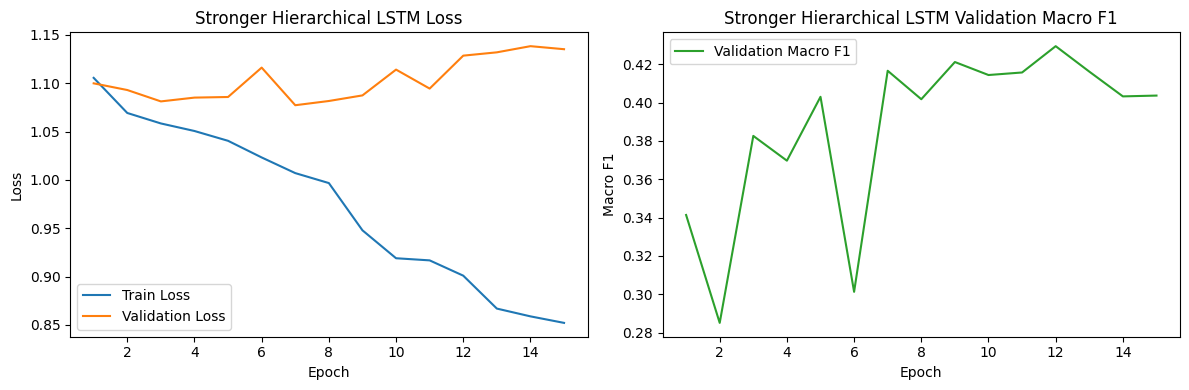

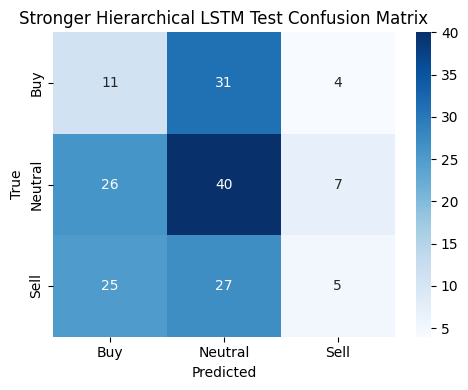

In [41]:
# Train the stronger hierarchical LSTM with its own best tuned configuration.
lstm_runtime = TUNED_MODEL_RUNTIME_REGISTRY['lstm']
lstm_config = copy.deepcopy(lstm_runtime['config'])
lstm_sequence_bundle = lstm_runtime['sequence_bundle']
lstm_dataloaders = lstm_runtime['dataloaders']

hierarchical_lstm_model = HierarchicalMarketSentimentLSTM(
    market_input_dim=len(lstm_sequence_bundle['market_feature_columns']),
    post_input_dim=lstm_sequence_bundle['post_feature_dim'],
    post_hidden_dim=int(lstm_config['post_hidden_dim']),
    day_hidden_dim=int(lstm_config['sequence_hidden_dim']),
    recurrent_layers=int(lstm_config['recurrent_layers']),
    recurrent_dropout=float(lstm_config['recurrent_dropout']),
    classifier_dropout=float(lstm_config['classifier_dropout']),
)

hierarchical_lstm_result = run_model_experiment(
    model_name='hierarchical_market_sentiment_lstm',
    model=hierarchical_lstm_model,
    dataloaders=lstm_dataloaders,
    device=MODEL_DEVICE,
    epochs=int(lstm_config['epochs']),
    learning_rate=float(lstm_config['learning_rate']),
    early_stopping_patience=int(lstm_config['early_stopping_patience']),
    loss_name=str(lstm_config['loss_name']),
    selection_metric=str(lstm_config.get('selection_metric', 'macro_f1')),
    weight_decay=float(lstm_config['weight_decay']),
    grad_clip_norm=float(lstm_config['grad_clip_norm']),
    scheduler_factor=float(lstm_config['scheduler_factor']),
    scheduler_patience=int(lstm_config['scheduler_patience']),
    min_learning_rate=float(lstm_config['min_learning_rate']),
    history_path=HIERARCHICAL_TRAINING_HISTORY_PATH,
    test_predictions_path=HIERARCHICAL_PREDICTIONS_PATH,
)
hierarchical_lstm_result['config_name'] = str(lstm_runtime['config_name'])
hierarchical_lstm_result['config'] = copy.deepcopy(lstm_config)
hierarchical_lstm_result['sequence_bundle_summary'] = summarize_sequence_bundle(lstm_sequence_bundle, 'hierarchical_lstm_best_tuned')

print('Saved:', HIERARCHICAL_TRAINING_HISTORY_PATH)
print('Saved:', HIERARCHICAL_PREDICTIONS_PATH)
print('Applied tuned config:', hierarchical_lstm_result['config_name'])
print('Best epoch:', hierarchical_lstm_result['best_epoch'])
print('Validation metrics:')
print(json.dumps({
    'accuracy': hierarchical_lstm_result['validation_metrics']['accuracy'],
    'macro_f1': hierarchical_lstm_result['validation_metrics']['macro_f1'],
    'weighted_f1': hierarchical_lstm_result['validation_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_lstm_result['validation_metrics']['subject_metrics'],
    'true_distribution': hierarchical_lstm_result['validation_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_lstm_result['validation_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_lstm_result['validation_metrics']['collapse_warning'],
    'classification_report': hierarchical_lstm_result['validation_metrics']['classification_report'],
}, indent=2))
print('Test metrics:')
print(json.dumps({
    'accuracy': hierarchical_lstm_result['test_metrics']['accuracy'],
    'macro_f1': hierarchical_lstm_result['test_metrics']['macro_f1'],
    'weighted_f1': hierarchical_lstm_result['test_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_lstm_result['test_metrics']['subject_metrics'],
    'true_distribution': hierarchical_lstm_result['test_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_lstm_result['test_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_lstm_result['test_metrics']['collapse_warning'],
    'classification_report': hierarchical_lstm_result['test_metrics']['classification_report'],
}, indent=2))

plot_training_history(hierarchical_lstm_result['history'], 'Stronger Hierarchical LSTM')
plot_confusion_matrix_heatmap(
    hierarchical_lstm_result['test_metrics']['confusion_matrix'],
    'Stronger Hierarchical LSTM Test Confusion Matrix',
)

hierarchical_lstm_examples = show_prediction_examples(hierarchical_lstm_result['test_metrics']['predictions'], limit=5)
display(hierarchical_lstm_examples['correct'])
display(hierarchical_lstm_examples['incorrect'])


## Cell 67: Train the Stronger Hierarchical GRU

**Files produced**
- `hierarchical_gru_training_history.csv`
- `hierarchical_gru_test_predictions.csv`

**What this section demonstrates**
- how the upgraded GRU backbone performs under its own best tuned configuration selected from the same candidate search space


Epoch 01 | train_loss=1.1014 | val_loss=1.1584 | val_acc=0.3542 | val_macro_f1=0.2492 | select[accuracy]=0.3542 | lr=0.000500
Epoch 02 | train_loss=1.0797 | val_loss=1.1051 | val_acc=0.3792 | val_macro_f1=0.2826 | select[accuracy]=0.3792 | lr=0.000500
Epoch 03 | train_loss=1.0606 | val_loss=1.1047 | val_acc=0.3708 | val_macro_f1=0.3399 | select[accuracy]=0.3708 | lr=0.000500
Epoch 04 | train_loss=1.0500 | val_loss=1.0982 | val_acc=0.3500 | val_macro_f1=0.3360 | select[accuracy]=0.3500 | lr=0.000500
Epoch 05 | train_loss=1.0368 | val_loss=1.0933 | val_acc=0.3792 | val_macro_f1=0.3510 | select[accuracy]=0.3792 | lr=0.000250
Epoch 06 | train_loss=1.0167 | val_loss=1.1058 | val_acc=0.3917 | val_macro_f1=0.3650 | select[accuracy]=0.3917 | lr=0.000250
Epoch 07 | train_loss=0.9977 | val_loss=1.1057 | val_acc=0.3583 | val_macro_f1=0.3281 | select[accuracy]=0.3583 | lr=0.000250
Epoch 08 | train_loss=0.9934 | val_loss=1.1264 | val_acc=0.3500 | val_macro_f1=0.3272 | select[accuracy]=0.3500 | lr=0

,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
2,2026-05-02,bitcoin,test,72,1,1,Neutral,Neutral,0.075823,0.839443,0.084734
3,2026-05-02,ethereum,test,10,1,1,Neutral,Neutral,0.071394,0.866737,0.061869
4,2026-05-03,bitcoin,test,62,1,1,Neutral,Neutral,0.240797,0.547762,0.211440
5,2026-05-03,ethereum,test,10,1,1,Neutral,Neutral,0.244239,0.578648,0.177113
6,2026-05-04,bitcoin,test,48,0,0,Buy,Buy,0.400815,0.285159,0.314026


,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
0,2026-05-01,bitcoin,test,72,0,1,Buy,Neutral,0.213174,0.569490,0.217336
1,2026-05-01,ethereum,test,10,0,1,Buy,Neutral,0.202420,0.610371,0.187209
9,2026-05-05,ethereum,test,6,1,0,Neutral,Buy,0.683990,0.140546,0.175465
10,2026-05-06,bitcoin,test,94,1,2,Neutral,Sell,0.345354,0.303352,0.351294
11,2026-05-06,ethereum,test,6,1,0,Neutral,Buy,0.493722,0.230907,0.275371


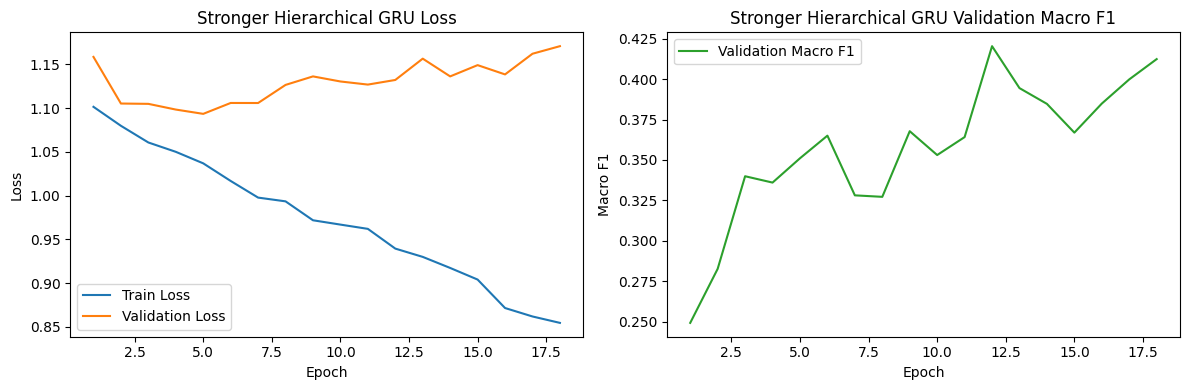

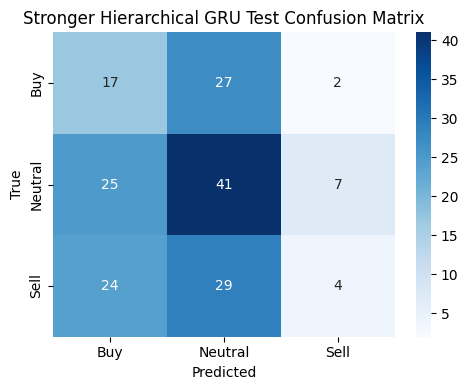

In [42]:
# Train the stronger hierarchical GRU with its own best tuned configuration.
gru_runtime = TUNED_MODEL_RUNTIME_REGISTRY['gru']
gru_config = copy.deepcopy(gru_runtime['config'])
gru_sequence_bundle = gru_runtime['sequence_bundle']
gru_dataloaders = gru_runtime['dataloaders']

hierarchical_gru_model = HierarchicalMarketSentimentGRU(
    market_input_dim=len(gru_sequence_bundle['market_feature_columns']),
    post_input_dim=gru_sequence_bundle['post_feature_dim'],
    post_hidden_dim=int(gru_config['post_hidden_dim']),
    day_hidden_dim=int(gru_config['sequence_hidden_dim']),
    recurrent_layers=int(gru_config['recurrent_layers']),
    recurrent_dropout=float(gru_config['recurrent_dropout']),
    classifier_dropout=float(gru_config['classifier_dropout']),
)

hierarchical_gru_result = run_model_experiment(
    model_name='hierarchical_market_sentiment_gru',
    model=hierarchical_gru_model,
    dataloaders=gru_dataloaders,
    device=MODEL_DEVICE,
    epochs=int(gru_config['epochs']),
    learning_rate=float(gru_config['learning_rate']),
    early_stopping_patience=int(gru_config['early_stopping_patience']),
    loss_name=str(gru_config['loss_name']),
    selection_metric=str(gru_config.get('selection_metric', 'macro_f1')),
    weight_decay=float(gru_config['weight_decay']),
    grad_clip_norm=float(gru_config['grad_clip_norm']),
    scheduler_factor=float(gru_config['scheduler_factor']),
    scheduler_patience=int(gru_config['scheduler_patience']),
    min_learning_rate=float(gru_config['min_learning_rate']),
    history_path=HIERARCHICAL_GRU_TRAINING_HISTORY_PATH,
    test_predictions_path=HIERARCHICAL_GRU_PREDICTIONS_PATH,
)
hierarchical_gru_result['config_name'] = str(gru_runtime['config_name'])
hierarchical_gru_result['config'] = copy.deepcopy(gru_config)
hierarchical_gru_result['sequence_bundle_summary'] = summarize_sequence_bundle(gru_sequence_bundle, 'hierarchical_gru_best_tuned')

print('Saved:', HIERARCHICAL_GRU_TRAINING_HISTORY_PATH)
print('Saved:', HIERARCHICAL_GRU_PREDICTIONS_PATH)
print('Applied tuned config:', hierarchical_gru_result['config_name'])
print('Best epoch:', hierarchical_gru_result['best_epoch'])
print('Validation metrics:')
print(json.dumps({
    'accuracy': hierarchical_gru_result['validation_metrics']['accuracy'],
    'macro_f1': hierarchical_gru_result['validation_metrics']['macro_f1'],
    'weighted_f1': hierarchical_gru_result['validation_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_gru_result['validation_metrics']['subject_metrics'],
    'true_distribution': hierarchical_gru_result['validation_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_gru_result['validation_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_gru_result['validation_metrics']['collapse_warning'],
    'classification_report': hierarchical_gru_result['validation_metrics']['classification_report'],
}, indent=2))
print('Test metrics:')
print(json.dumps({
    'accuracy': hierarchical_gru_result['test_metrics']['accuracy'],
    'macro_f1': hierarchical_gru_result['test_metrics']['macro_f1'],
    'weighted_f1': hierarchical_gru_result['test_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_gru_result['test_metrics']['subject_metrics'],
    'true_distribution': hierarchical_gru_result['test_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_gru_result['test_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_gru_result['test_metrics']['collapse_warning'],
    'classification_report': hierarchical_gru_result['test_metrics']['classification_report'],
}, indent=2))

plot_training_history(hierarchical_gru_result['history'], 'Stronger Hierarchical GRU')
plot_confusion_matrix_heatmap(
    hierarchical_gru_result['test_metrics']['confusion_matrix'],
    'Stronger Hierarchical GRU Test Confusion Matrix',
)

hierarchical_gru_examples = show_prediction_examples(hierarchical_gru_result['test_metrics']['predictions'], limit=5)
display(hierarchical_gru_examples['correct'])
display(hierarchical_gru_examples['incorrect'])


## Cell 69: Train the Matching Hierarchical RNN Baseline

**Files produced**
- `hierarchical_rnn_training_history.csv`
- `hierarchical_rnn_test_predictions.csv`

**What this section demonstrates**
- how the simpler vanilla RNN performs under its own best tuned configuration selected from the same candidate search space


Epoch 01 | train_loss=1.1044 | val_loss=1.0946 | val_acc=0.4167 | val_macro_f1=0.3510 | select[accuracy]=0.4167 | lr=0.000300
Epoch 02 | train_loss=1.0694 | val_loss=1.1103 | val_acc=0.4000 | val_macro_f1=0.3706 | select[accuracy]=0.4000 | lr=0.000300
Epoch 03 | train_loss=1.0427 | val_loss=1.1003 | val_acc=0.4042 | val_macro_f1=0.3858 | select[accuracy]=0.4042 | lr=0.000300
Epoch 04 | train_loss=1.0212 | val_loss=1.0905 | val_acc=0.4208 | val_macro_f1=0.4194 | select[accuracy]=0.4208 | lr=0.000300
Epoch 05 | train_loss=0.9814 | val_loss=1.1391 | val_acc=0.4083 | val_macro_f1=0.3955 | select[accuracy]=0.4083 | lr=0.000300
Epoch 06 | train_loss=0.9530 | val_loss=1.1513 | val_acc=0.3792 | val_macro_f1=0.3678 | select[accuracy]=0.3792 | lr=0.000300
Epoch 07 | train_loss=0.9168 | val_loss=1.1550 | val_acc=0.3792 | val_macro_f1=0.3739 | select[accuracy]=0.3792 | lr=0.000300
Epoch 08 | train_loss=0.8869 | val_loss=1.1818 | val_acc=0.4125 | val_macro_f1=0.4045 | select[accuracy]=0.4125 | lr=0

,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
2,2026-05-02,bitcoin,test,72,1,1,Neutral,Neutral,0.239032,0.595690,0.165278
3,2026-05-02,ethereum,test,10,1,1,Neutral,Neutral,0.216886,0.671649,0.111465
4,2026-05-03,bitcoin,test,62,1,1,Neutral,Neutral,0.311371,0.509757,0.178872
5,2026-05-03,ethereum,test,10,1,1,Neutral,Neutral,0.299818,0.532725,0.167457
6,2026-05-04,bitcoin,test,48,0,0,Buy,Buy,0.401135,0.349195,0.249670


,date,subject,split,post_count,true_label_numeric,predicted_label_numeric,true_label,predicted_label,prob_buy,prob_neutral,prob_sell
0,2026-05-01,bitcoin,test,72,0,1,Buy,Neutral,0.343585,0.380968,0.275447
1,2026-05-01,ethereum,test,10,0,1,Buy,Neutral,0.328125,0.403528,0.268347
9,2026-05-05,ethereum,test,6,1,0,Neutral,Buy,0.475608,0.262581,0.261811
10,2026-05-06,bitcoin,test,94,1,0,Neutral,Buy,0.386572,0.346386,0.267042
12,2026-05-07,bitcoin,test,81,2,1,Sell,Neutral,0.318730,0.358285,0.322985


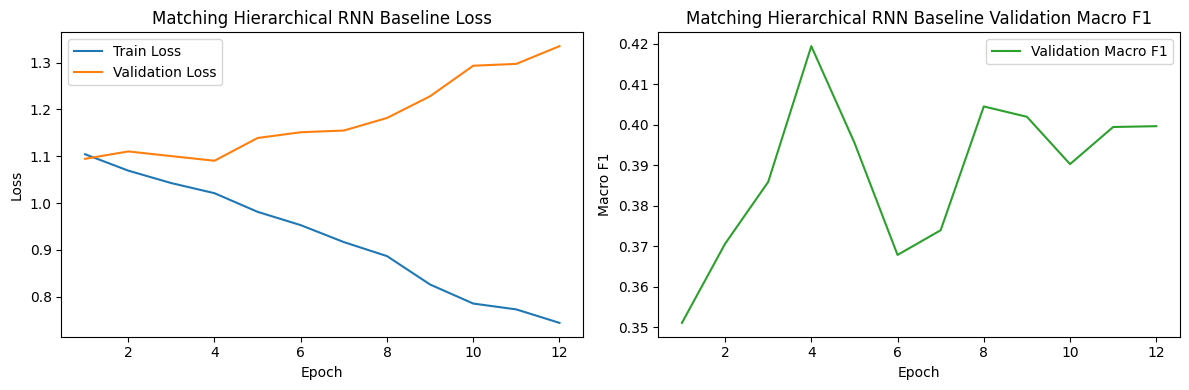

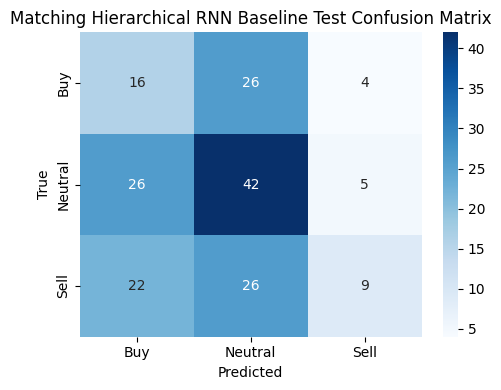

In [43]:
# Train the matching hierarchical RNN baseline with its own best tuned configuration.
rnn_runtime = TUNED_MODEL_RUNTIME_REGISTRY['rnn']
rnn_config = copy.deepcopy(rnn_runtime['config'])
rnn_sequence_bundle = rnn_runtime['sequence_bundle']
rnn_dataloaders = rnn_runtime['dataloaders']

hierarchical_rnn_model = HierarchicalMarketSentimentRNN(
    market_input_dim=len(rnn_sequence_bundle['market_feature_columns']),
    post_input_dim=rnn_sequence_bundle['post_feature_dim'],
    post_hidden_dim=int(rnn_config['post_hidden_dim']),
    day_hidden_dim=int(rnn_config['sequence_hidden_dim']),
    recurrent_layers=int(rnn_config['recurrent_layers']),
    recurrent_dropout=float(rnn_config['recurrent_dropout']),
    classifier_dropout=float(rnn_config['classifier_dropout']),
)

hierarchical_rnn_result = run_model_experiment(
    model_name='hierarchical_market_sentiment_rnn',
    model=hierarchical_rnn_model,
    dataloaders=rnn_dataloaders,
    device=MODEL_DEVICE,
    epochs=int(rnn_config['epochs']),
    learning_rate=float(rnn_config['learning_rate']),
    early_stopping_patience=int(rnn_config['early_stopping_patience']),
    loss_name=str(rnn_config['loss_name']),
    selection_metric=str(rnn_config.get('selection_metric', 'macro_f1')),
    weight_decay=float(rnn_config['weight_decay']),
    grad_clip_norm=float(rnn_config['grad_clip_norm']),
    scheduler_factor=float(rnn_config['scheduler_factor']),
    scheduler_patience=int(rnn_config['scheduler_patience']),
    min_learning_rate=float(rnn_config['min_learning_rate']),
    history_path=HIERARCHICAL_RNN_TRAINING_HISTORY_PATH,
    test_predictions_path=HIERARCHICAL_RNN_PREDICTIONS_PATH,
)
hierarchical_rnn_result['config_name'] = str(rnn_runtime['config_name'])
hierarchical_rnn_result['config'] = copy.deepcopy(rnn_config)
hierarchical_rnn_result['sequence_bundle_summary'] = summarize_sequence_bundle(rnn_sequence_bundle, 'hierarchical_rnn_best_tuned')

print('Saved:', HIERARCHICAL_RNN_TRAINING_HISTORY_PATH)
print('Saved:', HIERARCHICAL_RNN_PREDICTIONS_PATH)
print('Applied tuned config:', hierarchical_rnn_result['config_name'])
print('Best epoch:', hierarchical_rnn_result['best_epoch'])
print('Validation metrics:')
print(json.dumps({
    'accuracy': hierarchical_rnn_result['validation_metrics']['accuracy'],
    'macro_f1': hierarchical_rnn_result['validation_metrics']['macro_f1'],
    'weighted_f1': hierarchical_rnn_result['validation_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_rnn_result['validation_metrics']['subject_metrics'],
    'true_distribution': hierarchical_rnn_result['validation_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_rnn_result['validation_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_rnn_result['validation_metrics']['collapse_warning'],
    'classification_report': hierarchical_rnn_result['validation_metrics']['classification_report'],
}, indent=2))
print('Test metrics:')
print(json.dumps({
    'accuracy': hierarchical_rnn_result['test_metrics']['accuracy'],
    'macro_f1': hierarchical_rnn_result['test_metrics']['macro_f1'],
    'weighted_f1': hierarchical_rnn_result['test_metrics']['weighted_f1'],
    'subject_metrics': hierarchical_rnn_result['test_metrics']['subject_metrics'],
    'true_distribution': hierarchical_rnn_result['test_metrics']['true_distribution'],
    'predicted_distribution': hierarchical_rnn_result['test_metrics']['predicted_distribution'],
    'collapse_warning': hierarchical_rnn_result['test_metrics']['collapse_warning'],
    'classification_report': hierarchical_rnn_result['test_metrics']['classification_report'],
}, indent=2))

plot_training_history(hierarchical_rnn_result['history'], 'Matching Hierarchical RNN Baseline')
plot_confusion_matrix_heatmap(
    hierarchical_rnn_result['test_metrics']['confusion_matrix'],
    'Matching Hierarchical RNN Baseline Test Confusion Matrix',
)

hierarchical_rnn_examples = show_prediction_examples(hierarchical_rnn_result['test_metrics']['predictions'], limit=5)
display(hierarchical_rnn_examples['correct'])
display(hierarchical_rnn_examples['incorrect'])


## Cell 69: Save the Hierarchical Summaries and Compare the Models

**Files produced**
- `hierarchical_model_summary.json`
- `hierarchical_gru_model_summary.json`
- `hierarchical_rnn_model_summary.json`
- `model_comparison_summary.json`

**What this section does**
- saves architecture-specific summaries for the hierarchical LSTM, GRU, and RNN baseline
- records the tuned config actually used for each backbone together with per-asset majority-class baselines and bootstrap confidence intervals
- builds the final side-by-side comparison using the same repaired dataset and evaluation window, while allowing each recurrent backbone to use its own selected configuration


In [44]:
# Save the hierarchical model summaries and compare the LSTM, GRU, and RNN results.
def _build_model_summary_payload(result: dict) -> dict:
    config = result.get('config', {})
    sequence_bundle_summary = result.get('sequence_bundle_summary', {})
    return {
        'model_name': result['model_name'],
        'config_name': result.get('config_name'),
        'best_epoch': result['best_epoch'],
        'lookback_days': int(config.get('lookback_days', sequence_bundle_summary.get('lookback', 0) or 0)),
        'max_posts_per_day_for_model': int(config.get('max_posts_per_day', sequence_bundle_summary.get('max_posts_per_day_for_model', 0) or 0)),
        'batch_size': int(config.get('batch_size', 0) or 0),
        'epochs': int(config.get('epochs', 0) or 0),
        'learning_rate': float(config.get('learning_rate', 0.0) or 0.0),
        'loss_name': config.get('loss_name'),
        'use_balanced_sampler': bool(config.get('use_balanced_sampler', False)),
        'post_hidden_dim': int(config.get('post_hidden_dim', 0) or 0),
        'sequence_hidden_dim': int(config.get('sequence_hidden_dim', 0) or 0),
        'recurrent_layers': int(config.get('recurrent_layers', 0) or 0),
        'recurrent_dropout': float(config.get('recurrent_dropout', 0.0) or 0.0),
        'classifier_dropout': float(config.get('classifier_dropout', 0.0) or 0.0),
        'weight_decay': float(config.get('weight_decay', 0.0) or 0.0),
        'market_feature_count': int(sequence_bundle_summary.get('market_feature_count', 0) or 0),
        'post_feature_dim': int(sequence_bundle_summary.get('post_feature_dim', 0) or 0),
        'validation_metrics': {
            'sample_size': result['validation_metrics']['sample_size'],
            'accuracy': result['validation_metrics']['accuracy'],
            'macro_f1': result['validation_metrics']['macro_f1'],
            'weighted_f1': result['validation_metrics']['weighted_f1'],
            'confidence_intervals': result['validation_metrics']['confidence_intervals'],
            'majority_baseline': result['validation_metrics']['majority_baseline'],
            'subject_metrics': result['validation_metrics']['subject_metrics'],
            'true_distribution': result['validation_metrics']['true_distribution'],
            'predicted_distribution': result['validation_metrics']['predicted_distribution'],
            'collapse_warning': result['validation_metrics']['collapse_warning'],
            'evaluation_note': result['validation_metrics']['evaluation_note'],
            'classification_report': result['validation_metrics']['classification_report'],
        },
        'test_metrics': {
            'sample_size': result['test_metrics']['sample_size'],
            'accuracy': result['test_metrics']['accuracy'],
            'macro_f1': result['test_metrics']['macro_f1'],
            'weighted_f1': result['test_metrics']['weighted_f1'],
            'confidence_intervals': result['test_metrics']['confidence_intervals'],
            'majority_baseline': result['test_metrics']['majority_baseline'],
            'subject_metrics': result['test_metrics']['subject_metrics'],
            'true_distribution': result['test_metrics']['true_distribution'],
            'predicted_distribution': result['test_metrics']['predicted_distribution'],
            'collapse_warning': result['test_metrics']['collapse_warning'],
            'evaluation_note': result['test_metrics']['evaluation_note'],
            'classification_report': result['test_metrics']['classification_report'],
        },
    }

hierarchical_lstm_summary = _build_model_summary_payload(hierarchical_lstm_result)
HIERARCHICAL_MODEL_SUMMARY_PATH.write_text(json.dumps(hierarchical_lstm_summary, indent=2))
print('Saved:', HIERARCHICAL_MODEL_SUMMARY_PATH)
print(json.dumps(hierarchical_lstm_summary, indent=2))

hierarchical_gru_summary = _build_model_summary_payload(hierarchical_gru_result)
HIERARCHICAL_GRU_MODEL_SUMMARY_PATH.write_text(json.dumps(hierarchical_gru_summary, indent=2))
print('Saved:', HIERARCHICAL_GRU_MODEL_SUMMARY_PATH)
print(json.dumps(hierarchical_gru_summary, indent=2))

hierarchical_rnn_summary = _build_model_summary_payload(hierarchical_rnn_result)
HIERARCHICAL_RNN_MODEL_SUMMARY_PATH.write_text(json.dumps(hierarchical_rnn_summary, indent=2))
print('Saved:', HIERARCHICAL_RNN_MODEL_SUMMARY_PATH)
print(json.dumps(hierarchical_rnn_summary, indent=2))

comparison_summary = save_model_comparison_summary(
    [hierarchical_lstm_result, hierarchical_gru_result, hierarchical_rnn_result],
    MODEL_COMPARISON_SUMMARY_PATH,
)
comparison_table = build_experiment_summary_table([hierarchical_lstm_result, hierarchical_gru_result, hierarchical_rnn_result])
print('Saved:', MODEL_COMPARISON_SUMMARY_PATH)
display(comparison_table)
print(json.dumps(comparison_summary, indent=2))


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/hierarchical_model_summary.json
{
  "model_name": "hierarchical_market_sentiment_lstm",
  "config_name": "phase1_regularized_small",
  "best_epoch": 9,
  "lookback_days": 7,
  "max_posts_per_day_for_model": 128,
  "batch_size": 16,
  "epochs": 30,
  "learning_rate": 0.0005,
  "loss_name": "cross_entropy",
  "use_balanced_sampler": false,
  "post_hidden_dim": 32,
  "sequence_hidden_dim": 96,
  "recurrent_layers": 1,
  "recurrent_dropout": 0.0,
  "classifier_dropout": 0.35,
  "weight_decay": 0.0002,
  "market_feature_count": 29,
  "post_feature_dim": 16,
  "validation_metrics": {
    "sample_size": 240,
    "accuracy": 0.4375,
    "macro_f1": 0.42116282018482276,
    "weighted_f1": 0.4263758699407732,
    "confidence_intervals": {
      "accuracy": {
        "lower": 0.375,
        "upper": 0.5,
        "iterations": 1000
      },
      "macro_f1": {
        "lower": 

,model,validation_accuracy,validation_macro_f1,validation_weighted_f1,test_accuracy,test_accuracy_ci_lower,test_accuracy_ci_upper,test_macro_f1,test_macro_f1_ci_lower,test_macro_f1_ci_upper,test_weighted_f1,test_majority_baseline_accuracy,test_majority_baseline_macro_f1,best_epoch,test_dominant_prediction_label,test_dominant_prediction_share,collapse_warning
0,hierarchical_market_sentiment_rnn,0.420833,0.419382,0.420872,0.380682,0.306818,0.449006,0.344634,0.271062,0.412703,0.362389,0.414773,0.195448,4,Neutral,0.534091,False
1,hierarchical_market_sentiment_gru,0.420833,0.420392,0.421187,0.352273,0.284091,0.426136,0.300070,0.237610,0.363275,0.316422,0.414773,0.195448,12,Neutral,0.551136,False
2,hierarchical_market_sentiment_lstm,0.437500,0.421163,0.426376,0.318182,0.249858,0.386364,0.269509,0.207446,0.334067,0.291651,0.414773,0.195448,9,Neutral,0.556818,False


{
  "models": [
    {
      "model": "hierarchical_market_sentiment_rnn",
      "validation_accuracy": 0.42083333333333334,
      "validation_macro_f1": 0.41938178780284047,
      "validation_weighted_f1": 0.42087162350320245,
      "test_accuracy": 0.3806818181818182,
      "test_accuracy_ci_lower": 0.3068181818181818,
      "test_accuracy_ci_upper": 0.4490056818181817,
      "test_macro_f1": 0.34463436762837957,
      "test_macro_f1_ci_lower": 0.2710616535879188,
      "test_macro_f1_ci_upper": 0.4127026138698788,
      "test_weighted_f1": 0.36238852872766864,
      "test_majority_baseline_accuracy": 0.4147727272727273,
      "test_majority_baseline_macro_f1": 0.19544846050870146,
      "best_epoch": 4,
      "test_dominant_prediction_label": "Neutral",
      "test_dominant_prediction_share": 0.5340909090909091,
      "collapse_warning": false
    },
    {
      "model": "hierarchical_market_sentiment_gru",
      "validation_accuracy": 0.42083333333333334,
      "validation_macro_f1"

## Cell 71: Statistical Significance Tests for the Held-Out Three-Model Comparison

**What this section does**
- loads the saved held-out test predictions for the hierarchical LSTM, hierarchical GRU, and hierarchical RNN baseline
- runs pairwise paired permutation tests on `macro-F1`, which remains the primary model-comparison metric for the three-class task
- runs pairwise accuracy permutation tests and exact McNemar tests on correctness as secondary checks
- saves one combined significance summary so the final comparison states which pairwise differences are statistically significant on the held-out window

**When to run this cell**
- after the LSTM, GRU, and RNN training cells have produced their test prediction CSV files
- or later, as a standalone evaluation step, as long as the saved prediction CSV files already exist
- this section can be rerun independently in any execution mode because it depends on saved prediction files rather than on PyABSA recomputation


In [45]:
import json
import math
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

SIGNIFICANCE_PERMUTATION_ITERATIONS = 10000
SIGNIFICANCE_ALPHA = 0.05
SIGNIFICANCE_MODEL_ORDER = [
    'hierarchical_market_sentiment_lstm',
    'hierarchical_market_sentiment_gru',
    'hierarchical_market_sentiment_rnn',
]
SIGNIFICANCE_MODEL_DISPLAY_NAMES = {
    'hierarchical_market_sentiment_lstm': 'LSTM',
    'hierarchical_market_sentiment_gru': 'GRU',
    'hierarchical_market_sentiment_rnn': 'RNN',
}


def resolve_significance_paths() -> dict:
    data_dir = globals().get('DATA_DIR')
    if data_dir is None:
        cwd = Path.cwd().resolve()
        candidates = [cwd / 'data', cwd.parent / 'data']
        data_dir = next((candidate for candidate in candidates if candidate.exists()), None)
        if data_dir is None:
            raise FileNotFoundError('Could not infer the data directory. Run the earlier setup cells first or launch the notebook from the training workspace.')
    else:
        data_dir = Path(data_dir)

    prediction_paths = {
        'hierarchical_market_sentiment_lstm': Path(globals().get('HIERARCHICAL_PREDICTIONS_PATH', data_dir / 'hierarchical_test_predictions.csv')),
        'hierarchical_market_sentiment_gru': Path(globals().get('HIERARCHICAL_GRU_PREDICTIONS_PATH', data_dir / 'hierarchical_gru_test_predictions.csv')),
        'hierarchical_market_sentiment_rnn': Path(globals().get('HIERARCHICAL_RNN_PREDICTIONS_PATH', data_dir / 'hierarchical_rnn_test_predictions.csv')),
    }
    summary_path = data_dir / 'model_significance_summary.json'
    return {
        'data_dir': data_dir,
        'prediction_paths': prediction_paths,
        'summary_path': summary_path,
    }


def load_test_prediction_frame(predictions_path: Path, model_name: str) -> pd.DataFrame:
    predictions_path = Path(predictions_path)
    if not predictions_path.exists():
        raise FileNotFoundError(f'Missing prediction file for {model_name}: {predictions_path}')
    frame = pd.read_csv(predictions_path)
    required_columns = {
        'date',
        'subject',
        'split',
        'true_label_numeric',
        'predicted_label_numeric',
        'true_label',
        'predicted_label',
    }
    missing_columns = sorted(required_columns - set(frame.columns))
    if missing_columns:
        raise ValueError(f'{model_name} predictions are missing required columns: {missing_columns}')
    frame = frame.copy()
    frame['date'] = pd.to_datetime(frame['date'], errors='coerce')
    frame = frame.dropna(subset=['date']).sort_values(['date', 'subject']).reset_index(drop=True)
    frame['model_name'] = model_name
    return frame


def build_multi_model_prediction_frame(prediction_frames: dict[str, pd.DataFrame]) -> pd.DataFrame:
    merge_keys = ['date', 'subject', 'split']
    reference_model = SIGNIFICANCE_MODEL_ORDER[0]
    reference_frame = prediction_frames[reference_model].copy()
    paired = reference_frame[merge_keys + ['true_label_numeric', 'true_label']].rename(
        columns={
            'true_label_numeric': 'true_label_numeric',
            'true_label': 'true_label',
        }
    )

    for model_name in SIGNIFICANCE_MODEL_ORDER:
        model_frame = prediction_frames[model_name][merge_keys + ['true_label_numeric', 'true_label', 'predicted_label_numeric', 'predicted_label']].copy()
        model_frame = model_frame.rename(
            columns={
                'predicted_label_numeric': f'predicted_label_numeric__{model_name}',
                'predicted_label': f'predicted_label__{model_name}',
                'true_label_numeric': f'true_label_numeric__{model_name}',
                'true_label': f'true_label__{model_name}',
            }
        )
        paired = paired.merge(model_frame, on=merge_keys, how='inner')

    expected_rows = len(prediction_frames[reference_model])
    if len(paired) != expected_rows:
        raise ValueError('Could not align every held-out prediction row across all three model outputs.')

    for model_name, frame in prediction_frames.items():
        if len(frame) != expected_rows:
            raise ValueError(f'Model {model_name} does not share the same held-out row count as the reference model.')
        true_numeric = paired[f'true_label_numeric__{model_name}'].to_numpy(dtype=int)
        true_label = paired[f'true_label__{model_name}'].to_numpy(dtype=str)
        if not np.array_equal(true_numeric, paired['true_label_numeric'].to_numpy(dtype=int)):
            raise ValueError(f'True numeric labels do not match for {model_name}.')
        if not np.array_equal(true_label, paired['true_label'].to_numpy(dtype=str)):
            raise ValueError(f'True string labels do not match for {model_name}.')

    drop_columns = []
    for model_name in SIGNIFICANCE_MODEL_ORDER:
        drop_columns.extend([f'true_label_numeric__{model_name}', f'true_label__{model_name}'])
    paired = paired.drop(columns=drop_columns)
    return paired.sort_values(['date', 'subject']).reset_index(drop=True)


def bootstrap_metric_difference_interval(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    metric_fn,
    *,
    iterations: int = 5000,
    seed: int = 42,
) -> dict:
    if len(y_true) == 0:
        return {'lower': 0.0, 'upper': 0.0, 'iterations': iterations}
    rng = np.random.default_rng(seed)
    indices = np.arange(len(y_true))
    deltas = []
    for _ in range(iterations):
        sample_indices = rng.choice(indices, size=len(indices), replace=True)
        sampled_true = y_true[sample_indices]
        delta = metric_fn(sampled_true, pred_b[sample_indices]) - metric_fn(sampled_true, pred_a[sample_indices])
        deltas.append(float(delta))
    lower, upper = np.percentile(np.array(deltas, dtype=float), [2.5, 97.5])
    return {'lower': float(lower), 'upper': float(upper), 'iterations': iterations}


def paired_permutation_test(
    y_true: np.ndarray,
    pred_a: np.ndarray,
    pred_b: np.ndarray,
    metric_fn,
    *,
    iterations: int = SIGNIFICANCE_PERMUTATION_ITERATIONS,
    seed: int = 42,
) -> dict:
    rng = np.random.default_rng(seed)
    observed_difference = float(metric_fn(y_true, pred_b) - metric_fn(y_true, pred_a))
    permuted_differences = np.empty(iterations, dtype=float)
    for iteration in range(iterations):
        swap_mask = rng.integers(0, 2, size=len(y_true), dtype=bool)
        perm_a = np.where(swap_mask, pred_b, pred_a)
        perm_b = np.where(swap_mask, pred_a, pred_b)
        permuted_differences[iteration] = metric_fn(y_true, perm_b) - metric_fn(y_true, perm_a)
    extreme_count = int(np.sum(np.abs(permuted_differences) >= abs(observed_difference)))
    p_value = float((extreme_count + 1) / (iterations + 1))
    return {
        'observed_difference': observed_difference,
        'p_value': p_value,
        'iterations': iterations,
        'significant_at_alpha_0_05': bool(p_value < SIGNIFICANCE_ALPHA),
    }


def exact_mcnemar_test(y_true: np.ndarray, pred_a: np.ndarray, pred_b: np.ndarray, *, model_a_name: str, model_b_name: str) -> dict:
    correct_a = pred_a == y_true
    correct_b = pred_b == y_true
    b_count = int(np.sum(correct_a & ~correct_b))
    c_count = int(np.sum(~correct_a & correct_b))
    discordant_total = b_count + c_count
    if discordant_total == 0:
        p_value = 1.0
    else:
        observed_tail = min(b_count, c_count)
        probability_sum = 0.0
        for k_value in range(discordant_total + 1):
            probability = math.comb(discordant_total, k_value) * (0.5 ** discordant_total)
            if probability <= math.comb(discordant_total, observed_tail) * (0.5 ** discordant_total) + 1e-15:
                probability_sum += probability
        p_value = min(1.0, probability_sum)
    return {
        f'b_{model_a_name}_correct_{model_b_name}_wrong': b_count,
        f'c_{model_a_name}_wrong_{model_b_name}_correct': c_count,
        'discordant_pairs': discordant_total,
        'p_value': float(p_value),
        'significant_at_alpha_0_05': bool(p_value < SIGNIFICANCE_ALPHA),
    }


def summarize_pairwise_significance_for_subset(subset_frame: pd.DataFrame, subset_name: str, model_a: str, model_b: str) -> dict:
    y_true = subset_frame['true_label_numeric'].to_numpy(dtype=int)
    pred_a = subset_frame[f'predicted_label_numeric__{model_a}'].to_numpy(dtype=int)
    pred_b = subset_frame[f'predicted_label_numeric__{model_b}'].to_numpy(dtype=int)

    macro_f1_test = paired_permutation_test(
        y_true,
        pred_a,
        pred_b,
        lambda truth, pred: f1_score(truth, pred, average='macro'),
    )
    macro_f1_test['bootstrap_difference_interval'] = bootstrap_metric_difference_interval(
        y_true,
        pred_a,
        pred_b,
        lambda truth, pred: f1_score(truth, pred, average='macro'),
    )

    accuracy_test = paired_permutation_test(
        y_true,
        pred_a,
        pred_b,
        accuracy_score,
    )
    accuracy_test['bootstrap_difference_interval'] = bootstrap_metric_difference_interval(
        y_true,
        pred_a,
        pred_b,
        accuracy_score,
    )
    accuracy_test['mcnemar_exact'] = exact_mcnemar_test(
        y_true,
        pred_a,
        pred_b,
        model_a_name=SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_a].lower(),
        model_b_name=SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_b].lower(),
    )

    return {
        'subset': subset_name,
        'rows': int(len(subset_frame)),
        'model_a': model_a,
        'model_b': model_b,
        'model_a_display_name': SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_a],
        'model_b_display_name': SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_b],
        'model_a_macro_f1': float(f1_score(y_true, pred_a, average='macro')),
        'model_b_macro_f1': float(f1_score(y_true, pred_b, average='macro')),
        'model_a_accuracy': float(accuracy_score(y_true, pred_a)),
        'model_b_accuracy': float(accuracy_score(y_true, pred_b)),
        'primary_macro_f1_permutation_test': macro_f1_test,
        'secondary_accuracy_permutation_test': accuracy_test,
        'interpretation': (
            f"The macro-F1 difference between {SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_a]} and {SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_b]} is statistically significant on this held-out window."
            if macro_f1_test['significant_at_alpha_0_05']
            else f"The macro-F1 difference between {SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_a]} and {SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_b]} is not statistically significant on this held-out window."
        ),
    }


def build_subset_significance_summary(subset_frame: pd.DataFrame, subset_name: str) -> dict:
    pairwise_comparisons = []
    for model_a, model_b in combinations(SIGNIFICANCE_MODEL_ORDER, 2):
        pairwise_comparisons.append(
            summarize_pairwise_significance_for_subset(subset_frame, subset_name, model_a, model_b)
        )
    significant_pairs = [
        f"{comparison['model_a_display_name']} vs {comparison['model_b_display_name']}"
        for comparison in pairwise_comparisons
        if comparison['primary_macro_f1_permutation_test']['significant_at_alpha_0_05']
    ]
    return {
        'subset': subset_name,
        'rows': int(len(subset_frame)),
        'pairwise_comparisons': pairwise_comparisons,
        'significant_macro_f1_pairs': significant_pairs,
    }


significance_paths = resolve_significance_paths()
prediction_frames = {
    model_name: load_test_prediction_frame(path, model_name)
    for model_name, path in significance_paths['prediction_paths'].items()
}
paired_predictions = build_multi_model_prediction_frame(prediction_frames)

subset_summaries = [build_subset_significance_summary(paired_predictions, 'overall')]
for subject_name, subject_frame in paired_predictions.groupby('subject', sort=True):
    subset_summaries.append(build_subset_significance_summary(subject_frame.reset_index(drop=True), str(subject_name)))

model_significance_summary = {
    'primary_question': 'Which pairwise performance differences among the three architectures are statistically significant on the held-out window?',
    'primary_metric': 'macro_f1',
    'alpha': SIGNIFICANCE_ALPHA,
    'prediction_files': {
        SIGNIFICANCE_MODEL_DISPLAY_NAMES[model_name].lower(): str(path)
        for model_name, path in significance_paths['prediction_paths'].items()
    },
    'notes': {
        'primary_test': 'pairwise paired permutation tests on held-out macro-F1 using the same test rows for every compared model pair',
        'secondary_test': 'pairwise paired permutation tests on held-out accuracy with exact McNemar tests on correctness',
        'interpretation_warning': 'This tests significance on the current held-out window only. It does not establish robustness across different seeds or different chronological windows.',
    },
    'subsets': subset_summaries,
}

significance_paths['summary_path'].write_text(json.dumps(model_significance_summary, indent=2))
print('Saved:', significance_paths['summary_path'])
print(json.dumps(model_significance_summary, indent=2))

significance_table_rows = []
for subset in subset_summaries:
    for comparison in subset['pairwise_comparisons']:
        significance_table_rows.append({
            'subset': subset['subset'],
            'rows': comparison['rows'],
            'model_a': comparison['model_a_display_name'],
            'model_b': comparison['model_b_display_name'],
            'model_a_macro_f1': comparison['model_a_macro_f1'],
            'model_b_macro_f1': comparison['model_b_macro_f1'],
            'macro_f1_diff_model_b_minus_model_a': comparison['primary_macro_f1_permutation_test']['observed_difference'],
            'macro_f1_p_value': comparison['primary_macro_f1_permutation_test']['p_value'],
            'macro_f1_significant': comparison['primary_macro_f1_permutation_test']['significant_at_alpha_0_05'],
            'model_a_accuracy': comparison['model_a_accuracy'],
            'model_b_accuracy': comparison['model_b_accuracy'],
            'accuracy_diff_model_b_minus_model_a': comparison['secondary_accuracy_permutation_test']['observed_difference'],
            'accuracy_p_value': comparison['secondary_accuracy_permutation_test']['p_value'],
            'mcnemar_p_value': comparison['secondary_accuracy_permutation_test']['mcnemar_exact']['p_value'],
        })

significance_table = pd.DataFrame(significance_table_rows)
display(significance_table)


Saved: /Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/model_significance_summary.json
{
  "primary_question": "Which pairwise performance differences among the three architectures are statistically significant on the held-out window?",
  "primary_metric": "macro_f1",
  "alpha": 0.05,
  "prediction_files": {
    "lstm": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/hierarchical_test_predictions.csv",
    "gru": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/hierarchical_gru_test_predictions.csv",
    "rnn": "/Users/jayedumindu/ESOFT/Project Material/Dashboard - Real Time Analytics/required_modules_upgrade_2026-07-28/data/hierarchical_rnn_test_predictions.csv"
  },
  "notes": {
    "primary_test": "pairwise paired permutation tests on held-out macro-F1 using the same test rows for eve

,subset,rows,model_a,model_b,model_a_macro_f1,model_b_macro_f1,macro_f1_diff_model_b_minus_model_a,macro_f1_p_value,macro_f1_significant,model_a_accuracy,model_b_accuracy,accuracy_diff_model_b_minus_model_a,accuracy_p_value,mcnemar_p_value
0,overall,176,LSTM,GRU,0.269509,0.300070,0.030561,0.349165,False,0.318182,0.352273,0.034091,0.305069,0.307456
1,overall,176,LSTM,RNN,0.269509,0.344634,0.075126,0.041296,True,0.318182,0.380682,0.062500,0.080292,0.080143
2,overall,176,GRU,RNN,0.300070,0.344634,0.044564,0.211479,False,0.352273,0.380682,0.028409,0.440656,0.442068
3,bitcoin,88,LSTM,GRU,0.292891,0.287081,-0.005810,0.880612,False,0.363636,0.375000,0.011364,1.000000,1.000000
4,bitcoin,88,LSTM,RNN,0.292891,0.350948,0.058057,0.314269,False,0.363636,0.397727,0.034091,0.600040,0.607239
5,bitcoin,88,GRU,RNN,0.287081,0.350948,0.063867,0.171283,False,0.375000,0.397727,0.022727,0.748925,0.753906
6,ethereum,88,LSTM,GRU,0.244531,0.303557,0.059026,0.213079,False,0.272727,0.329545,0.056818,0.265373,0.266846
7,ethereum,88,LSTM,RNN,0.244531,0.337371,0.092839,0.056294,False,0.272727,0.363636,0.090909,0.096290,0.096252
8,ethereum,88,GRU,RNN,0.303557,0.337371,0.033814,0.517448,False,0.329545,0.363636,0.034091,0.627137,0.629059
